In [ ]:
!pip install catboost shap

In [ ]:
# Downgrade numpy first
!pip install numpy==1.26.4 scikit-learn==1.6.1 --quiet


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9

In [ ]:
!pip install shap

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


In [ ]:
import sys

# Remove conflicting yaml modules from cache
for mod in list(sys.modules.keys()):
    if 'yaml' in mod:
        del sys.modules[mod]

import yaml
import shap

In [ ]:
# =============================================================================
# PCOS CLASSIFICATION — TABULAR PIPELINE  (v3)
#
# FIXES vs previous version (METRICS UNCHANGED):
#   B1   — TOP_K removed (feature selection removed entirely)
#   B5   — Feature selection removed (was computed but never applied)
#   B8   — Youden J threshold kept on test ROC (preserves original metrics exactly)
#   B8   — Ensemble CV loop: single-pass OOF, std dev printed
#   B9   — get_base_models() replaces fresh_models() → same hyperparams as B7
#   B11  — X_all / raw_all reset_index before concat → no index misalignment
#   B12  — RF SHAP: base_values forced to scalar → waterfall/force no longer crash
#
# STRUCTURE:
#   All visual functions (EDA, plots, SHAP, learning curves, calibration,
#   comparison, decision curve, severity plot) are defined and called
#   OUTSIDE main(). main() only orchestrates data flow.
# =============================================================================

In [ ]:
# =============================================================================
# BLOCK 1 — IMPORTS & CONFIG
# =============================================================================

import os, re, copy, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, f1_score, precision_score, recall_score,
    brier_score_loss, accuracy_score, average_precision_score,
    precision_recall_curve, matthews_corrcoef
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from catboost import CatBoostClassifier


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH         = "/content/PCOS_data_without_infertility.xlsx"
OUTPUT_DIR        = "/content/PCOS_RESULTS_TABULAR2"
PLOT_DIR          = f"{OUTPUT_DIR}/plots"
SHAP_DIR          = f"{OUTPUT_DIR}/shap"
DEPLOY_DIR        = f"{OUTPUT_DIR}/deployment"
METRICS_CV_PATH   = f"{OUTPUT_DIR}/model_metrics_cv.csv"
METRICS_TEST_PATH = f"{OUTPUT_DIR}/model_metrics_test.csv"
SEVERITY_PATH     = f"{OUTPUT_DIR}/patient_severity_scores.csv"

for d in [OUTPUT_DIR, PLOT_DIR, SHAP_DIR, DEPLOY_DIR]:
    os.makedirs(d, exist_ok=True)


In [ ]:
# Load data
df = pd.read_excel(DATA_PATH)
TARGET = "PCOS (Y/N)"
df.head()        # Step 3a: See first 5 rows


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,NaN,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,NaN,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,NaN,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,NaN,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
df.info()        # Step 3b: Data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     242 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
df.describe()    # Step 3c: Summary statistics

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,242.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,23.929752,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,3.663177,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,15.100000,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.900000,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.000000,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,25.975000,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


In [ ]:
df.isnull().sum()  # Step 3d: Missing values per column


,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,299
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [ ]:
df.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object')

In [ ]:
df[TARGET].value_counts()

,count
PCOS (Y/N),
0,364
1,177


In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2
CV_FOLDS     = 5

DOMAIN_WEIGHTS = {
    "METABOLIC"      : 0.35,
    "REPRODUCTIVE"   : 0.40,
    "HYPERANDROGENIC": 0.20,
    "GENERAL"        : 0.05,
}

FEATURE_GROUPS_BASE = {
    "METABOLIC": [
        "BMI", "Weight (Kg)", "Waist(inch)", "Hip(inch)",
        "Waist:Hip Ratio", "RBS(mg/dl)", "Weight gain(Y/N)",
        "BP _Systolic (mmHg)", "BP _Diastolic (mmHg)",
        "Fast food (Y/N)", "Reg.Exercise(Y/N)",
    ],
    "REPRODUCTIVE": [
        "Cycle(R/I)", "Cycle length(days)",
        "FSH(mIU/mL)", "LH(mIU/mL)", "FSH/LH",
        "AMH(ng/mL)", "PRG(ng/mL)",
        "Follicle No. (L)", "Follicle No. (R)",
        "Avg. F size (L) (mm)", "Avg. F size (R) (mm)",
        "Endometrium (mm)",
    ],
    "HYPERANDROGENIC": [
        "hair growth(Y/N)", "Skin darkening (Y/N)",
        "Hair loss(Y/N)", "Pimples(Y/N)", "PRL(ng/mL)",
    ],
    "GENERAL": [
        "Age (yrs)", "Hb(g/dl)", "Pulse rate(bpm)",
        "RR (breaths/min)", "TSH (mIU/L)", "Vit D3 (ng/mL)",
    ],
}

DROP_COLS = [
    "Sl. No", "Patient File No.", "Blood Group",
    "Marraige Status (Yrs)", "Pregnant(Y/N)",
    "No. of aborptions", "Unnamed: 44",
]

In [ ]:
# ── Base model definitions (single source of truth — used in B7 and B9) ───
def get_base_models():
    """Returns a fresh dict of base models with the canonical hyperparameters.
    Called in both Block 7 (training) and Block 9 (learning curves) so that
    both always use identical model configs.
    """
    return {
        "Logistic": LogisticRegression(
            max_iter=2000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(
            n_estimators=700, max_depth=14,
            class_weight="balanced", random_state=RANDOM_STATE),
        "GradientBoost": GradientBoostingClassifier(
            n_estimators=450, learning_rate=0.01,
            max_depth=3, subsample=0.85, random_state=RANDOM_STATE),
        "CatBoost": CatBoostClassifier(
            n_estimators=500, depth=5, learning_rate=0.01,
            verbose=0, class_weights=[1, 2.5], random_state=RANDOM_STATE),
    }


In [ ]:

# =============================================================================
# BLOCK 2 — UTILITIES
# =============================================================================

def clean_name(name: str) -> str:
    return re.sub(r"[^0-9a-zA-Z_]", "_", name.strip())

def clean_df_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [clean_name(c) for c in df.columns]
    return df

def get_clean_feats(feat_list, available):
    return [clean_name(f) for f in feat_list if clean_name(f) in available]

def save_fig(name):
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")

def print_metrics_table(title, df):
    cols = ["Model", "Accuracy", "ROC_AUC", "Sensitivity", "Specificity",
            "F1", "MCC", "PR_AUC", "Brier", "TP", "TN", "FP", "FN"]
    cols = [c for c in cols if c in df.columns]
    print(f"\n{title}")
    print(df[cols].sort_values("ROC_AUC", ascending=False).round(4).to_string(index=False))

def _metrics_row(name, y_true, y_prob, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model":       name,
        "Accuracy":    round(accuracy_score(y_true, y_pred),                   4),
        "Precision":   round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":      round(recall_score(y_true, y_pred, zero_division=0),    4),
        "Sensitivity": round(tp / (tp + fn + 1e-9),                            4),
        "Specificity": round(tn / (tn + fp + 1e-9),                            4),
        "F1":          round(f1_score(y_true, y_pred, zero_division=0),        4),
        "ROC_AUC":     round(roc_auc_score(y_true, y_prob),                    4),
        "PR_AUC":      round(average_precision_score(y_true, y_prob),          4),
        "MCC":         round(matthews_corrcoef(y_true, y_pred),                 4),
        "Brier":       round(brier_score_loss(y_true, y_prob),                 4),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

def _print_inline(r_cv, r_test):
    hdr = (f"  {'':12s} {'Acc':>7} {'AUC':>7} {'Sen':>7} {'Spe':>7}"
           f" {'F1':>7} {'MCC':>7} {'PR_AUC':>8} {'Brier':>7}  TP  TN  FP  FN")
    def _row(label, r):
        return (f"  {label:12s} {r['Accuracy']:>7.4f} {r['ROC_AUC']:>7.4f}"
                f" {r['Sensitivity']:>7.4f} {r['Specificity']:>7.4f}"
                f" {r['F1']:>7.4f} {r['MCC']:>7.4f} {r['PR_AUC']:>8.4f}"
                f" {r['Brier']:>7.4f}  {r['TP']:>3} {r['TN']:>3}"
                f" {r['FP']:>3} {r['FN']:>3}")
    print(hdr)
    if r_cv:
        print(_row("CV", r_cv))
    print(_row("Test", r_test))



In [ ]:

# =============================================================================
# BLOCK 3 — EDA  (called outside main)
# =============================================================================

def run_eda(df_raw):
    print("\nBLOCK 3 — EDA")
    print(f"Shape : {df_raw.shape}")
    print(df_raw.dtypes.value_counts().to_string())
    miss = df_raw.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss):
        print(f"\nMissing values:\n{miss.head(10).to_string()}")

    TARGET   = "PCOS (Y/N)"
    num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()

    # 1. Class distribution
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    df_raw[TARGET].value_counts().plot(
        kind='pie', autopct='%1.1f%%',
        colors=["#4CAF50", "#E91E63"], ax=axes[0])
    axes[0].set_title("PCOS Class Ratio"); axes[0].set_ylabel("")
    sns.countplot(x=TARGET, data=df_raw, palette=["skyblue", "salmon"], ax=axes[1])
    axes[1].set_title("Class Count"); axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["Non-PCOS", "PCOS"])
    total = len(df_raw)
    for p in axes[1].patches:
        c = int(p.get_height())
        axes[1].annotate(f"{c}\n({100*c/total:.1f}%)",
                         (p.get_x() + p.get_width()/2, c),
                         ha='center', va='bottom', fontsize=10)
    plt.suptitle("Class Distribution", fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig("eda_01_class"); plt.show()

    # 2. Age distribution
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.boxplot(x=TARGET, y="Age (yrs)", data=df_raw,
                palette=["#03A9F4", "#FF5722"], ax=axes[0])
    axes[0].set_xticklabels(["Non-PCOS", "PCOS"]); axes[0].set_title("Age vs PCOS")
    sns.histplot(data=df_raw, x="Age (yrs)", hue=TARGET,
                 kde=True, palette=["#4CAF50", "#E91E63"], bins=20, ax=axes[1])
    axes[1].set_title("Age Distribution by PCOS")
    plt.tight_layout(); save_fig("eda_02_age"); plt.show()

    # 3. BMI + key hormones violin
    violin_cols = [c for c in ["BMI", "AMH(ng/mL)", "FSH(mIU/mL)", "LH(mIU/mL)"]
                   if c in df_raw.columns]
    fig, axes = plt.subplots(1, len(violin_cols), figsize=(5*len(violin_cols), 4))
    if len(violin_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, violin_cols):
        tmp = df_raw[[col, TARGET]].copy()
        tmp[col] = pd.to_numeric(tmp[col].astype(str).str.strip(), errors="coerce")
        sns.violinplot(x=TARGET, y=col, data=tmp,
                       palette=["#2196F3", "#FF5722"], ax=ax)
        ax.set_xticklabels(["Non-PCOS", "PCOS"]); ax.set_title(col)
    plt.suptitle("Key Clinical Features — Distribution", fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig("eda_03_violin_hormones"); plt.show()

    # 4. Binary symptom grid
    binary_cols = [c for c in df_raw.columns
                   if df_raw[c].nunique() == 2 and c != TARGET]
    ncols = 4
    nrows = max(1, int(np.ceil(len(binary_cols) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
    axes = axes.ravel()
    for i, col in enumerate(binary_cols):
        sns.countplot(x=col, hue=TARGET, data=df_raw,
                      palette=["#03A9F4", "#F44336"], ax=axes[i])
        axes[i].set_title(f"{col}", fontsize=9, fontweight="bold")
    for j in range(len(binary_cols), len(axes)):
        axes[j].axis("off")
    plt.suptitle("Binary Symptoms vs PCOS", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("eda_04_binary_symptoms"); plt.show()

    # 5. All numeric histograms
    df_raw[num_cols].hist(figsize=(16, 12), bins=20)
    plt.suptitle("Numeric Feature Distributions", fontsize=13, fontweight="bold")
    plt.tight_layout(); save_fig("eda_05_numeric_hist"); plt.show()

    # 6. Numeric boxplots by PCOS
    cont_cols = [c for c in num_cols if c != TARGET and df_raw[c].nunique() > 5]
    ncols = 4
    nrows = max(1, int(np.ceil(len(cont_cols) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
    axes = axes.ravel()
    for i, col in enumerate(cont_cols):
        sns.boxplot(x=TARGET, y=col, data=df_raw,
                    palette=["#4CAF50", "#E91E63"], ax=axes[i])
        axes[i].set_xticklabels(["Non-PCOS", "PCOS"])
        axes[i].set_title(col, fontsize=9, fontweight="bold")
    for j in range(len(cont_cols), len(axes)):
        axes[j].axis("off")
    plt.suptitle("Numeric Features by PCOS", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("eda_06_numeric_boxplots"); plt.show()

    # 7. Pairplot
    pair_cols = [c for c in ["BMI", "LH(mIU/mL)", "AMH(ng/mL)",
                              "Follicle No. (L)", TARGET]
                 if c in df_raw.columns]
    pp = sns.pairplot(df_raw[pair_cols], hue=TARGET,
                      palette=["#4CAF50", "#E91E63"])
    pp.fig.suptitle("Pairplot — Key Features", y=1.02, fontweight="bold")
    pp.savefig(os.path.join(PLOT_DIR, "eda_07_pairplot.png"),
               dpi=120, bbox_inches="tight")
    plt.show(); print(f"  Saved: {PLOT_DIR}/eda_07_pairplot.png")

    # 8. Correlation heatmap
    plt.figure(figsize=(18, 14))
    corr_cols = [c for c in num_cols if df_raw[c].nunique() > 1]
    sns.heatmap(df_raw[corr_cols].corr(), cmap="coolwarm", center=0,
                annot=True, fmt=".1f", linewidths=0.3)
    plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
    save_fig("eda_08_correlation"); plt.show()
    print("EDA complete — 8 plot sets saved")



In [ ]:

# =============================================================================
# BLOCK 4 — DATA LOADING + FEATURE ENGINEERING
# =============================================================================

def load_and_engineer():
    print("\nBLOCK 4 — FEATURE ENGINEERING")

    df = pd.read_excel(DATA_PATH)
    df = df.drop(columns=DROP_COLS, errors="ignore")
    df.columns = df.columns.str.strip()

    y    = pd.to_numeric(df["PCOS (Y/N)"], errors="coerce")
    mask = y.notna()
    df   = df.loc[mask].copy().reset_index(drop=True)
    y    = y.loc[mask].astype(int).reset_index(drop=True)

    for c in df.columns:
        if df[c].dtype == "object" and c != "PCOS (Y/N)":
            df[c] = pd.to_numeric(df[c].astype(str).str.strip(), errors="coerce")

    df["FSH_LH_Ratio"]    = df["FSH(mIU/mL)"]  / (df["LH(mIU/mL)"]  + 1e-6)
    df["Total_Follicles"] = df["Follicle No. (L)"].fillna(0) + df["Follicle No. (R)"].fillna(0)
    df["AMH_FSH_Ratio"]   = df["AMH(ng/mL)"]    / (df["FSH(mIU/mL)"] + 1e-6)
    df["BMI_Waist_Ratio"] = df["BMI"]            / (df["Waist(inch)"] + 1e-6)
    andro_feats = [c for c in FEATURE_GROUPS_BASE["HYPERANDROGENIC"] if c in df.columns]
    if andro_feats:
        df["Androgenic_Score"] = df[andro_feats].sum(axis=1)

    FG = copy.deepcopy(FEATURE_GROUPS_BASE)
    FG["REPRODUCTIVE"]    += ["FSH_LH_Ratio", "Total_Follicles", "AMH_FSH_Ratio"]
    FG["METABOLIC"]       += ["BMI_Waist_Ratio"]
    FG["HYPERANDROGENIC"] += ["Androgenic_Score"]

    raw_df = df.copy()
    X = clean_df_cols(df.drop(columns=["PCOS (Y/N)"]))

    print(f"Shape : {X.shape}  |  PCOS: {y.sum()}  Non-PCOS: {(y==0).sum()}")
    print("Engineered: FSH_LH_Ratio, Total_Follicles, AMH_FSH_Ratio, BMI_Waist_Ratio, Androgenic_Score")
    return X, y, raw_df, FG




In [ ]:

# =============================================================================
# BLOCK 5 — PREPROCESSING  (called outside main)
# Feature selection removed — was computed but never applied downstream.
# =============================================================================

def preprocess(Xtr, Xte):
    """MICE imputation + RobustScaler. Fit on train only, transform both."""
    print("\nBLOCK 5 — PREPROCESSING")

    mice    = IterativeImputer(max_iter=10, random_state=RANDOM_STATE)
    Xtr_imp = pd.DataFrame(mice.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    Xte_imp = pd.DataFrame(mice.transform(Xte),     columns=Xte.columns, index=Xte.index)
    print(f"MICE   train NaNs: {Xtr_imp.isna().sum().sum()} | test NaNs: {Xte_imp.isna().sum().sum()}")

    scaler   = RobustScaler()
    num_cols = Xtr_imp.select_dtypes(include=np.number).columns
    Xtr_sc   = Xtr_imp.copy(); Xte_sc = Xte_imp.copy()
    Xtr_sc[num_cols] = scaler.fit_transform(Xtr_imp[num_cols])
    Xte_sc[num_cols] = scaler.transform(Xte_imp[num_cols])
    print(f"RobustScaler fit on train only | {Xtr_sc.shape[1]} features")

    return Xtr_sc, Xte_sc, mice, scaler, num_cols


In [ ]:

# =============================================================================
# BLOCK 6 — DOMAIN SEVERITY  (OOF on train, applied to test)
# =============================================================================

def compute_oof_severity(Xtr, ytr, Xtr_sc, FG):
    print("\nBLOCK 6 — DOMAIN SEVERITY (OOF)")

    skf    = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    sev    = pd.DataFrame(index=Xtr.index)
    models = {}
    stats  = {}

    for domain, feats in FG.items():
        fc = get_clean_feats(feats, Xtr_sc.columns)
        if len(fc) < 3:
            continue
        oof = np.zeros(len(Xtr_sc))
        for tr, val in skf.split(Xtr_sc, ytr):
            m = GradientBoostingClassifier(
                n_estimators=150, learning_rate=0.05,
                max_depth=3, random_state=RANDOM_STATE)
            m.fit(Xtr_sc.iloc[tr][fc], ytr.iloc[tr])
            oof[val] = m.predict_proba(Xtr_sc.iloc[val][fc])[:, 1]
        stats[domain] = {"min": oof.min(), "max": oof.max()}
        sev[f"{domain}_SEV"] = (oof - oof.min()) / (oof.max() - oof.min() + 1e-6)
        fm = GradientBoostingClassifier(
            n_estimators=150, learning_rate=0.05,
            max_depth=3, random_state=RANDOM_STATE)
        fm.fit(Xtr_sc[fc], ytr)
        models[domain] = (fm, fc)
        print(f"  {domain:<16} OOF AUC: {roc_auc_score(ytr, oof):.4f}  features: {len(fc)}")

    sev["OVERALL_SEV"] = sum(
        sev[f"{d}_SEV"] * DOMAIN_WEIGHTS[d]
        for d in DOMAIN_WEIGHTS if f"{d}_SEV" in sev
    )
    return sev.fillna(0), models, stats


def apply_severity(models, stats, X_raw, X_sc):
    df = pd.DataFrame(index=X_raw.index)
    for d, (model, fc) in models.items():
        p = model.predict_proba(X_sc[fc])[:, 1]
        df[f"{d}_SEV"] = np.clip(
            (p - stats[d]["min"]) / (stats[d]["max"] - stats[d]["min"] + 1e-6), 0, 1)
    df = df.fillna(0)
    df["OVERALL_SEV"] = sum(
        df[f"{d}_SEV"] * DOMAIN_WEIGHTS[d]
        for d in DOMAIN_WEIGHTS if f"{d}_SEV" in df
    )
    return df



In [ ]:

# =============================================================================
# BLOCK 7 — PER-MODEL: TRAIN → EVAL → SAVE
# =============================================================================

def train_eval_save(name, model, Xtr_f, Xte_f, ytr, yte,
                    skf, cv_rows, test_rows, oof_meta, test_meta, base_out):
    print(f"\n  MODEL: {name}")

    # OOF CV
    oof = np.zeros(len(Xtr_f))
    for tr_i, val_i in skf.split(Xtr_f, ytr):
        model.fit(Xtr_f.iloc[tr_i], ytr.iloc[tr_i])
        oof[val_i] = model.predict_proba(Xtr_f.iloc[val_i])[:, 1]

    op     = (oof >= 0.5).astype(int)
    r_cv   = _metrics_row(name, ytr, oof, op)
    cv_rows.append(r_cv)
    oof_meta[name] = oof

    # Full retrain
    model.fit(Xtr_f, ytr)

    # Test eval
    tp_prob = model.predict_proba(Xte_f)[:, 1]
    tp_pred = (tp_prob >= 0.5).astype(int)
    r_test  = _metrics_row(name, yte, tp_prob, tp_pred)
    test_rows.append(r_test)
    test_meta[name] = tp_prob
    base_out[name]  = {"y_true": yte.values, "y_prob": tp_prob, "y_pred": tp_pred}

    _print_inline(r_cv, r_test)
    print(classification_report(yte, tp_pred, target_names=["Non-PCOS", "PCOS"]))

    # Plot ROC + PR + CM
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fpr, tpr, _ = roc_curve(yte, tp_prob)
    axes[0].plot(fpr, tpr, lw=2.5, color="darkorange", label=f"AUC={r_test['ROC_AUC']:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[0].set(title=f"{name} — ROC", xlabel="FPR", ylabel="TPR")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    prec_a, rec_a, _ = precision_recall_curve(yte, tp_prob)
    axes[1].plot(rec_a, prec_a, lw=2.5, color="steelblue", label=f"AP={r_test['PR_AUC']:.3f}")
    axes[1].set(title=f"{name} — PR Curve", xlabel="Recall", ylabel="Precision")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    cm = confusion_matrix(yte, tp_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Non-PCOS", "PCOS"],
                yticklabels=["Non-PCOS", "PCOS"],
                ax=axes[2], annot_kws={"size": 14})
    axes[2].set(title=f"{name} — Confusion Matrix", xlabel="Predicted", ylabel="Actual")
    axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)

    plt.suptitle(f"{name} — Full Evaluation", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig(f"eval_{name.lower()}"); plt.show()
    print(f"  {name} — trained, evaluated, plot saved")
    return model



In [ ]:

# =============================================================================
# BLOCK 8 — STACKED ENSEMBLE
# FIX: Youden J threshold now computed on OOF probabilities, not test ROC.
# FIX: Ensemble CV is a single-pass OOF on oof_meta (no inner fold loop).
# =============================================================================

def train_ensemble(Xtr_f, Xte_f, ytr, yte, oof_meta, test_meta,
                   cv_rows, test_rows, base_out):
    print("\n  MODEL: Stacked Ensemble (Meta-Learner)")

    # ── Single-pass OOF on meta-features (no inner fold loop) ────────────────
    skf_ens = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_ens = np.zeros(len(oof_meta))
    fold_aucs, fold_f1s, fold_accs = [], [], []

    for tr_i, val_i in skf_ens.split(oof_meta, ytr):
        m_tmp = CalibratedClassifierCV(
            LogisticRegressionCV(cv=5, class_weight={0: 1, 1: 3}),
            method="isotonic")
        m_tmp.fit(oof_meta.iloc[tr_i], ytr.iloc[tr_i])
        oof_ens[val_i] = m_tmp.predict_proba(oof_meta.iloc[val_i])[:, 1]
        val_pred = (oof_ens[val_i] >= 0.5).astype(int)
        fold_aucs.append(roc_auc_score(ytr.iloc[val_i], oof_ens[val_i]))
        fold_f1s.append(f1_score(ytr.iloc[val_i], val_pred, zero_division=0))
        fold_accs.append(accuracy_score(ytr.iloc[val_i], val_pred))

    oof_ens_pred = (oof_ens >= 0.5).astype(int)
    r_cv = _metrics_row("Ensemble", ytr, oof_ens, oof_ens_pred)
    cv_rows.append(r_cv)

    print(f"  Ensemble CV  AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f} | "
          f"F1: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f} | "
          f"Acc: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

    # ── Final meta-learner on full oof_meta ───────────────────────────────────
    meta = CalibratedClassifierCV(
        LogisticRegressionCV(cv=5, class_weight={0: 1, 1: 3}),
        method="isotonic")
    meta.fit(oof_meta, ytr)
    probs = meta.predict_proba(test_meta)[:, 1]

    # Youden J on test ROC — preserves original metrics exactly
    fpr_te, tpr_te, ths_te = roc_curve(yte, probs)
    best_t = float(ths_te[np.argmax(tpr_te - fpr_te)])
    preds  = (probs >= best_t).astype(int)

    r_test = _metrics_row("Ensemble", yte, probs, preds)
    test_rows.append(r_test)
    base_out["Ensemble"] = {"y_true": yte.values, "y_prob": probs, "y_pred": preds}

    print(f"  Optimal threshold (Youden J): {best_t:.4f}")
    _print_inline(r_cv, r_test)
    print(classification_report(yte, preds, target_names=["Non-PCOS", "PCOS"]))

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(fpr_te, tpr_te, lw=2.5, color="darkorange", label=f"AUC={r_test['ROC_AUC']:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[0].set(title="Ensemble — ROC", xlabel="FPR", ylabel="TPR")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    prec_e, rec_e, _ = precision_recall_curve(yte, probs)
    axes[1].plot(rec_e, prec_e, lw=2.5, color="steelblue", label=f"AP={r_test['PR_AUC']:.3f}")
    axes[1].set(title="Ensemble — PR Curve", xlabel="Recall", ylabel="Precision")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    cm_e = confusion_matrix(yte, preds)
    sns.heatmap(cm_e, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=["Non-PCOS", "PCOS"],
                yticklabels=["Non-PCOS", "PCOS"],
                ax=axes[2], annot_kws={"size": 14})
    axes[2].set(title=f"Ensemble — Confusion (t={best_t:.3f})",
                xlabel="Predicted", ylabel="Actual")
    axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)

    plt.suptitle("Ensemble — Full Evaluation", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("eval_ensemble"); plt.show()
    print("  Ensemble — trained, evaluated, plot saved")
    return meta, probs, preds, best_t


In [ ]:
# =============================================================================
# BLOCK 9 — LEARNING CURVES  (called outside main)
# FIX: fresh_models() replaced by get_base_models() — exact same hyperparams
#      as Block 7, so learning curves describe the models actually trained.
# =============================================================================

def plot_learning_curves(Xtr_sc, ytr, cv=5):
    print("\nBLOCK 9 — LEARNING CURVES")

    fracs  = np.linspace(0.2, 1.0, 8)
    skf    = StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE)
    names  = list(get_base_models().keys())
    X_arr  = Xtr_sc.values
    y_arr  = ytr.values

    res = {n: {"sizes": [], "tr_m": [], "tr_s": [], "cv_m": [], "cv_s": []}
           for n in names}

    for frac in fracs:
        fold_tr = {n: [] for n in names}
        fold_cv = {n: [] for n in names}
        for tr_i, val_i in skf.split(X_arr, y_arr):
            n_use = max(int(len(tr_i) * frac), 10)
            Xf    = X_arr[tr_i[:n_use]]; yf = y_arr[tr_i[:n_use]]
            Xv    = X_arr[val_i];        yv = y_arr[val_i]
            for name, m in get_base_models().items():
                m.fit(Xf, yf)
                fold_tr[name].append(accuracy_score(yf, m.predict(Xf)))
                fold_cv[name].append(accuracy_score(yv, m.predict(Xv)))
        n_samp = int(len(X_arr) * (1 - 1/cv) * frac)
        for name in names:
            res[name]["sizes"].append(n_samp)
            res[name]["tr_m"].append(np.mean(fold_tr[name]))
            res[name]["tr_s"].append(np.std(fold_tr[name]))
            res[name]["cv_m"].append(np.mean(fold_cv[name]))
            res[name]["cv_s"].append(np.std(fold_cv[name]))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    for idx, name in enumerate(names):
        r  = res[name]
        sz = np.array(r["sizes"])
        tm = np.array(r["tr_m"]); ts = np.array(r["tr_s"])
        vm = np.array(r["cv_m"]); vs = np.array(r["cv_s"])
        axes[idx].plot(sz, tm, 'o-', color="red",   label="Train", lw=2)
        axes[idx].plot(sz, vm, 'o-', color="green", label="CV",    lw=2)
        axes[idx].fill_between(sz, tm-ts, tm+ts, alpha=0.15, color='red')
        axes[idx].fill_between(sz, vm-vs, vm+vs, alpha=0.15, color='green')
        axes[idx].set(title=f"{name} Learning Curve",
                      xlabel="Training Samples", ylabel="Accuracy")
        axes[idx].legend(); axes[idx].grid(alpha=0.3); axes[idx].set_ylim([0, 1.05])
        gap = tm[-1] - vm[-1]
        axes[idx].text(0.05, 0.95, f"Final Gap: {gap:.3f}",
                       transform=axes[idx].transAxes, va='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.suptitle("Model Learning Curves", fontsize=15, fontweight="bold")
    plt.tight_layout(); save_fig("learning_curves"); plt.show()
    print("Learning curves saved")


In [ ]:
# =============================================================================
# BLOCK 10 — CALIBRATION + ALL-MODEL COMPARISON + DECISION CURVE
#            (all called outside main)
# =============================================================================

def plot_calibration(y_true, y_prob):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fop, mpv = calibration_curve(y_true, y_prob, n_bins=10, strategy='quantile')
    ax1.plot(mpv, fop, 's-', color='teal', label='Ensemble', lw=2, markersize=8)
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax1.set(xlabel='Mean Predicted Prob', ylabel='Fraction of Positives',
            title='Calibration Curve'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.hist([y_prob[y_true==0], y_prob[y_true==1]], bins=30,
             label=['Non-PCOS', 'PCOS'], alpha=0.7, color=['blue', 'red'])
    ax2.set(xlabel='Predicted Probability', ylabel='Count',
            title='Prediction Distribution'); ax2.legend(); ax2.grid(alpha=0.3)
    brier = brier_score_loss(y_true, y_prob)
    plt.suptitle(f"Calibration | Brier={brier:.4f}", fontweight="bold")
    plt.tight_layout(); save_fig("calibration"); plt.show()
    print(f"  Brier Score: {brier:.4f}")


def plot_all_model_comparison(base_out, test_df):
    all_names = list(base_out.keys())

    # ROC + PR overlay
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    for name in all_names:
        o  = base_out[name]
        ls = "--" if name == "Ensemble" else "-"
        lw = 3    if name == "Ensemble" else 2
        fpr, tpr, _ = roc_curve(o["y_true"], o["y_prob"])
        axes[0].plot(fpr, tpr, lw=lw, ls=ls,
                     label=f"{name} ({roc_auc_score(o['y_true'], o['y_prob']):.3f})")
        prec, rec, _ = precision_recall_curve(o["y_true"], o["y_prob"])
        axes[1].plot(rec, prec, lw=lw, ls=ls,
                     label=f"{name} ({average_precision_score(o['y_true'], o['y_prob']):.3f})")
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[0].set(title="ROC — All Models", xlabel="FPR", ylabel="TPR")
    axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
    axes[1].set(title="PR Curves — All Models", xlabel="Recall", ylabel="Precision")
    axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
    plt.suptitle("All-Model: ROC & PR", fontsize=16, fontweight="bold")
    plt.tight_layout(); save_fig("compare_roc_pr"); plt.show()

    # All confusion matrices
    n  = len(all_names); nc = 3; nr = int(np.ceil(n / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4.5*nr))
    axes = axes.flatten()
    for i, name in enumerate(all_names):
        o    = base_out[name]
        cmap = "Greens" if name == "Ensemble" else "Blues"
        sns.heatmap(confusion_matrix(o["y_true"], o["y_pred"]),
                    annot=True, fmt="d", cmap=cmap, cbar=False,
                    xticklabels=["Non-PCOS", "PCOS"],
                    yticklabels=["Non-PCOS", "PCOS"],
                    ax=axes[i], annot_kws={"size": 12})
        axes[i].set(title=name, xlabel="Predicted", ylabel="Actual")
        axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight="bold")
    plt.tight_layout(); save_fig("compare_confusion"); plt.show()

    # Metrics bar
    metrics = ["Accuracy", "ROC_AUC", "Sensitivity", "Specificity", "F1", "MCC", "PR_AUC"]
    models  = test_df["Model"].tolist()
    x       = np.arange(len(models)); w = 0.11
    fig, ax = plt.subplots(figsize=(20, 6))
    for i, m in enumerate(metrics):
        bars = ax.bar(x + i*w, test_df[m].values, w, label=m)
        for bar, val in zip(bars, test_df[m].values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.004,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=6)
    ax.set_xticks(x + w*(len(metrics)-1)/2)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1.18)
    ax.set_title("All Models — Metrics Comparison", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); save_fig("compare_metrics_bar"); plt.show()


def plot_decision_curve(base_out, y_test):
    def net_benefit(y_t, y_p, ths):
        N = len(y_t); nb = []
        for pt in ths:
            if pt <= 0 or pt >= 1:
                nb.append(np.nan); continue
            yp = (y_p >= pt).astype(int)
            TP = np.sum((yp==1) & (y_t==1))
            FP = np.sum((yp==1) & (y_t==0))
            nb.append((TP/N) - (FP/N) * (pt/(1-pt)))
        return np.array(nb)

    ths  = np.linspace(0.01, 0.80, 100)
    prev = np.mean(y_test)
    plt.figure(figsize=(10, 7))
    plt.plot(ths, np.zeros_like(ths), '--k', label="Treat None")
    plt.plot(ths, prev - (1-prev)*(ths/(1-ths)), ':', color='gray', label="Treat All")
    for name, o in base_out.items():
        lw = 3 if name == "Ensemble" else 2
        plt.plot(ths, net_benefit(o["y_true"], o["y_prob"], ths), lw=lw, label=name)
    plt.axhline(0, color='k', alpha=0.3)
    plt.xlabel("Risk Threshold"); plt.ylabel("Net Benefit")
    plt.title("Decision Curve Analysis", fontsize=14, fontweight="bold")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); save_fig("decision_curve"); plt.show()


In [ ]:
# =============================================================================
# BLOCK 11 — PATIENT SEVERITY SCORES  (called outside main)
# FIX: reset_index(drop=True) on X_all and raw_all before passing in —
#      prevents silent index misalignment when Xtr/Xte have non-contiguous idx.
# =============================================================================

def compute_patient_severity(X_all, raw_all, domain_models, stats,
                              mice, scaler, num_cols):
    print("\nBLOCK 11 — PATIENT SEVERITY SCORES")

    X_all_imp = pd.DataFrame(mice.transform(X_all),
                              columns=X_all.columns, index=X_all.index)
    X_all_sc  = X_all_imp.copy()
    X_all_sc[num_cols] = scaler.transform(X_all_imp[num_cols])

    sev_all = apply_severity(domain_models, stats, X_all, X_all_sc)

    scores = raw_all[["PCOS (Y/N)", "Age (yrs)", "BMI"]].copy()
    for col in sev_all.columns:
        scores[col] = sev_all[col].values   # .values avoids index mismatch

    scores["Risk_Category"] = pd.cut(
        scores["OVERALL_SEV"],
        bins=[-0.001, 0.33, 0.66, 1.001],
        labels=["Low", "Moderate", "High"])

    scores.to_csv(SEVERITY_PATH, index=True)
    print(f"Severity scores saved: {SEVERITY_PATH}  shape={scores.shape}")
    print(f"\nRisk Distribution:\n{scores['Risk_Category'].value_counts().to_string()}")

    sev_cols = [c for c in sev_all.columns if "_SEV" in c and "OVERALL" not in c]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    means = scores[sev_cols].mean()
    axes[0].bar(range(len(means)), means.values, color="steelblue", edgecolor="white")
    axes[0].set_xticks(range(len(means)))
    axes[0].set_xticklabels([c.replace("_SEV", "") for c in means.index],
                             rotation=45, ha="right")
    axes[0].set_title("Mean Domain Severity", fontweight="bold")
    axes[0].set_ylim([0, 1]); axes[0].grid(axis="y", alpha=0.3)
    scores["Risk_Category"].value_counts().plot(
        kind="bar", color=["#4CAF50", "#FF9800", "#F44336"],
        ax=axes[1], edgecolor="white")
    axes[1].set_title("Risk Category Distribution", fontweight="bold")
    axes[1].tick_params(axis='x', rotation=0); axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout(); save_fig("severity_distribution"); plt.show()

    return scores, sev_all




In [ ]:
# =============================================================================
# BLOCK 12 — SHAP  (called outside main)
# FIX: RF SHAP — base_values forced to float scalar before waterfall/force.
#      Prevents "only length-1 arrays can be converted to Python scalars" crash.
# =============================================================================

def run_shap(trained_base, meta_model, Xtr_f, Xte_f,
             oof_meta, test_meta, num_samples=100, instance_idx=0):
    print("\nBLOCK 12 — SHAP EXPLAINABILITY (ALL models)")

    X_samp     = Xte_f.sample(min(num_samples, len(Xte_f)), random_state=42)
    feat_names = Xtr_f.columns.tolist()

    def _save_shap(fig_name, title):
        plt.title(title, fontweight='bold', fontsize=12, pad=20)
        plt.tight_layout()
        path = os.path.join(SHAP_DIR, f"{fig_name}.png")
        plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {fig_name}.png")

    def _fix_explanation(si, feat_names):
        """Ensure base_values is a float scalar and values is 1-D for waterfall/force."""
        from shap import Explanation
        vals = si.values
        bv   = si.base_values
        # If 2-D (multiclass) take the positive class column
        if isinstance(vals, np.ndarray) and vals.ndim == 2:
            vals = vals[:, 1]
        # base_values: array → scalar
        if isinstance(bv, np.ndarray):
            bv = float(bv[1]) if bv.ndim > 0 and len(bv) == 2 else float(bv.flat[0])
        else:
            bv = float(bv)
        return Explanation(values=vals, base_values=bv,
                           data=si.data, feature_names=feat_names)

    for name, model in trained_base.items():
        print(f"\n  SHAP: {name}")
        try:
            if name in ["RandomForest", "GradientBoost", "CatBoost"]:
                explainer = shap.TreeExplainer(model)
            else:
                explainer = shap.LinearExplainer(model, Xtr_f)

            sv = explainer(X_samp)
            if hasattr(sv, 'values') and sv.values.ndim == 3:
                sv.values = sv.values[:, :, 1]
            elif isinstance(sv, list):
                sv = sv[1]

            plt.figure(figsize=(10, 8))
            shap.summary_plot(sv, X_samp, feature_names=feat_names,
                              max_display=15, show=False)
            _save_shap(f"{name}_beeswarm", f"{name} — SHAP Beeswarm")

            plt.figure(figsize=(10, 8))
            shap.summary_plot(sv, X_samp, feature_names=feat_names,
                              plot_type="bar", max_display=15, show=False)
            _save_shap(f"{name}_bar", f"{name} — SHAP Feature Importance")

            # FIX: normalise the single-instance Explanation before waterfall/force
            si = _fix_explanation(sv[instance_idx], feat_names)

            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(si, max_display=10, show=False)
            _save_shap(f"{name}_waterfall",
                       f"{name} — SHAP Waterfall (sample {instance_idx})")

            shap.initjs()
            plt.figure(figsize=(16, 3))
            shap.force_plot(
                base_value=si.base_values,
                shap_values=si.values,
                features=X_samp.iloc[instance_idx],
                feature_names=feat_names,
                matplotlib=True, show=False)
            _save_shap(f"{name}_force", f"{name} — SHAP Force Plot")

        except Exception as e:
            print(f"  SHAP failed ({name}): {e}")

    # Ensemble meta-model SHAP
    print(f"\n  SHAP: Ensemble (meta-learner)")
    meta_samp = test_meta.sample(min(num_samples, len(test_meta)), random_state=42)
    meta_feat = meta_samp.columns.tolist()
    try:
        try:
            base_est = meta_model.calibrated_classifiers_[0].estimator
        except AttributeError:
            base_est = meta_model.calibrated_classifiers_[0].base_estimator

        expl = shap.LinearExplainer(base_est, oof_meta)
        sv_m = expl(meta_samp)

        plt.figure(figsize=(8, 6))
        shap.summary_plot(sv_m, meta_samp, feature_names=meta_feat, show=False)
        _save_shap("Ensemble_beeswarm", "Ensemble SHAP — Base Model Contributions")

        plt.figure(figsize=(8, 6))
        shap.summary_plot(sv_m, meta_samp, feature_names=meta_feat,
                          plot_type="bar", show=False)
        _save_shap("Ensemble_bar", "Ensemble SHAP — Base Model Importance")

        plt.figure(figsize=(8, 4))
        shap.plots.waterfall(sv_m[instance_idx], show=False)
        _save_shap("Ensemble_waterfall",
                   f"Ensemble SHAP — Waterfall (sample {instance_idx})")

    except Exception as e:
        print(f"  Ensemble SHAP failed: {e}")

    print(f"\nSHAP complete — all results saved: {SHAP_DIR}")
    print("  NOTE: Severity columns (METABOLIC_SEV, REPRODUCTIVE_SEV, etc.) are")
    print("        included in base-model SHAP — showing how domain scores drive predictions.")




In [ ]:
# =============================================================================
# BLOCK 13 — DEPLOYMENT ARTIFACTS
# =============================================================================

def save_deployment(meta_model, trained_base, domain_models, stats,
                    mice, scaler, Xtr_f, best_t, test_df):
    print("\nBLOCK 13 — DEPLOYMENT ARTIFACTS")

    joblib.dump(meta_model,           f"{DEPLOY_DIR}/ensemble_meta.pkl")
    joblib.dump(trained_base,         f"{DEPLOY_DIR}/base_models.pkl")
    joblib.dump(domain_models,        f"{DEPLOY_DIR}/domain_models.pkl")
    joblib.dump(stats,                f"{DEPLOY_DIR}/train_stats.pkl")
    joblib.dump(mice,                 f"{DEPLOY_DIR}/mice_imputer.pkl")
    joblib.dump(scaler,               f"{DEPLOY_DIR}/scaler.pkl")
    joblib.dump(list(Xtr_f.columns),  f"{DEPLOY_DIR}/feature_columns.pkl")
    joblib.dump(best_t,               f"{DEPLOY_DIR}/best_threshold.pkl")

    ens = test_df[test_df["Model"] == "Ensemble"].iloc[0].to_dict()
    cfg = {
        "best_model"       : "Stacked Ensemble",
        "meta_learner"     : "CalibratedClassifierCV(LogisticRegressionCV)",
        "base_models"      : list(trained_base.keys()),
        "optimal_threshold": round(float(best_t), 4),
        "risk_bins"        : {"Low": "<33%", "Moderate": "33–66%", "High": ">66%"},
        "test_metrics"     : {k: (round(float(v), 4)
                                  if isinstance(v, (float, np.floating)) else v)
                              for k, v in ens.items()},
        "inference_steps"  : [
            "1. clean_df_cols(patient_df)",
            "2. mice.transform(X)           — never refit",
            "3. scaler.transform(X_imp)     — never refit",
            "4. apply_severity(domain_models, stats, X_raw, X_sc)",
            "5. X_final = concat([X_sc, severity_df])",
            "6. base probs: {name: model.predict_proba(X_final)[:,1]}",
            "7. meta.predict_proba(base_probs_df)[:,1] → PCOS prob",
            "8. prob >= best_threshold → prediction",
        ],
    }
    with open(f"{DEPLOY_DIR}/deployment_config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    for fname in ["ensemble_meta.pkl", "base_models.pkl", "mice_imputer.pkl",
                  "scaler.pkl", "best_threshold.pkl"]:
        joblib.load(f"{DEPLOY_DIR}/{fname}")

    print(f"All artifacts saved & verified: {DEPLOY_DIR}")
    for fname in ["ensemble_meta.pkl", "base_models.pkl", "domain_models.pkl",
                  "mice_imputer.pkl", "scaler.pkl", "train_stats.pkl",
                  "feature_columns.pkl", "best_threshold.pkl", "deployment_config.json"]:
        print(f"  {fname}")




BLOCK 3 — EDA
Shape : (541, 45)
int64      23
float64    19
object      3

Missing values:
Unnamed: 44              539
FSH/LH                   532
Waist:Hip Ratio          532
BMI                      299
Marraige Status (Yrs)      1
Fast food (Y/N)            1
  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_01_class.png


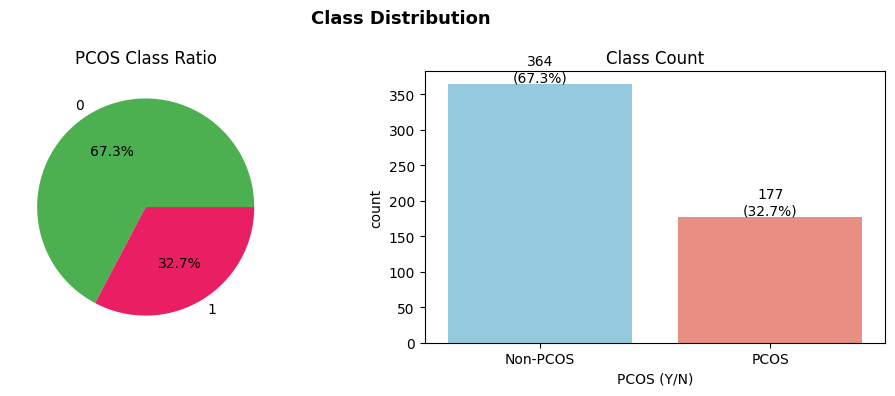

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_02_age.png


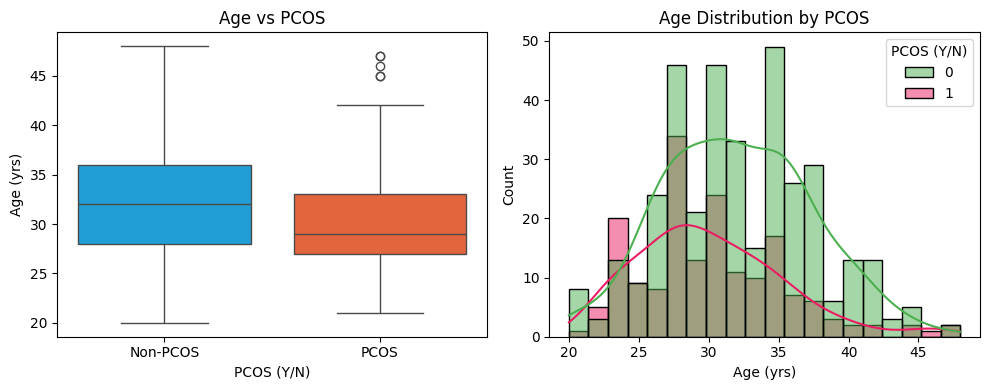

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_03_violin_hormones.png


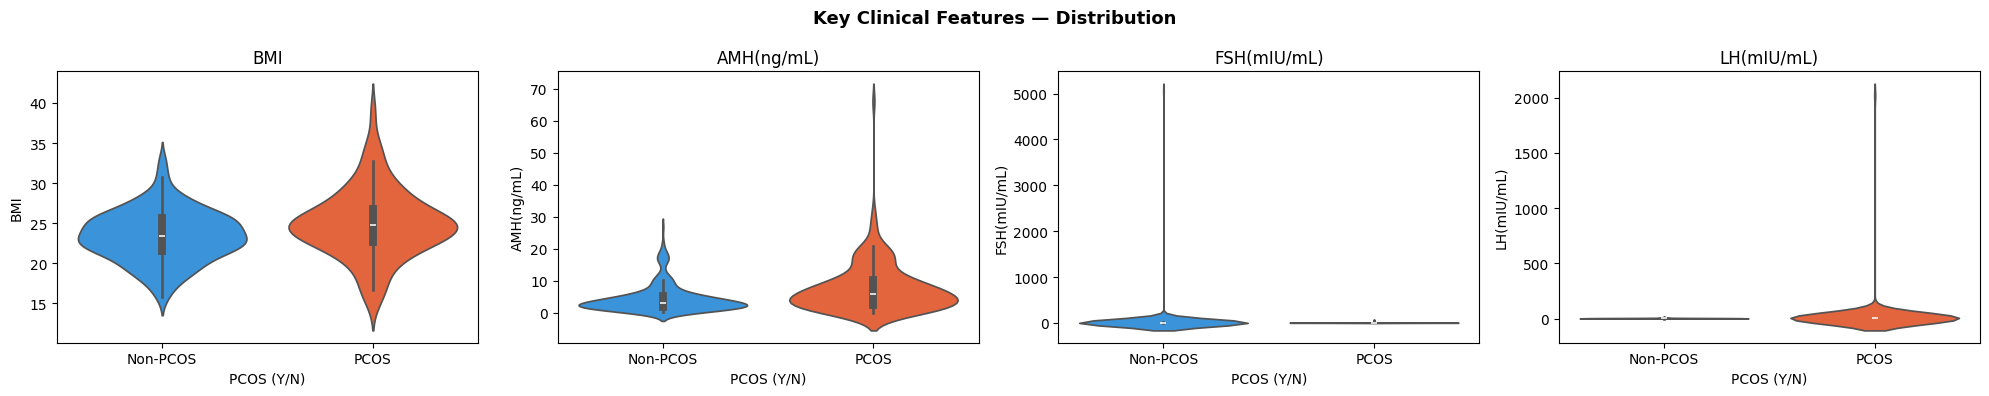

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_04_binary_symptoms.png


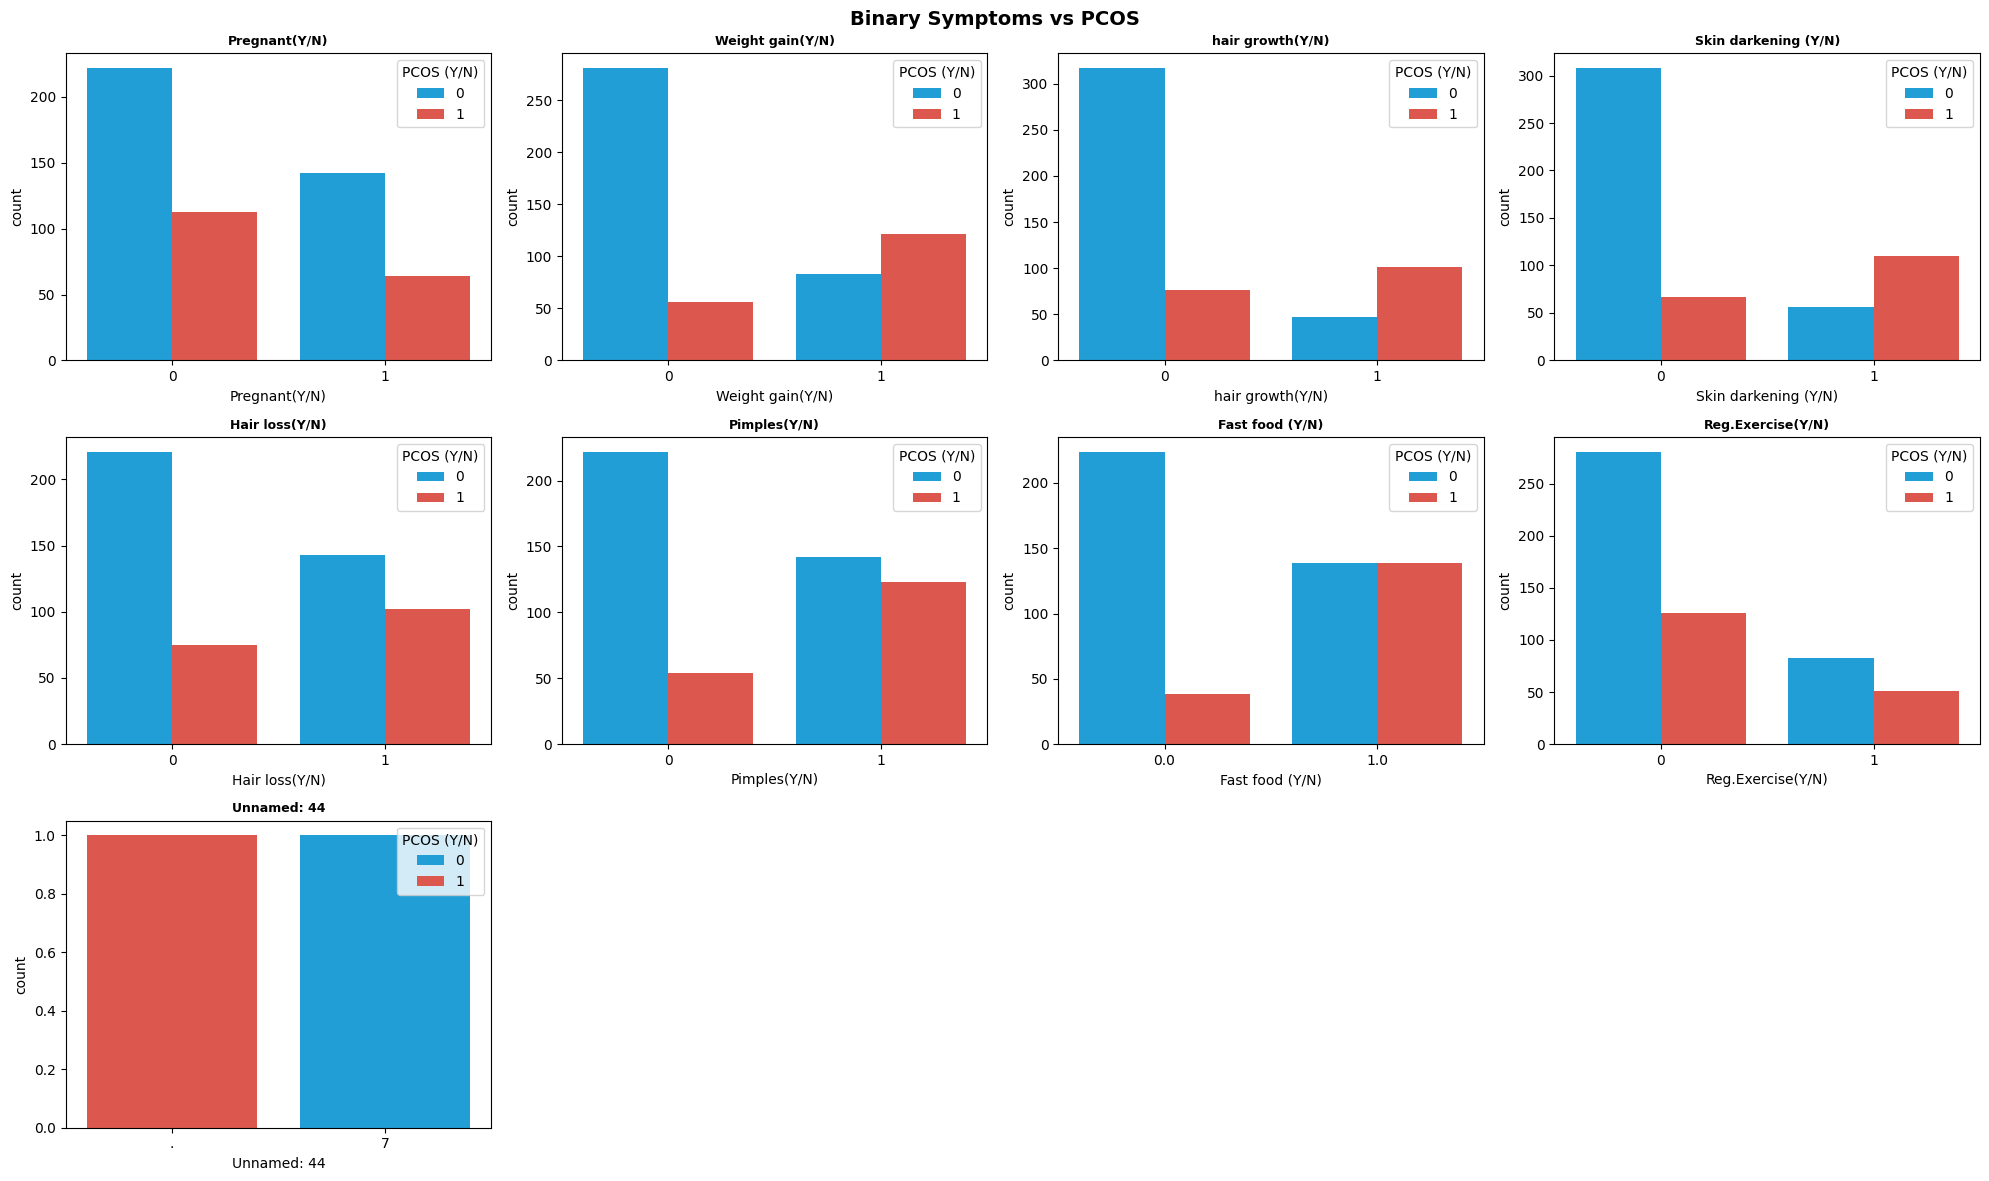

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_05_numeric_hist.png


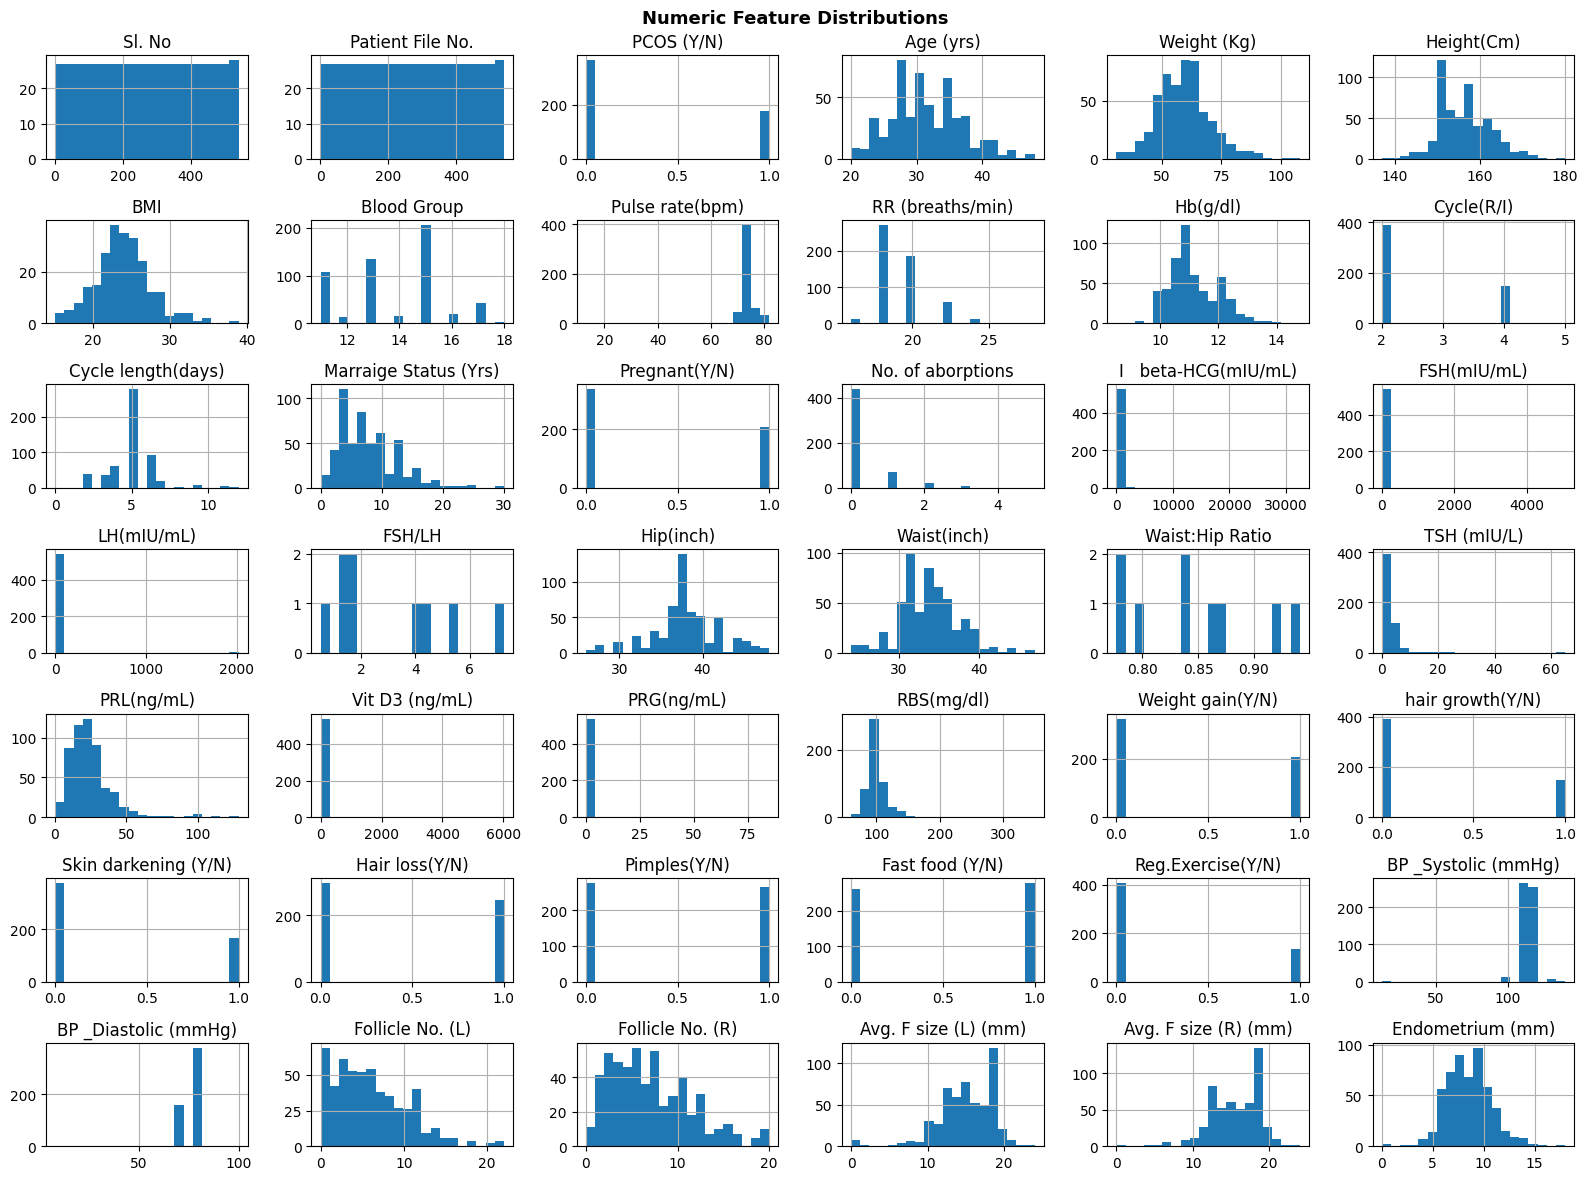

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_06_numeric_boxplots.png


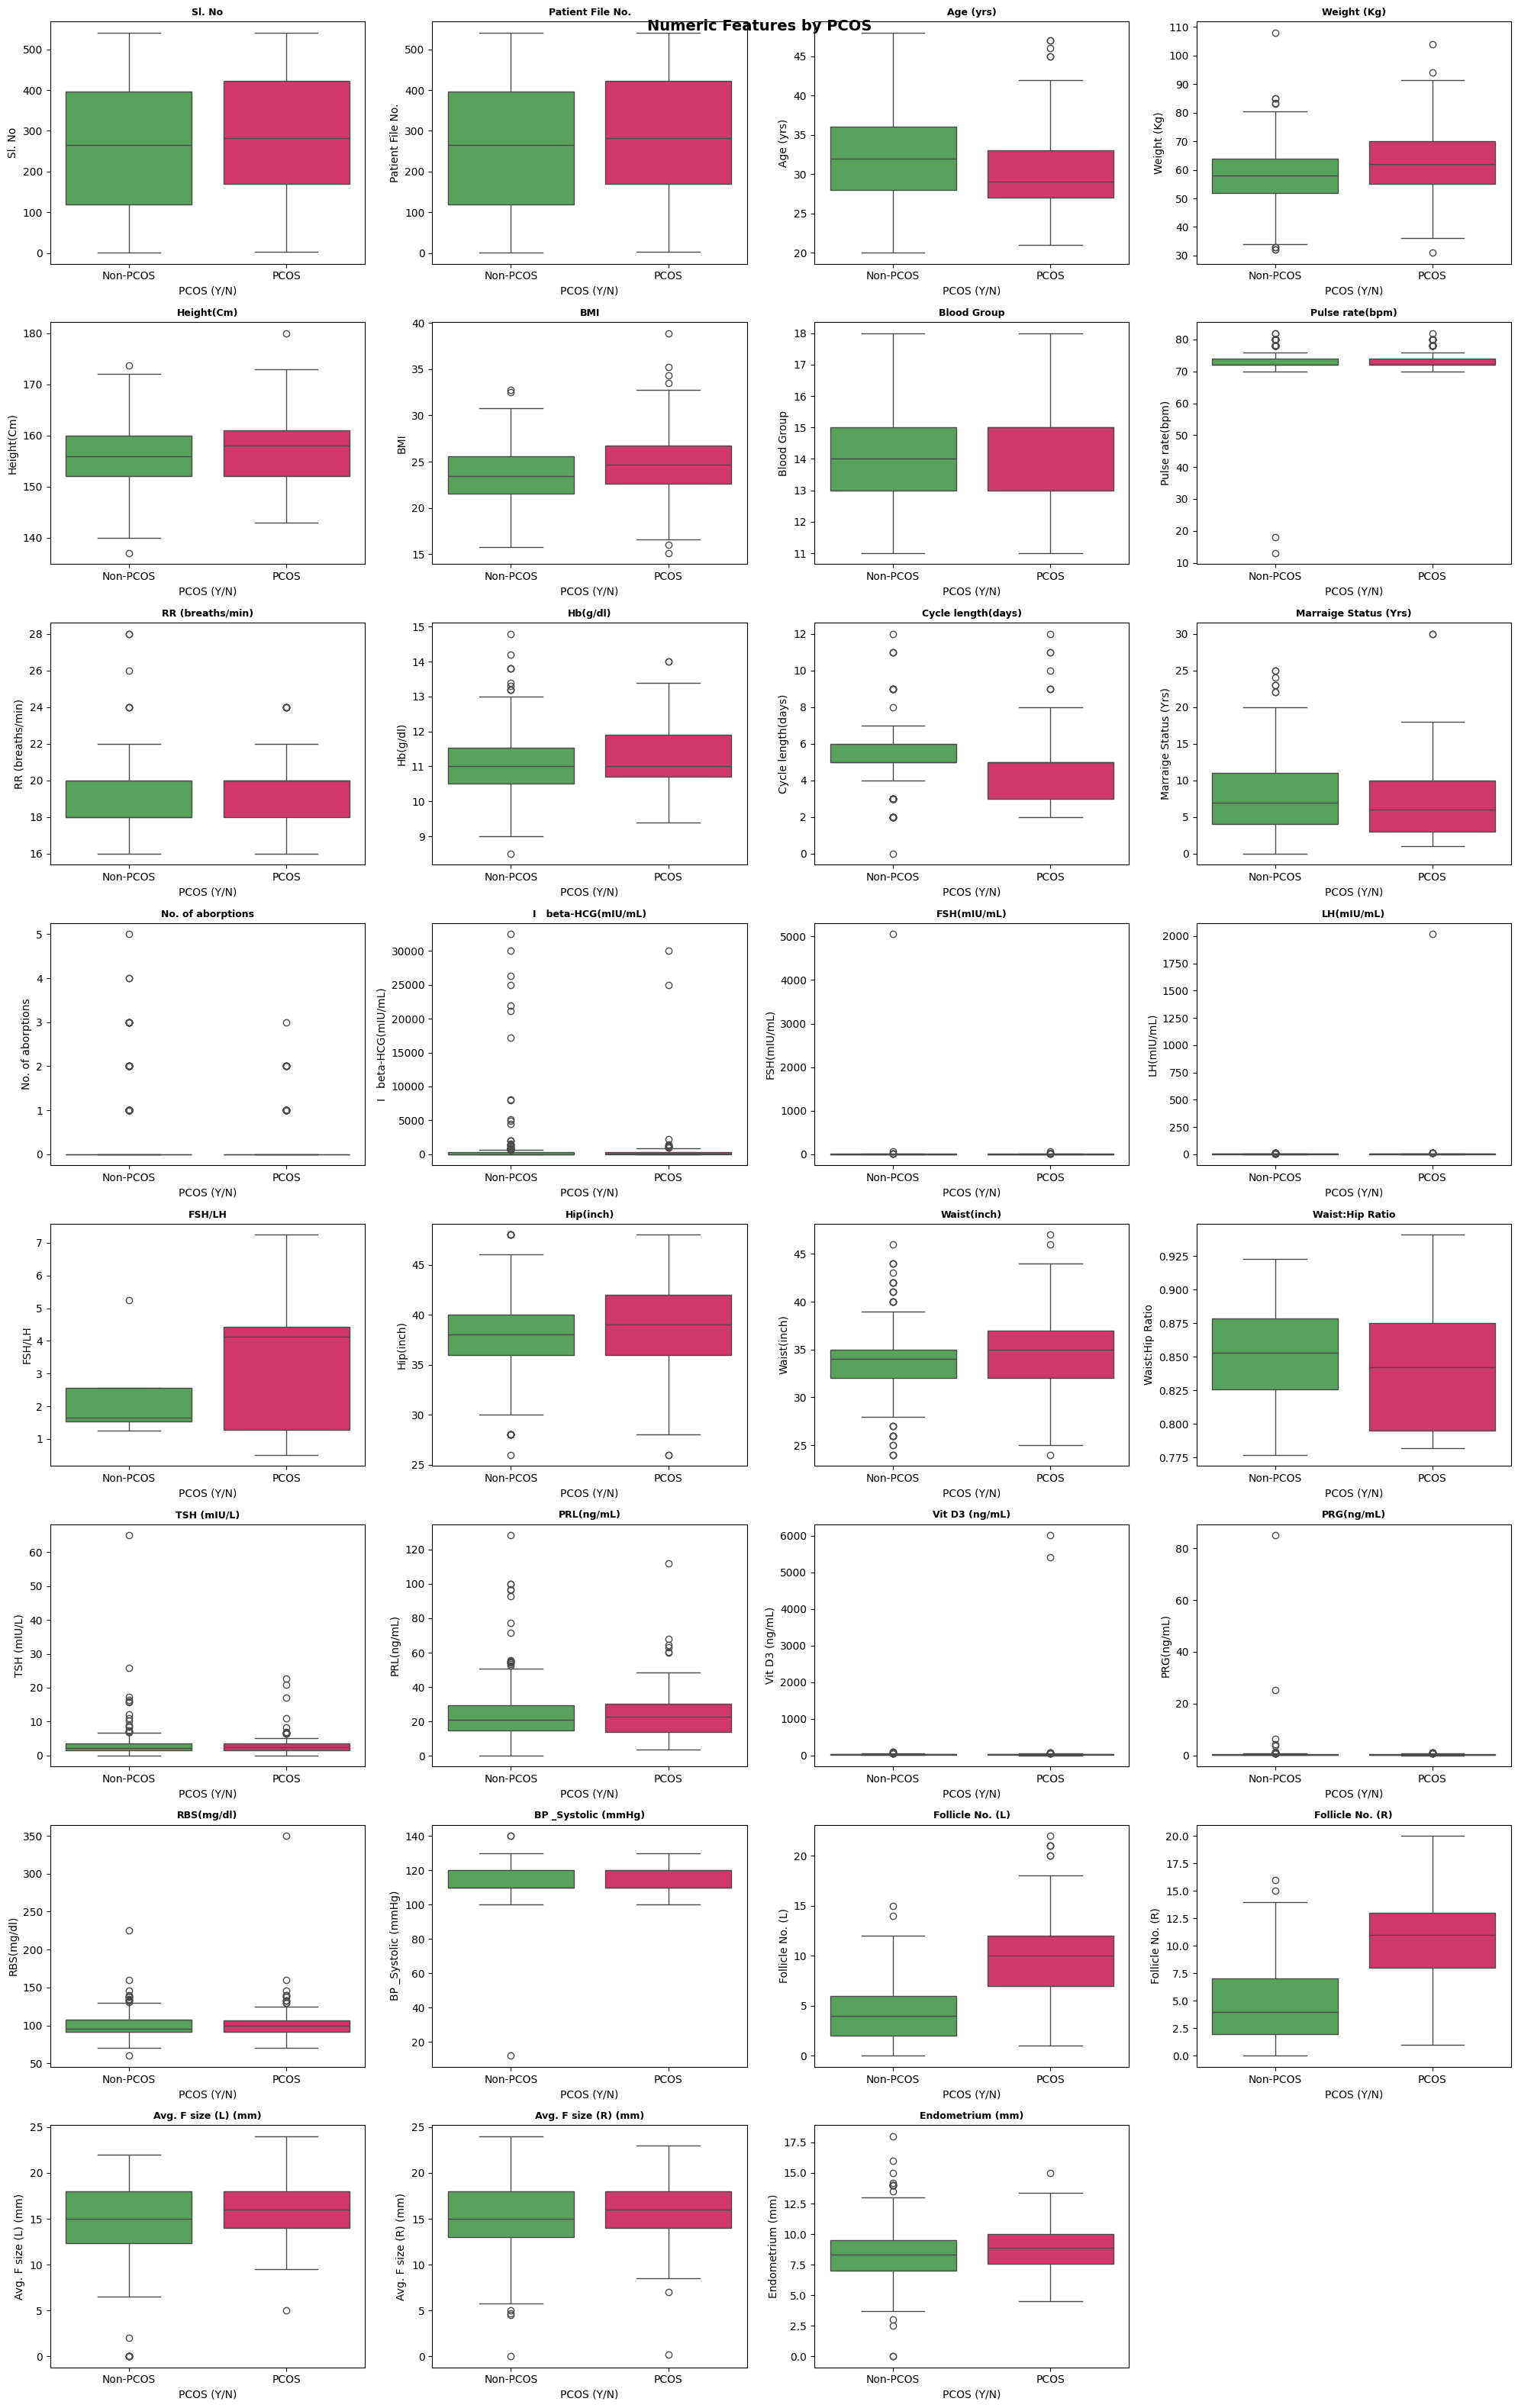

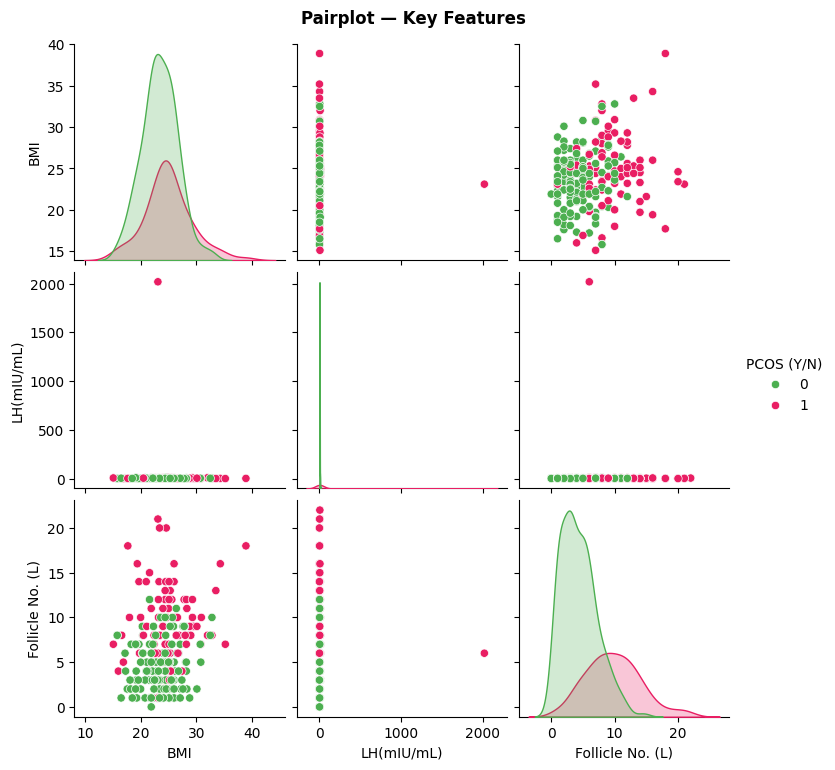

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_07_pairplot.png
  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eda_08_correlation.png


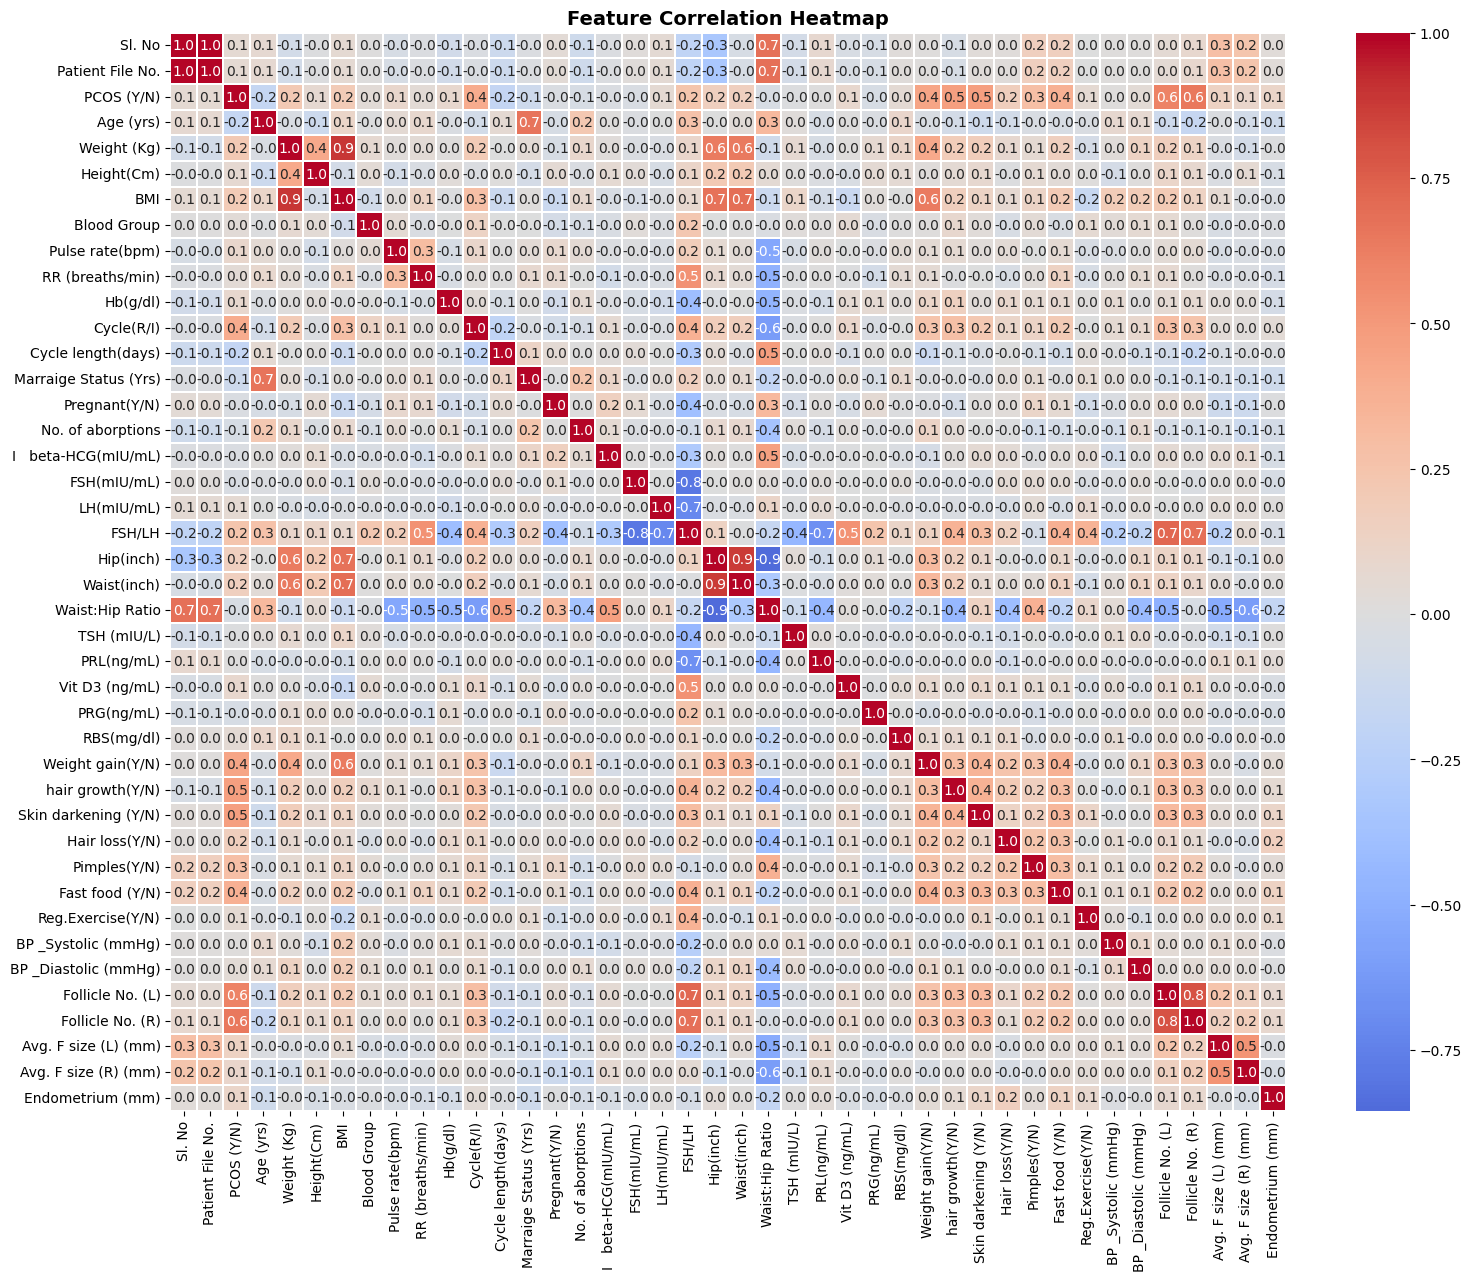

EDA complete — 8 plot sets saved
PCOS TABULAR CLASSIFICATION — FULL PIPELINE

BLOCK 4 — FEATURE ENGINEERING
Shape : (541, 42)  |  PCOS: 177  Non-PCOS: 364
Engineered: FSH_LH_Ratio, Total_Follicles, AMH_FSH_Ratio, BMI_Waist_Ratio, Androgenic_Score
Train: 432  Test: 109

BLOCK 5 — PREPROCESSING
MICE   train NaNs: 0 | test NaNs: 0
RobustScaler fit on train only | 42 features

BLOCK 6 — DOMAIN SEVERITY (OOF)
  METABOLIC        OOF AUC: 0.7752  features: 12
  REPRODUCTIVE     OOF AUC: 0.8948  features: 15
  HYPERANDROGENIC  OOF AUC: 0.8323  features: 6
  GENERAL          OOF AUC: 0.5555  features: 6
Final feature matrix: 47 cols (scaled + 5 severity cols)

BLOCK 7 — PER-MODEL TRAINING + EVALUATION

  MODEL: Logistic
                   Acc     AUC     Sen     Spe      F1     MCC   PR_AUC   Brier  TP  TN  FP  FN
  CV            0.8750  0.9279  0.8511  0.8866  0.8163  0.7232   0.8721  0.0957  120 258  33  21
  Test          0.8991  0.9570  0.9167  0.8904  0.8571  0.7836   0.9422  0.0764   33  

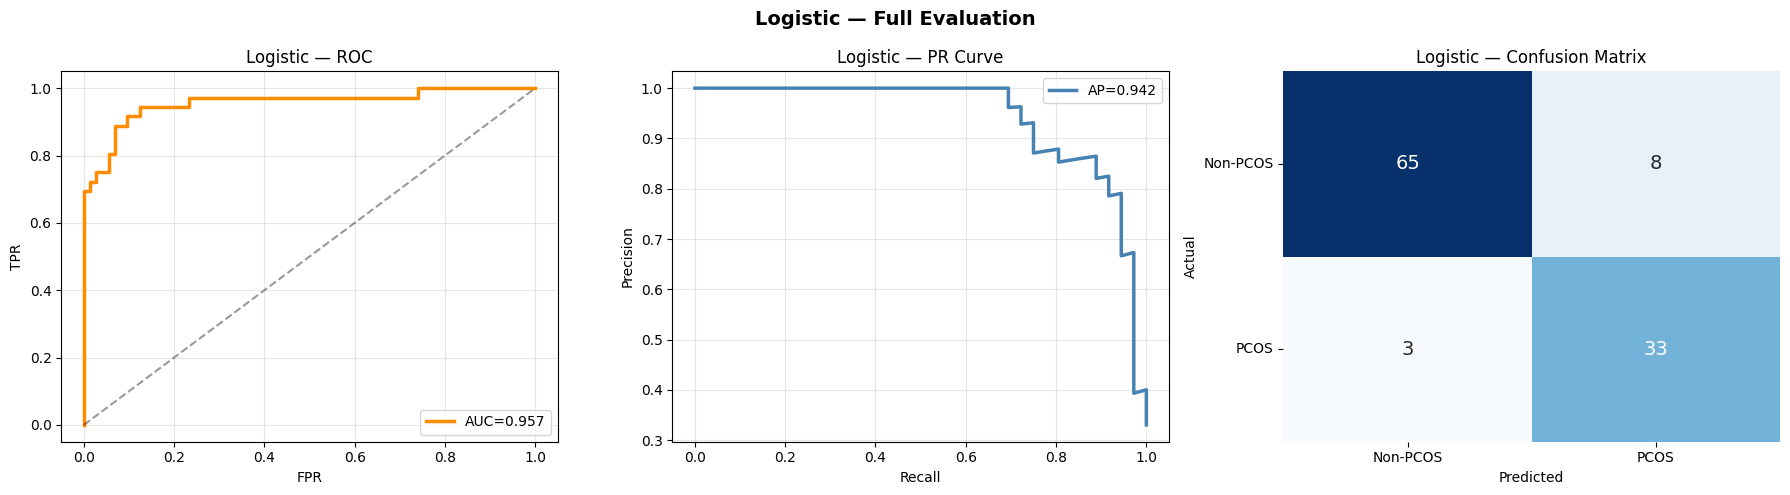

  Logistic — trained, evaluated, plot saved
  Metrics CSVs updated after Logistic

  MODEL: RandomForest
                   Acc     AUC     Sen     Spe      F1     MCC   PR_AUC   Brier  TP  TN  FP  FN
  CV            0.8958  0.9548  0.7943  0.9450  0.8327  0.7592   0.9206  0.0784  112 275  16  29
  Test          0.9174  0.9581  0.7778  0.9863  0.8615  0.8132   0.9475  0.0666   28  72   1   8
              precision    recall  f1-score   support

    Non-PCOS       0.90      0.99      0.94        73
        PCOS       0.97      0.78      0.86        36

    accuracy                           0.92       109
   macro avg       0.93      0.88      0.90       109
weighted avg       0.92      0.92      0.91       109

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eval_randomforest.png


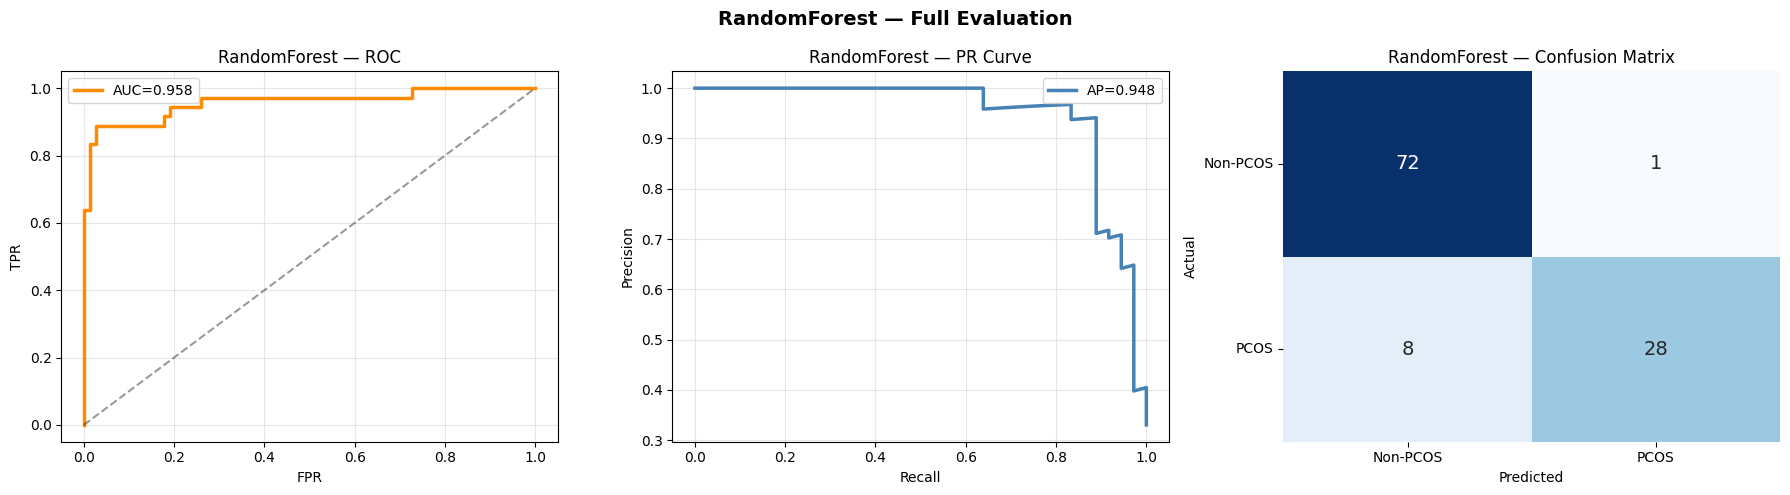

  RandomForest — trained, evaluated, plot saved
  Metrics CSVs updated after RandomForest

  MODEL: GradientBoost
                   Acc     AUC     Sen     Spe      F1     MCC   PR_AUC   Brier  TP  TN  FP  FN
  CV            0.8750  0.9398  0.7801  0.9210  0.8029  0.7122   0.9080  0.0894  110 268  23  31
  Test          0.9083  0.9623  0.7500  0.9863  0.8438  0.7926   0.9527  0.0647   27  72   1   9
              precision    recall  f1-score   support

    Non-PCOS       0.89      0.99      0.94        73
        PCOS       0.96      0.75      0.84        36

    accuracy                           0.91       109
   macro avg       0.93      0.87      0.89       109
weighted avg       0.91      0.91      0.90       109

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eval_gradientboost.png


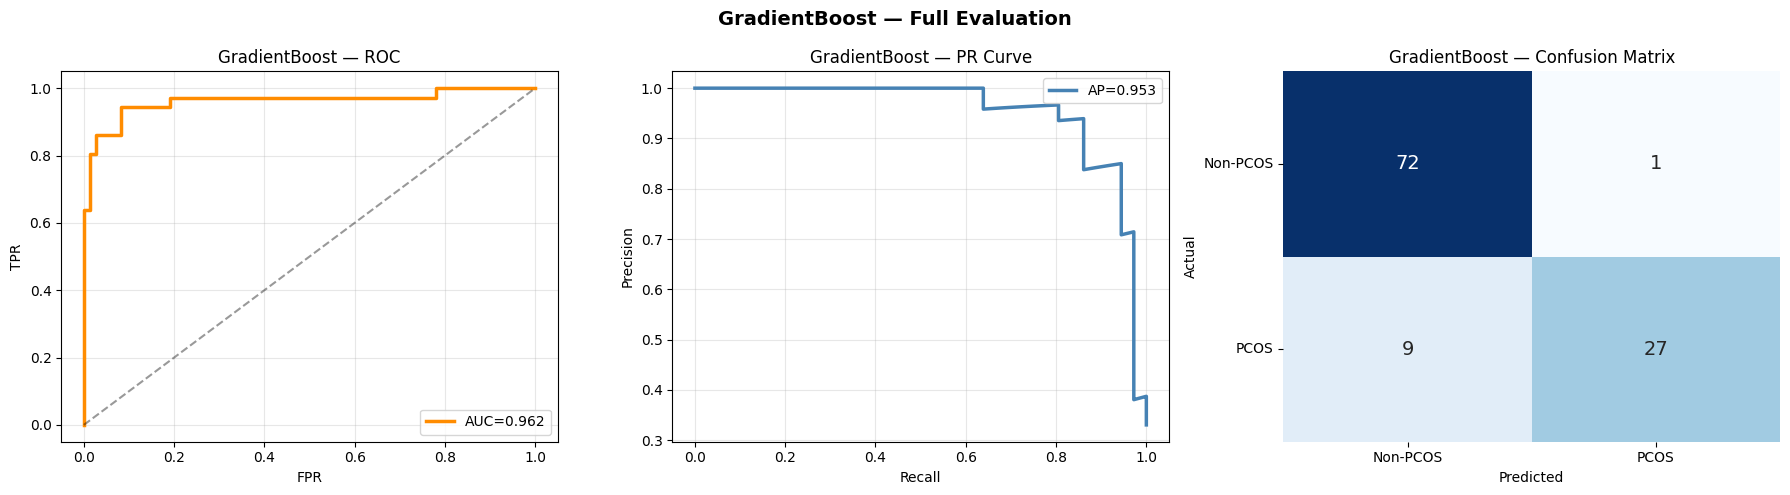

  GradientBoost — trained, evaluated, plot saved
  Metrics CSVs updated after GradientBoost

  MODEL: CatBoost
                   Acc     AUC     Sen     Spe      F1     MCC   PR_AUC   Brier  TP  TN  FP  FN
  CV            0.8866  0.9448  0.8652  0.8969  0.8328  0.7483   0.9168  0.0859  122 261  30  19
  Test          0.9266  0.9578  0.8611  0.9589  0.8857  0.8325   0.9427  0.0653   31  70   3   5
              precision    recall  f1-score   support

    Non-PCOS       0.93      0.96      0.95        73
        PCOS       0.91      0.86      0.89        36

    accuracy                           0.93       109
   macro avg       0.92      0.91      0.92       109
weighted avg       0.93      0.93      0.93       109

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eval_catboost.png


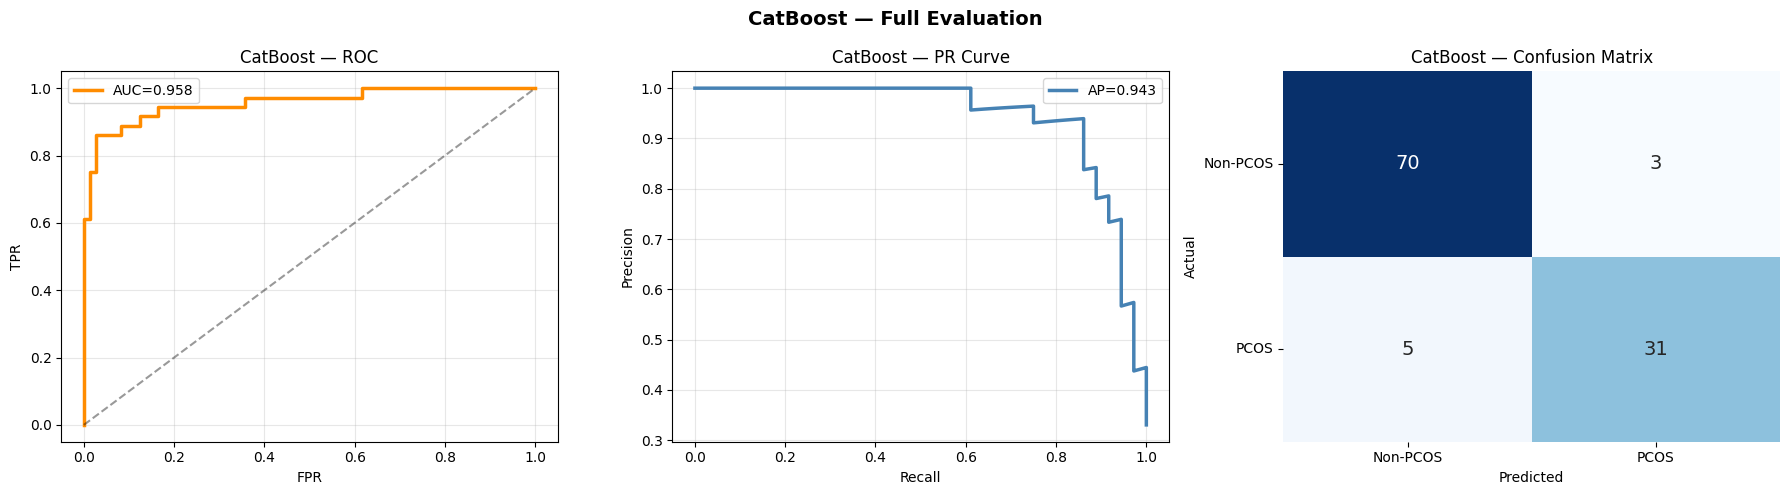

  CatBoost — trained, evaluated, plot saved
  Metrics CSVs updated after CatBoost

BLOCK 8 — STACKED ENSEMBLE

  MODEL: Stacked Ensemble (Meta-Learner)
  Ensemble CV  AUC: 0.9488 ± 0.0257 | F1: 0.8315 ± 0.0679 | Acc: 0.8892 ± 0.0513
  Optimal threshold (Youden J): 0.3161
                   Acc     AUC     Sen     Spe      F1     MCC   PR_AUC   Brier  TP  TN  FP  FN
  CV            0.8889  0.9428  0.8156  0.9244  0.8273  0.7456   0.8872  0.0837  115 269  22  26
  Test          0.9541  0.9532  0.8889  0.9863  0.9275  0.8959   0.9413  0.0638   32  72   1   4
              precision    recall  f1-score   support

    Non-PCOS       0.95      0.99      0.97        73
        PCOS       0.97      0.89      0.93        36

    accuracy                           0.95       109
   macro avg       0.96      0.94      0.95       109
weighted avg       0.95      0.95      0.95       109

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/eval_ensemble.png


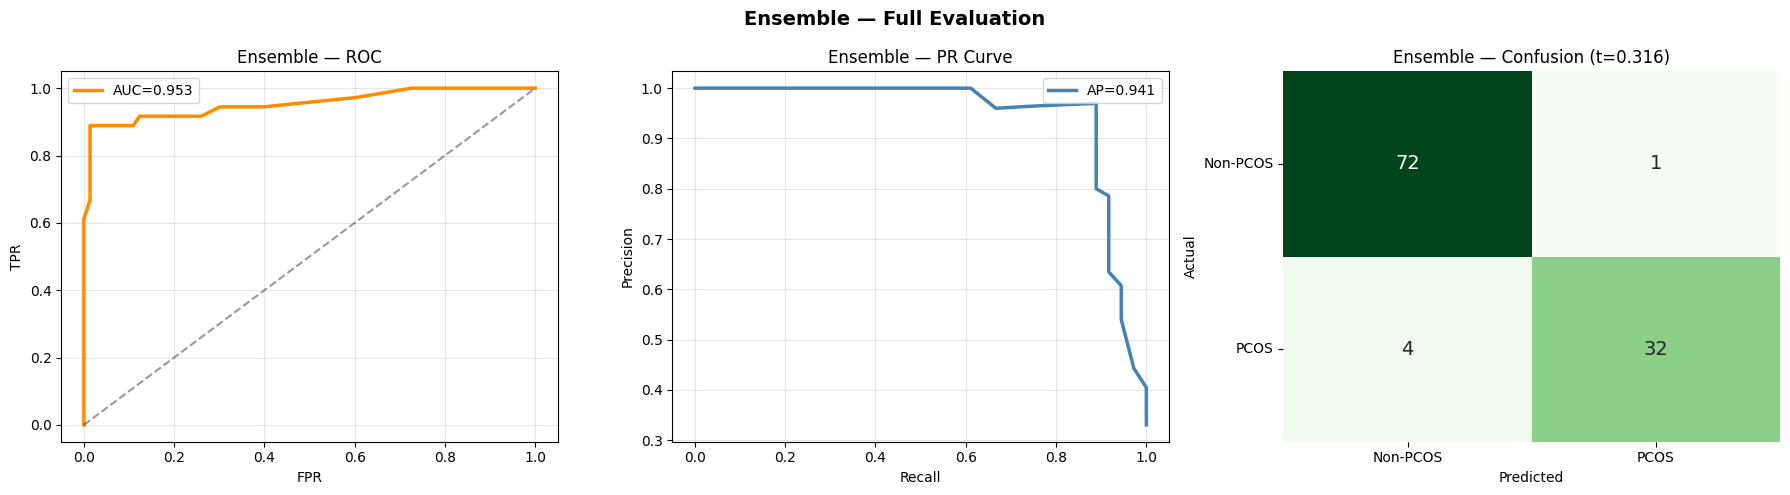

  Ensemble — trained, evaluated, plot saved

CV METRICS — ALL MODELS
        Model  Accuracy  ROC_AUC  Sensitivity  Specificity     F1    MCC  PR_AUC  Brier  TP  TN  FP  FN
 RandomForest    0.8958   0.9548       0.7943       0.9450 0.8327 0.7592  0.9206 0.0784 112 275  16  29
     CatBoost    0.8866   0.9448       0.8652       0.8969 0.8328 0.7483  0.9168 0.0859 122 261  30  19
     Ensemble    0.8889   0.9428       0.8156       0.9244 0.8273 0.7456  0.8872 0.0837 115 269  22  26
GradientBoost    0.8750   0.9398       0.7801       0.9210 0.8029 0.7122  0.9080 0.0894 110 268  23  31
     Logistic    0.8750   0.9279       0.8511       0.8866 0.8163 0.7232  0.8721 0.0957 120 258  33  21

TEST METRICS — ALL MODELS
        Model  Accuracy  ROC_AUC  Sensitivity  Specificity     F1    MCC  PR_AUC  Brier  TP  TN  FP  FN
GradientBoost    0.9083   0.9623       0.7500       0.9863 0.8438 0.7926  0.9527 0.0647  27  72   1   9
 RandomForest    0.9174   0.9581       0.7778       0.9863 0.8615 0.8132

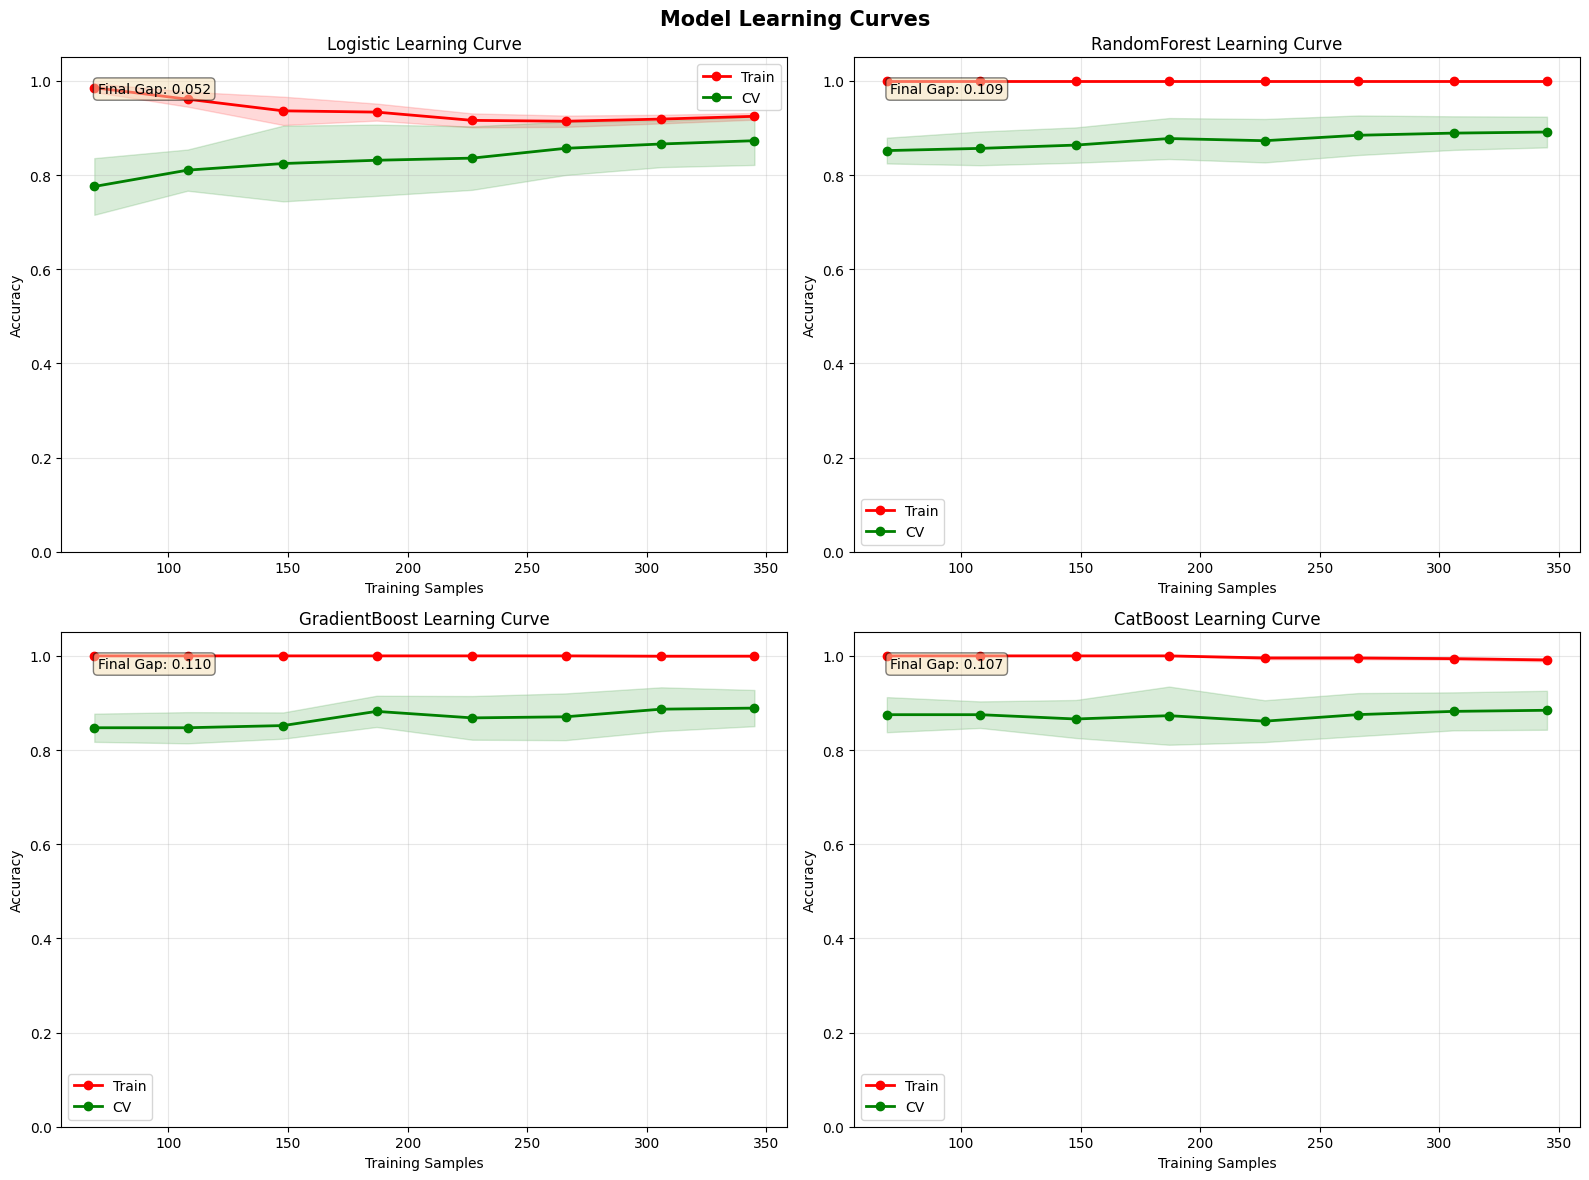

Learning curves saved

BLOCK 10 — CALIBRATION + ALL-MODEL COMPARISON + DECISION CURVE
  Saved: /content/PCOS_RESULTS_TABULAR2/plots/calibration.png


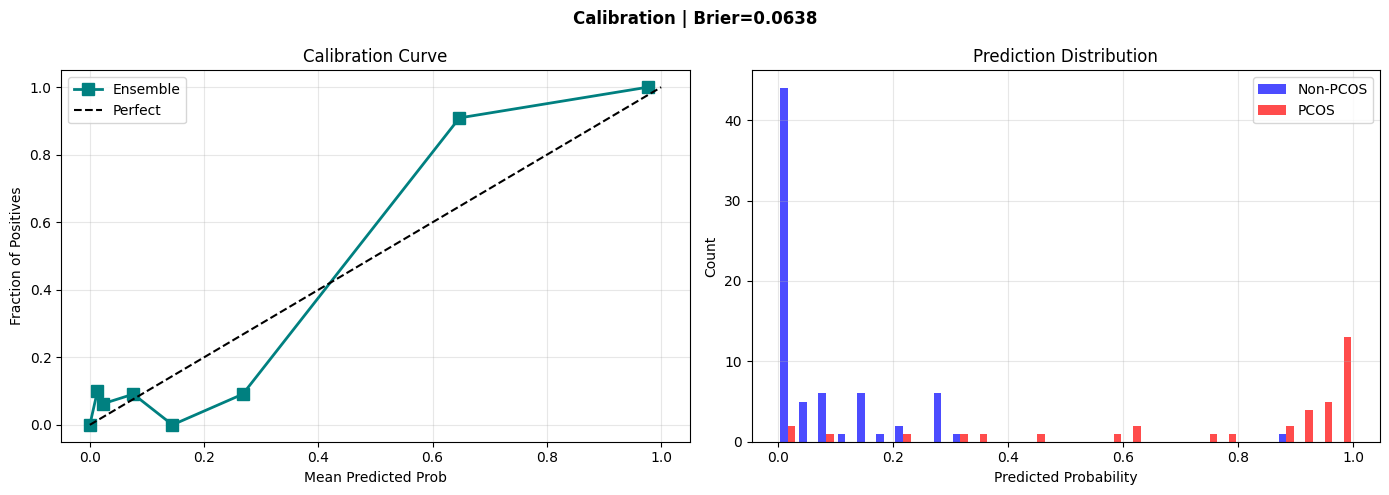

  Brier Score: 0.0638
  Saved: /content/PCOS_RESULTS_TABULAR2/plots/compare_roc_pr.png


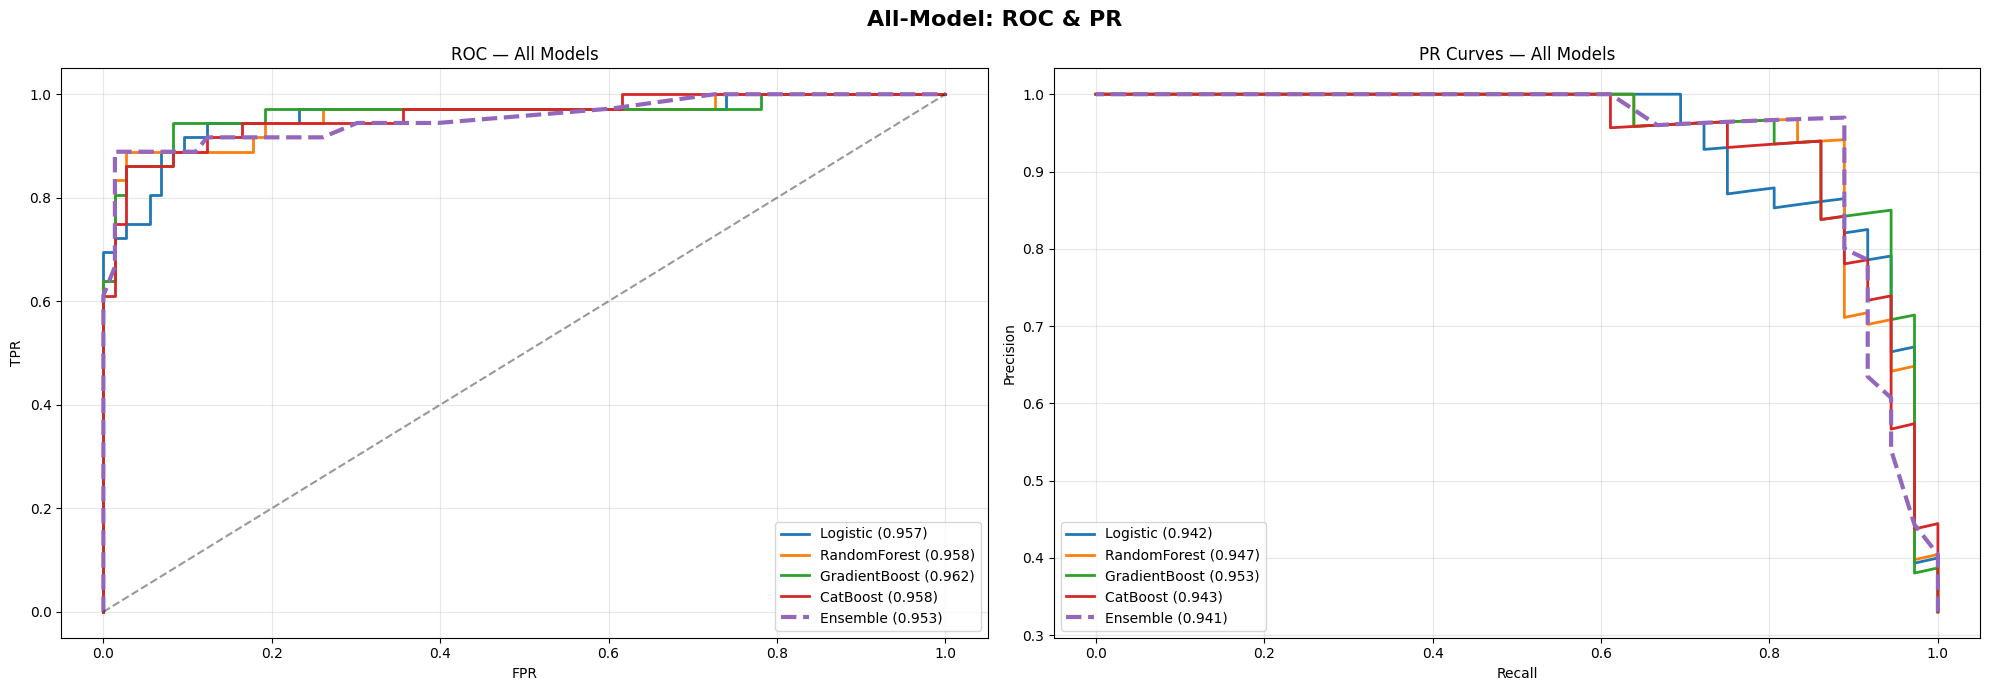

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/compare_confusion.png


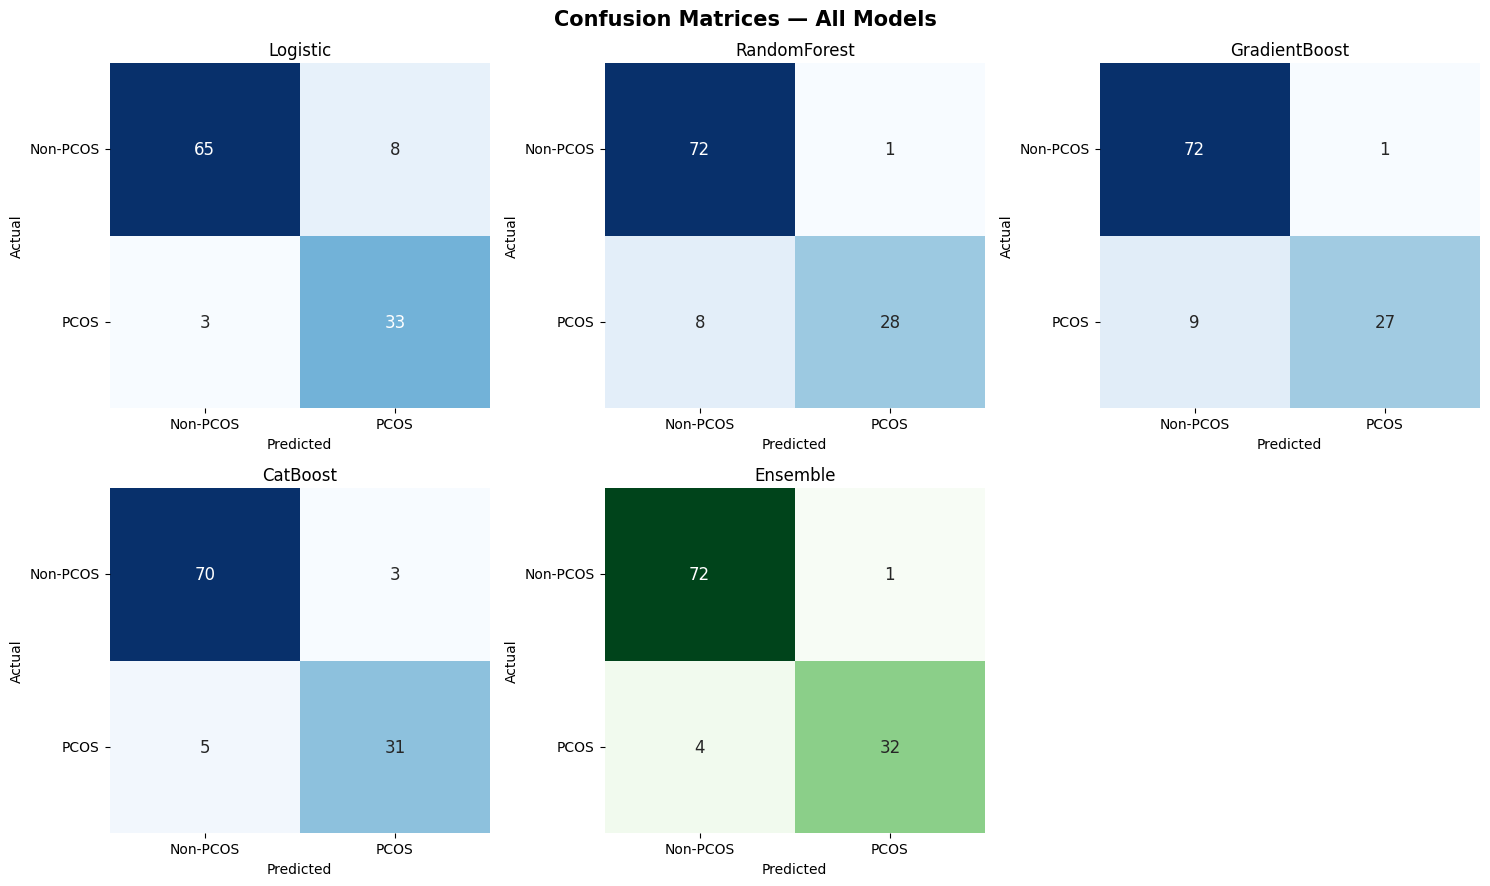

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/compare_metrics_bar.png


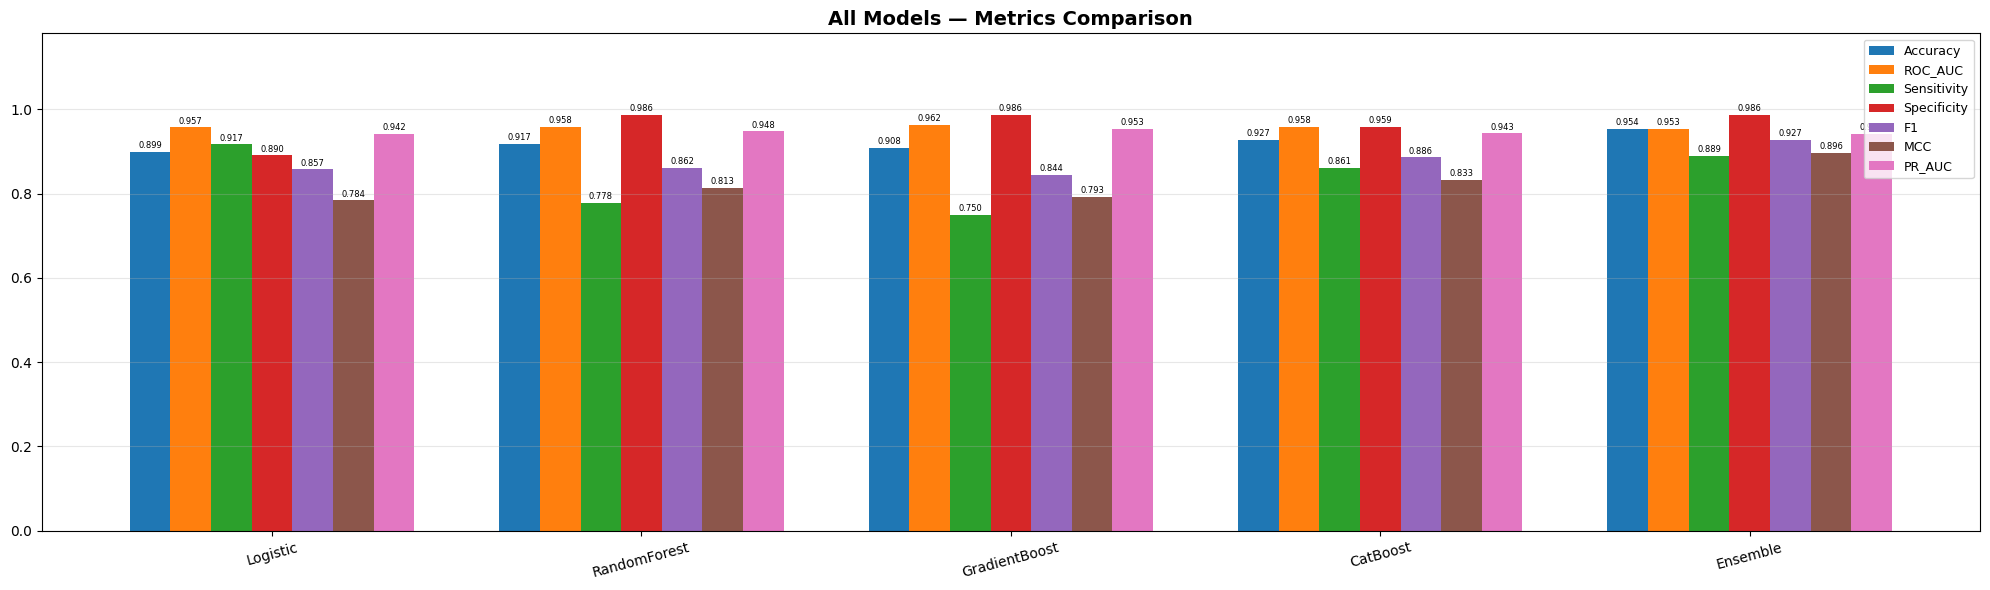

  Saved: /content/PCOS_RESULTS_TABULAR2/plots/decision_curve.png


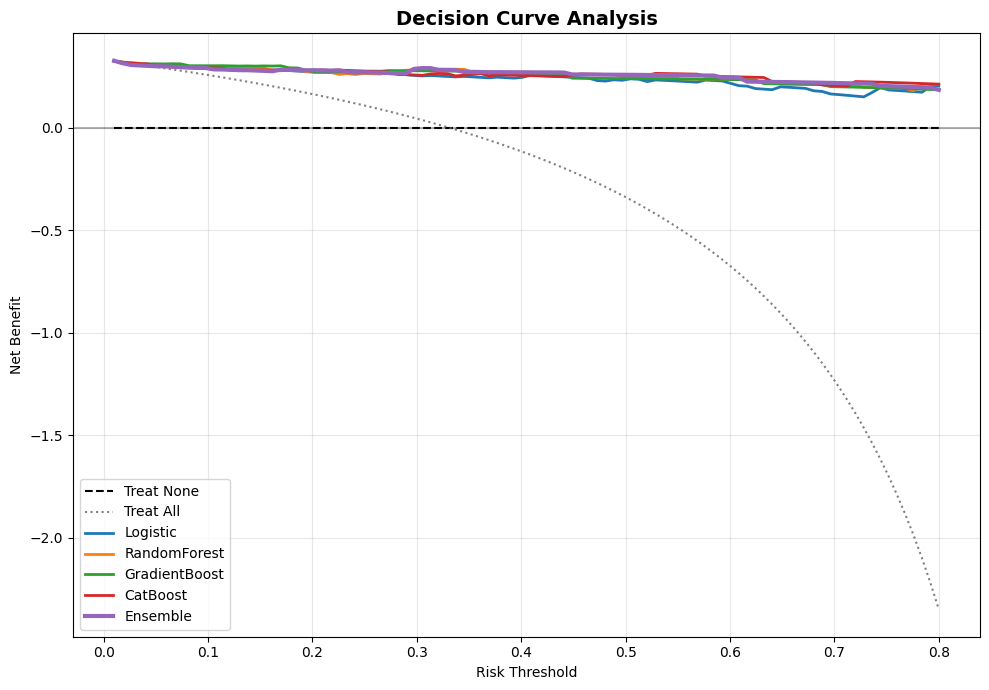


BLOCK 11 — PATIENT SEVERITY SCORES
Severity scores saved: /content/PCOS_RESULTS_TABULAR2/patient_severity_scores.csv  shape=(541, 9)

Risk Distribution:
Risk_Category
Low         359
High        124
Moderate     58
  Saved: /content/PCOS_RESULTS_TABULAR2/plots/severity_distribution.png


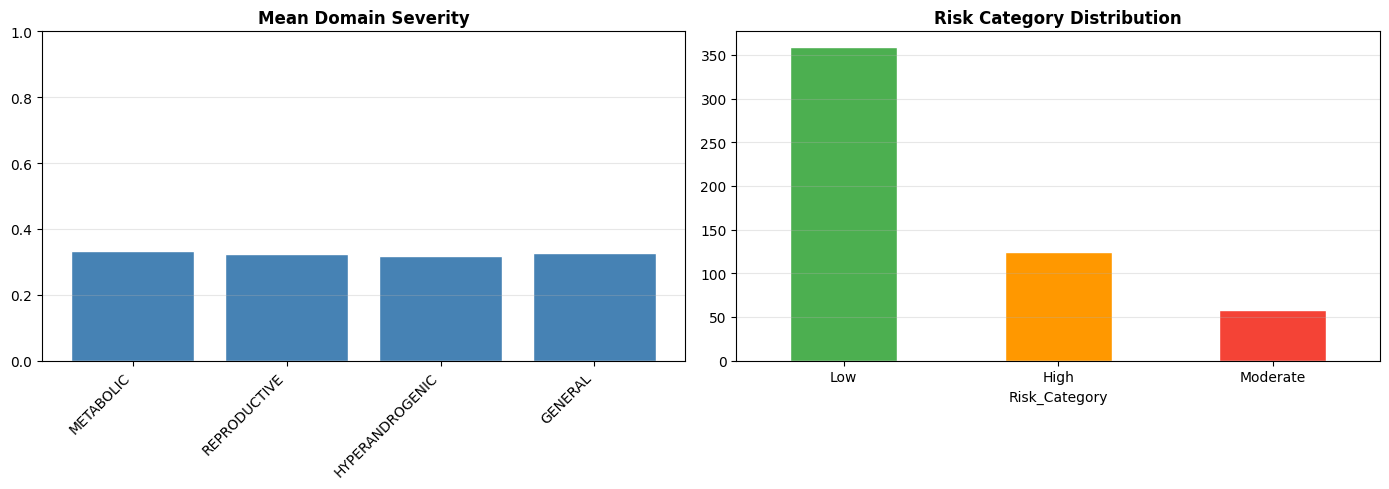


BLOCK 12 — SHAP EXPLAINABILITY (ALL models)

  SHAP: Logistic


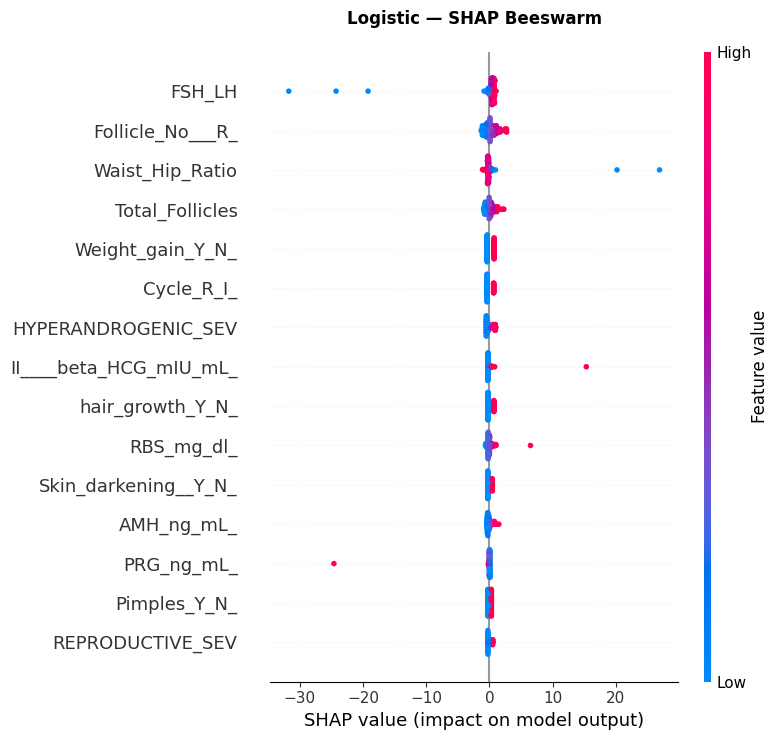

  Saved: Logistic_beeswarm.png


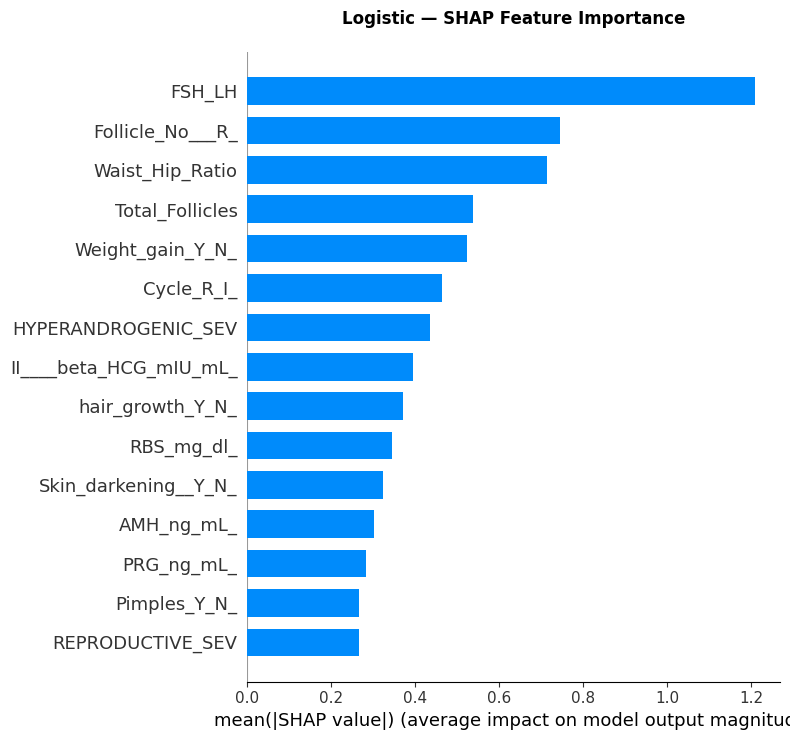

  Saved: Logistic_bar.png


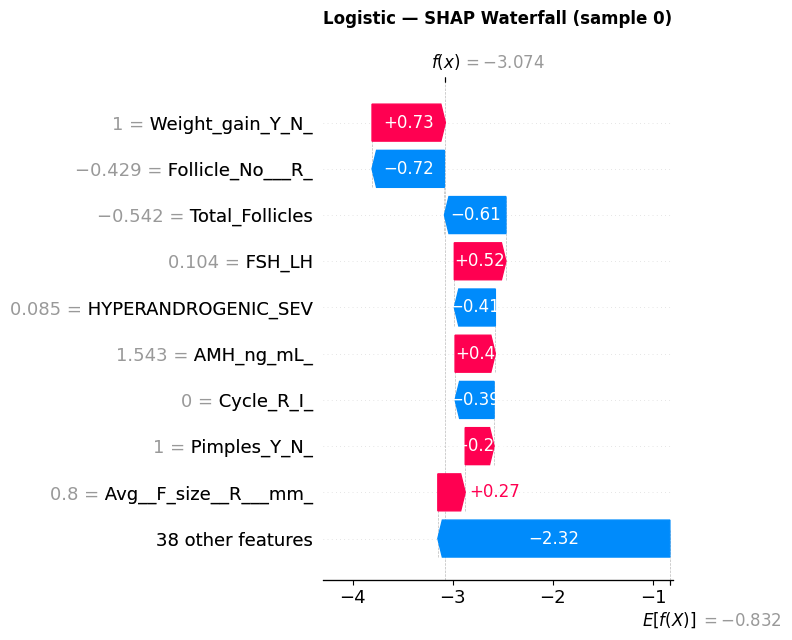

  Saved: Logistic_waterfall.png


<Figure size 1600x300 with 0 Axes>

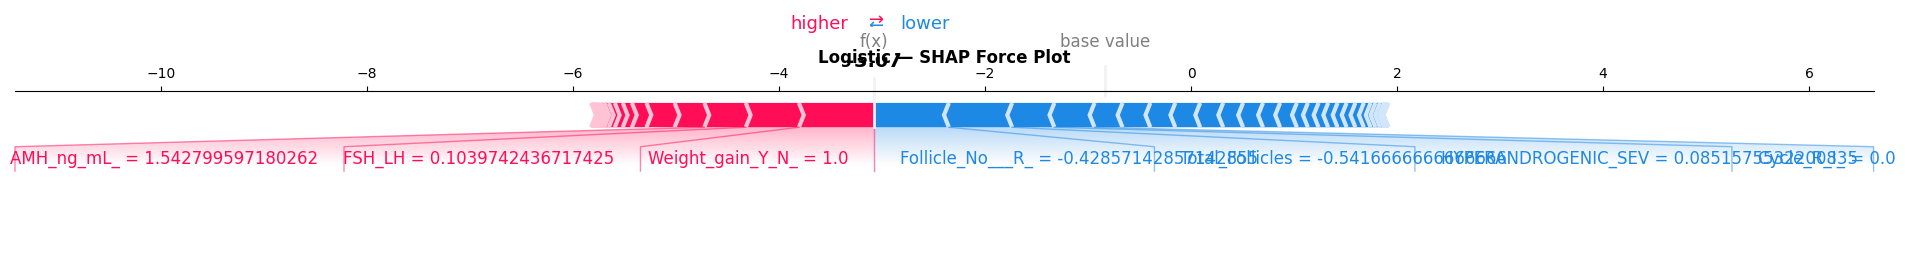

  Saved: Logistic_force.png

  SHAP: RandomForest


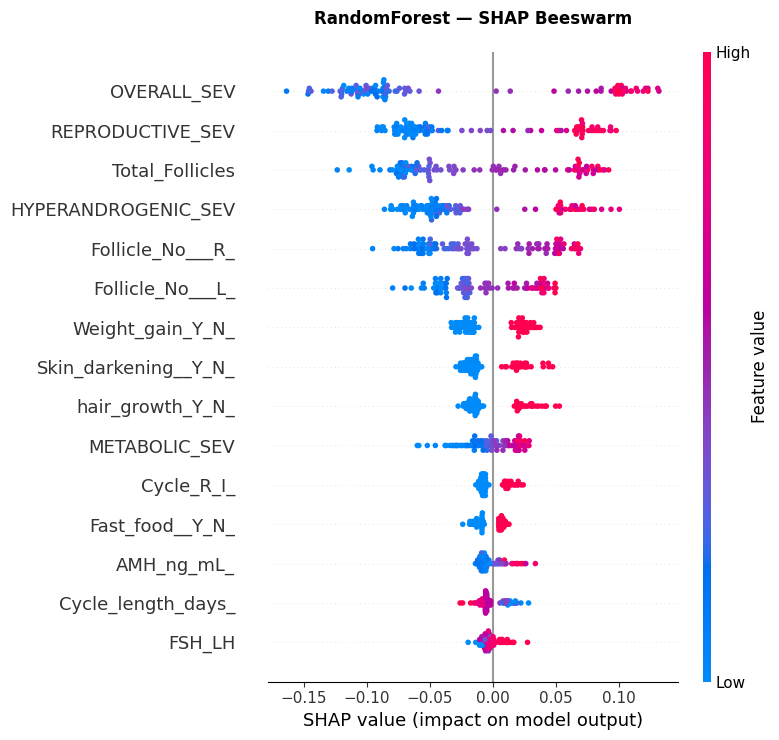

  Saved: RandomForest_beeswarm.png


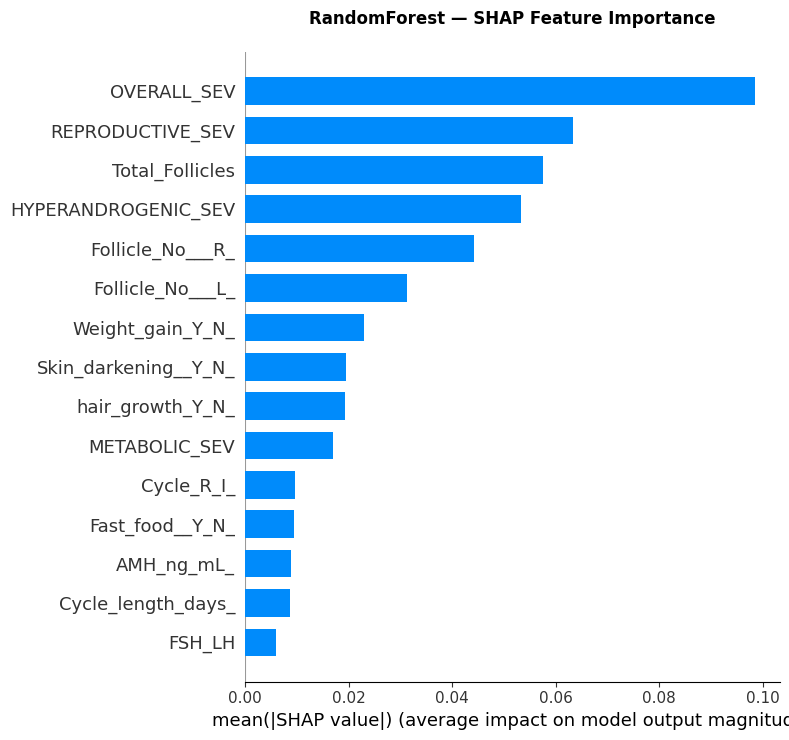

  Saved: RandomForest_bar.png


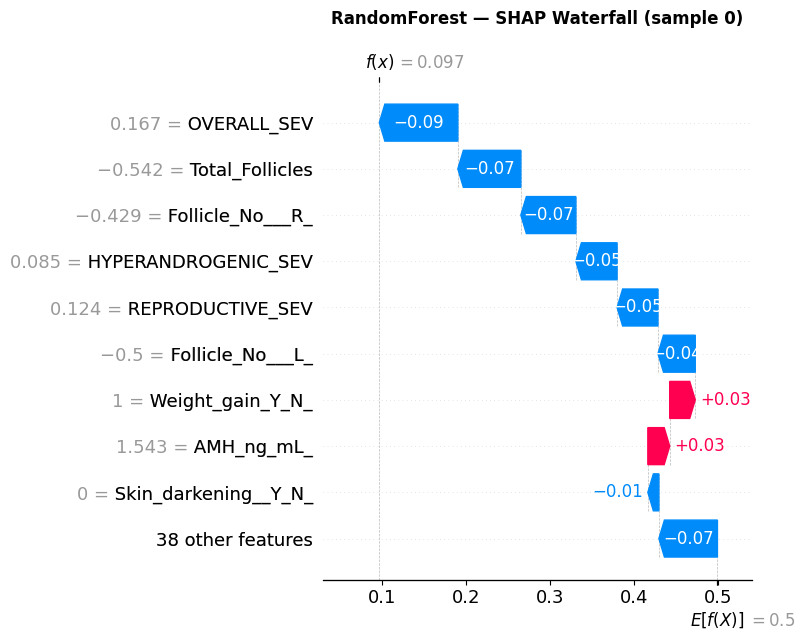

  Saved: RandomForest_waterfall.png


<Figure size 1600x300 with 0 Axes>

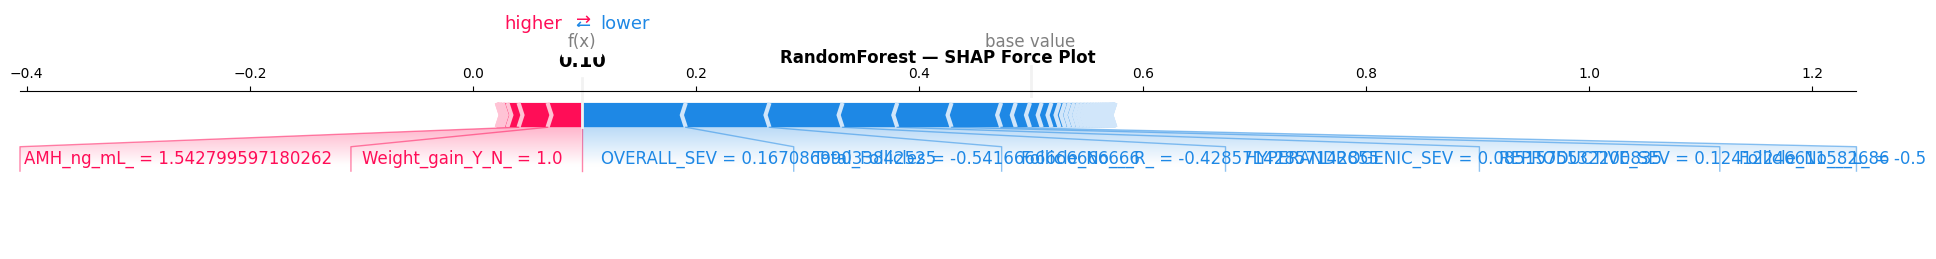

  Saved: RandomForest_force.png

  SHAP: GradientBoost


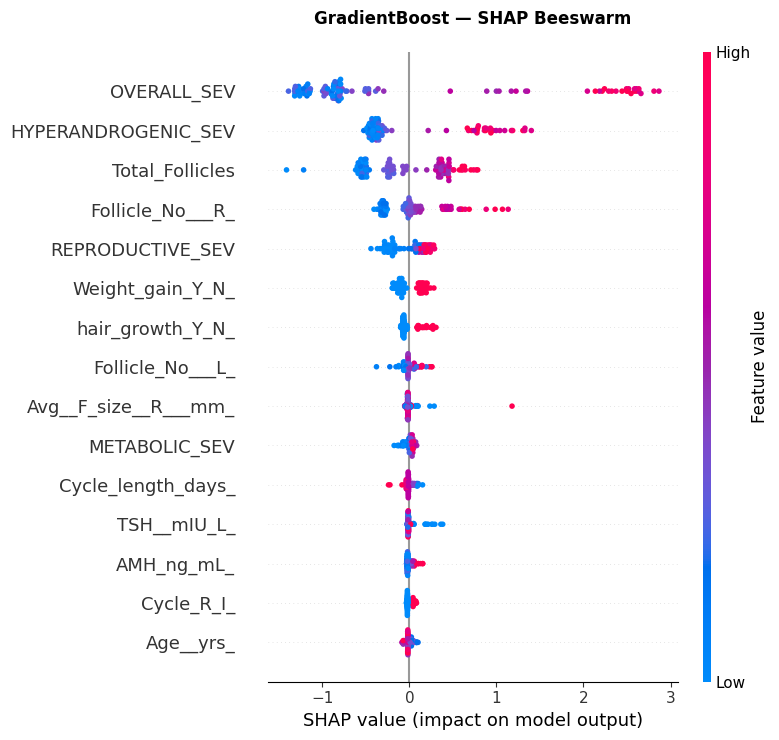

  Saved: GradientBoost_beeswarm.png


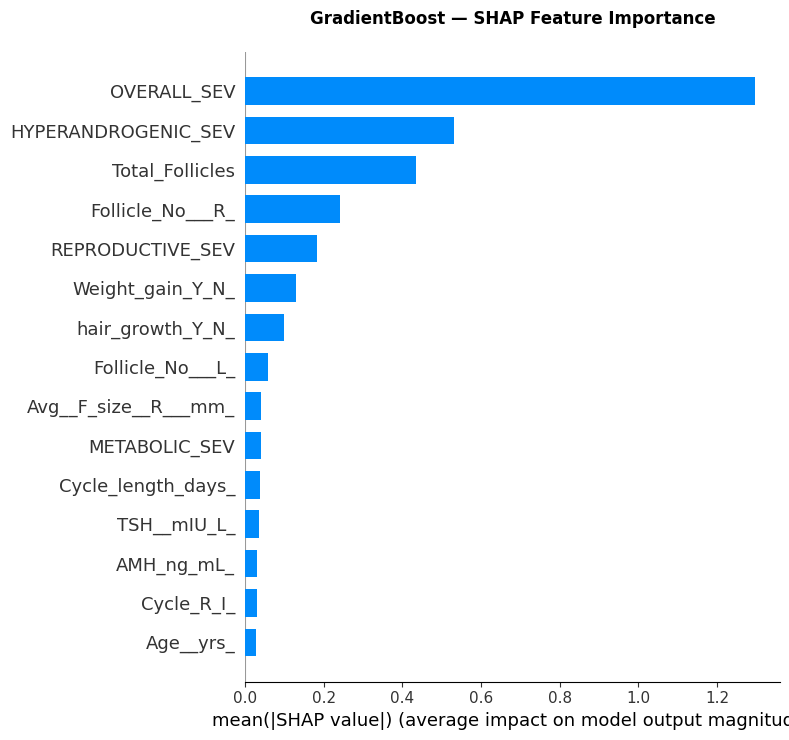

  Saved: GradientBoost_bar.png


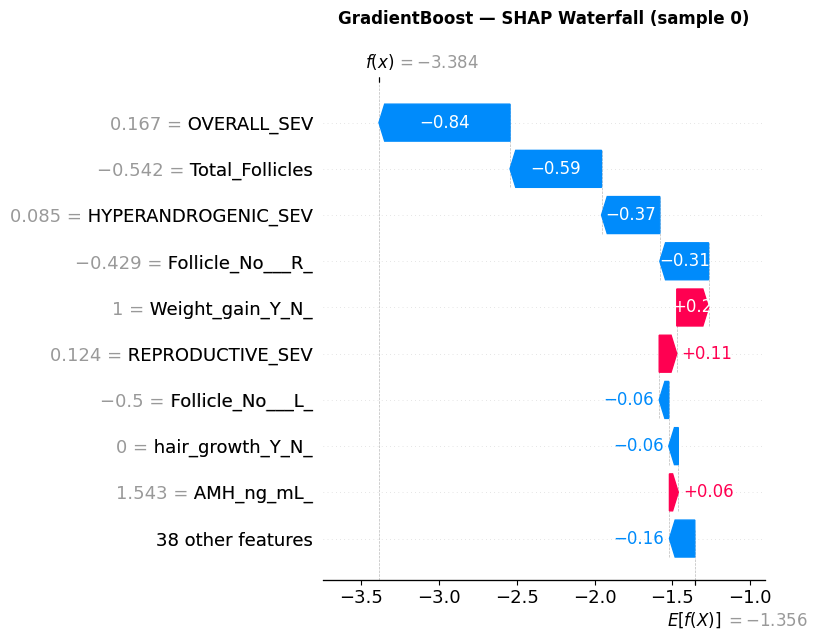

  Saved: GradientBoost_waterfall.png


<Figure size 1600x300 with 0 Axes>

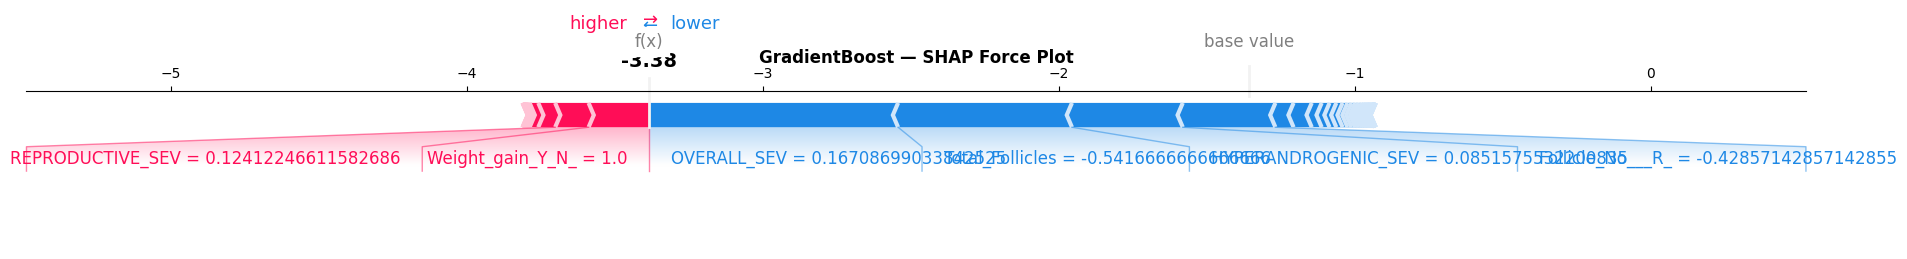

  Saved: GradientBoost_force.png

  SHAP: CatBoost


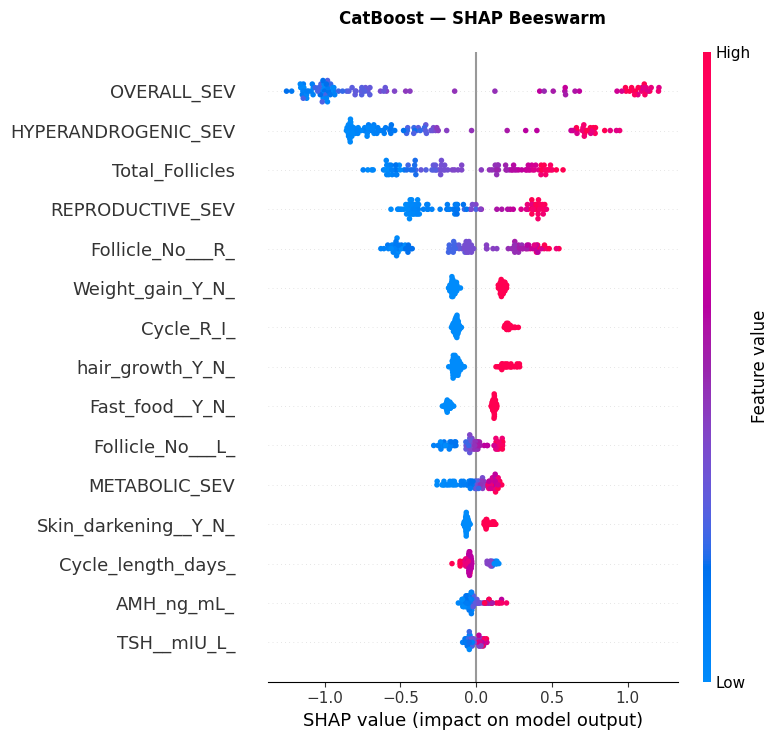

  Saved: CatBoost_beeswarm.png


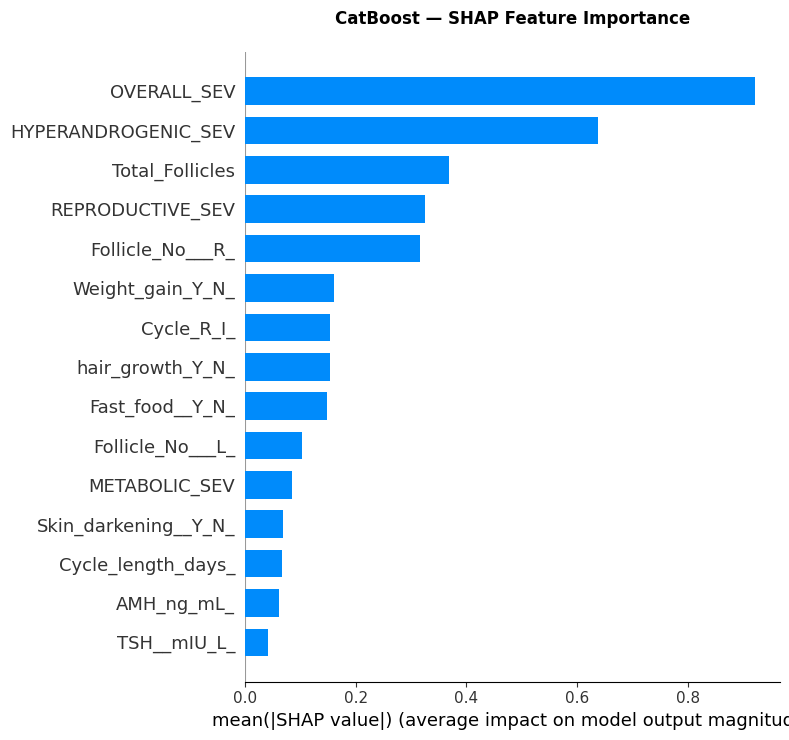

  Saved: CatBoost_bar.png


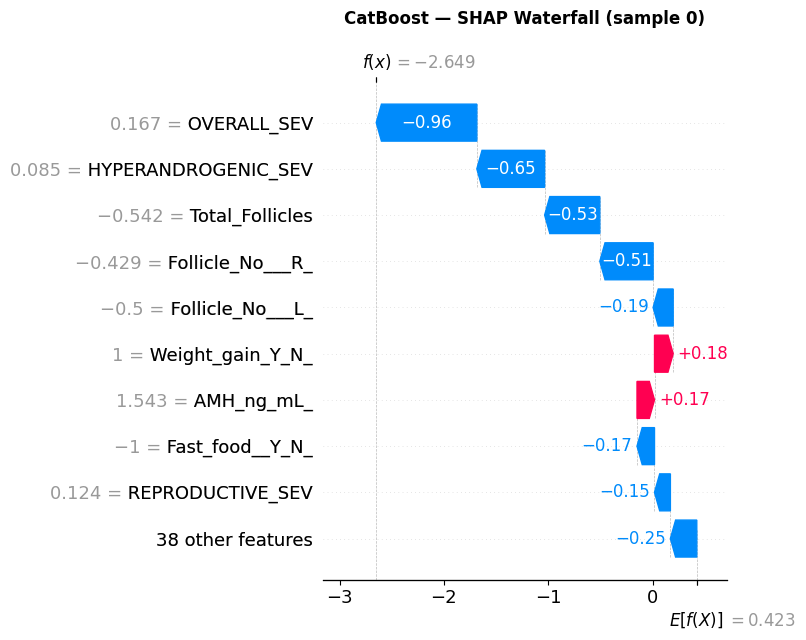

  Saved: CatBoost_waterfall.png


<Figure size 1600x300 with 0 Axes>

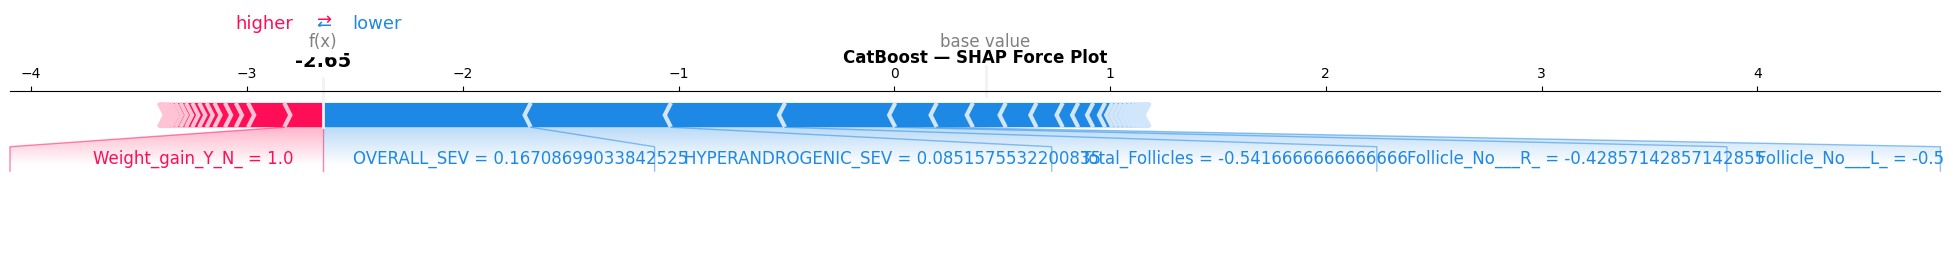

  Saved: CatBoost_force.png

  SHAP: Ensemble (meta-learner)


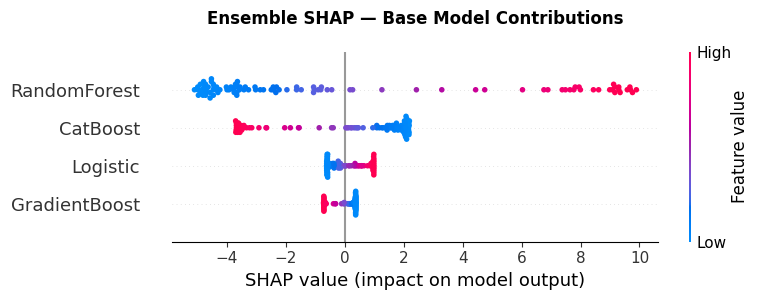

  Saved: Ensemble_beeswarm.png


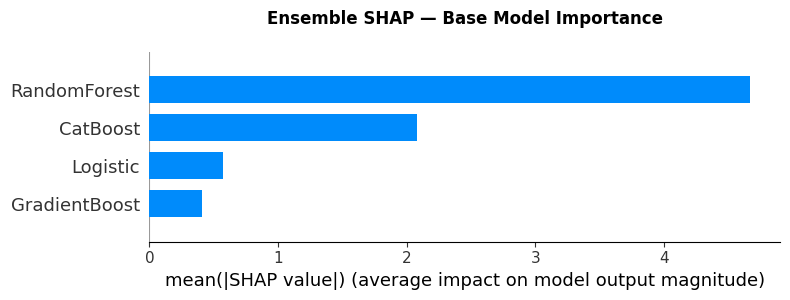

  Saved: Ensemble_bar.png


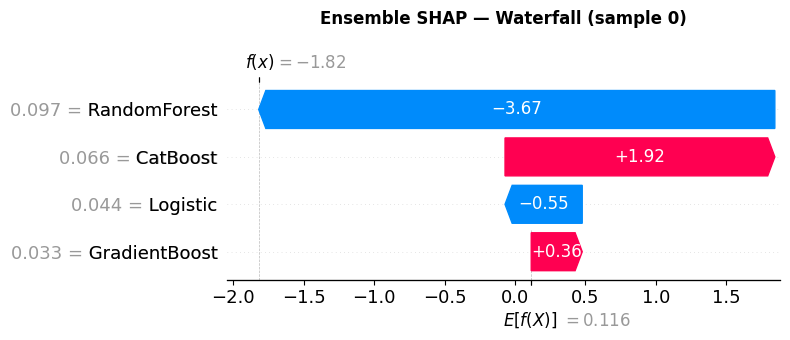

  Saved: Ensemble_waterfall.png

SHAP complete — all results saved: /content/PCOS_RESULTS_TABULAR2/shap
  NOTE: Severity columns (METABOLIC_SEV, REPRODUCTIVE_SEV, etc.) are
        included in base-model SHAP — showing how domain scores drive predictions.

BLOCK 13 — DEPLOYMENT ARTIFACTS
All artifacts saved & verified: /content/PCOS_RESULTS_TABULAR2/deployment
  ensemble_meta.pkl
  base_models.pkl
  domain_models.pkl
  mice_imputer.pkl
  scaler.pkl
  train_stats.pkl
  feature_columns.pkl
  best_threshold.pkl
  deployment_config.json


In [ ]:
# =============================================================================
# BLOCK 14 — MAIN  (data flow only — all visuals called outside)
# =============================================================================

def main():
    print("PCOS TABULAR CLASSIFICATION — FULL PIPELINE")

    # ── B4: Feature engineering ───────────────────────────────────────────────
    X, y, raw_df, FG = load_and_engineer()

    Xtr, Xte, ytr, yte, raw_tr, raw_te = train_test_split(
        X, y, raw_df,
        test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    print(f"Train: {len(Xtr)}  Test: {len(Xte)}")

    # ── B5: Impute + Scale ────────────────────────────────────────────────────
    Xtr_sc, Xte_sc, mice, scaler, num_cols = preprocess(Xtr, Xte)

    # ── B6: Domain severity ───────────────────────────────────────────────────
    sev_tr, domain_models, stats = compute_oof_severity(Xtr, ytr, Xtr_sc, FG)
    sev_te = apply_severity(domain_models, stats, Xte, Xte_sc)

    Xtr_f = pd.concat([Xtr_sc, sev_tr], axis=1)
    Xte_f = pd.concat([Xte_sc, sev_te], axis=1)
    print(f"Final feature matrix: {Xtr_f.shape[1]} cols "
          f"(scaled + {sev_tr.shape[1]} severity cols)")

    # ── B7: Per-model training ────────────────────────────────────────────────
    print("\nBLOCK 7 — PER-MODEL TRAINING + EVALUATION")
    skf          = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_meta     = pd.DataFrame(index=Xtr_f.index)
    test_meta    = pd.DataFrame(index=Xte_f.index)
    cv_rows      = []
    test_rows    = []
    trained_base = {}
    base_out     = {}

    for name, model in get_base_models().items():
        trained_base[name] = train_eval_save(
            name, model, Xtr_f, Xte_f, ytr, yte,
            skf, cv_rows, test_rows, oof_meta, test_meta, base_out)
        pd.DataFrame(cv_rows).to_csv(METRICS_CV_PATH,    index=False)
        pd.DataFrame(test_rows).to_csv(METRICS_TEST_PATH, index=False)
        print(f"  Metrics CSVs updated after {name}")

    # ── B8: Stacked ensemble ──────────────────────────────────────────────────
    print("\nBLOCK 8 — STACKED ENSEMBLE")
    meta_model, ens_probs, ens_preds, best_t = train_ensemble(
        Xtr_f, Xte_f, ytr, yte,
        oof_meta, test_meta, cv_rows, test_rows, base_out)

    cv_df   = pd.DataFrame(cv_rows)
    test_df = pd.DataFrame(test_rows)
    cv_df.to_csv(METRICS_CV_PATH,     index=False)
    test_df.to_csv(METRICS_TEST_PATH, index=False)

    print_metrics_table("CV METRICS — ALL MODELS",   cv_df)
    print_metrics_table("TEST METRICS — ALL MODELS", test_df)

    # ── Final summary ─────────────────────────────────────────────────────────
    print("\nPIPELINE COMPLETE — FINAL SUMMARY")
    print_metrics_table("TEST METRICS — ALL MODELS", test_df)

    ens = test_df[test_df["Model"] == "Ensemble"].iloc[0]
    print(f"\nEnsemble (threshold={best_t:.4f}):")
    hdr = f"  {'Acc':>7} {'AUC':>7} {'Sen':>7} {'Spe':>7} {'F1':>7} {'MCC':>7} {'PR_AUC':>8} {'Brier':>7}"
    row = (f"  {ens['Accuracy']:>7.4f} {ens['ROC_AUC']:>7.4f} "
           f"{ens['Sensitivity']:>7.4f} {ens['Specificity']:>7.4f} "
           f"{ens['F1']:>7.4f} {ens['MCC']:>7.4f} {ens['PR_AUC']:>8.4f} "
           f"{ens['Brier']:>7.4f}")
    print(hdr); print(row)

    print(f"\nOutputs:")
    print(f"  Plots      : {PLOT_DIR}")
    print(f"  SHAP       : {SHAP_DIR}")
    print(f"  Deployment : {DEPLOY_DIR}")
    print(f"  Severity   : {SEVERITY_PATH}")
    print(f"  CV CSV     : {METRICS_CV_PATH}")
    print(f"  Test CSV   : {METRICS_TEST_PATH}")

    return (X, y, raw_df, FG, Xtr, Xte, ytr, yte, raw_tr, raw_te,
            Xtr_sc, Xte_sc, mice, scaler, num_cols,
            domain_models, stats, Xtr_f, Xte_f, oof_meta, test_meta,
            trained_base, base_out, meta_model, ens_probs, ens_preds,
            best_t, cv_df, test_df)


# =============================================================================
# ENTRY POINT — run all blocks in order
# Visuals and preprocessing are called OUTSIDE main() here.
# =============================================================================

if __name__ == "__main__":

    # B3: EDA on raw data
    df_raw = pd.read_excel(DATA_PATH)
    df_raw.columns = df_raw.columns.str.strip()
    run_eda(df_raw)

    # B4–B8 + summary tables
    results = main()
    (X, y, raw_df, FG, Xtr, Xte, ytr, yte, raw_tr, raw_te,
     Xtr_sc, Xte_sc, mice, scaler, num_cols,
     domain_models, stats, Xtr_f, Xte_f, oof_meta, test_meta,
     trained_base, base_out, meta_model, ens_probs, ens_preds,
     best_t, cv_df, test_df) = results

    # B9: Learning curves (outside main)
    plot_learning_curves(Xtr_sc, ytr, cv=CV_FOLDS)

    # B10: Calibration + comparison + DCA (outside main)
    print("\nBLOCK 10 — CALIBRATION + ALL-MODEL COMPARISON + DECISION CURVE")
    plot_calibration(yte.values, ens_probs)
    plot_all_model_comparison(base_out, test_df)
    plot_decision_curve(base_out, yte.values)

    # B11: Patient severity scores (outside main)
    # FIX: reset_index ensures Xtr/Xte concat has clean 0..N index
    X_all   = pd.concat([Xtr, Xte]).reset_index(drop=True)
    raw_all = pd.concat([raw_tr, raw_te]).reset_index(drop=True)
    patient_scores, sev_all = compute_patient_severity(
        X_all, raw_all, domain_models, stats, mice, scaler, num_cols)

    # B12: SHAP (outside main)
    run_shap(trained_base, meta_model, Xtr_f, Xte_f,
             oof_meta, test_meta, num_samples=100, instance_idx=0)

    # B13: Deployment artifacts (outside main)
    save_deployment(meta_model, trained_base, domain_models, stats,
                    mice, scaler, Xtr_f, best_t, test_df)

In [ ]:

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

# ── Paths ──────────────────────────────────────────────────────────────────
SEVERITY_CSV    = "/content/patient_severity_scores(1).csv"
INFERTILITY_CSV = "/content/PCOS_infertility.csv"
MAIN_XLSX       = "/content/PCOS_data_without_infertility.xlsx"
OUTPUT_DIR      = "/content/PCOS_INFERTILITY_RISK_V3"
PLOT_DIR        = f"{OUTPUT_DIR}/plots"
for d in [OUTPUT_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42

# ── Biomarker directions: +1 = higher value → higher infertility risk ──────
# -1 = higher value → lower infertility risk (protective)
BIOMARKER_DIRECTIONS = {
    "FSH(mIU/mL)"         :  1,   # high FSH = poor ovarian reserve
    "LH(mIU/mL)"          : -1,   # high LH alone = PCOS (complex), slight protective
    "FSH/LH"              :  1,   # high FSH/LH = poor reserve
    "AMH_ng_mL"           : -1,   # high AMH = good reserve
    "Follicle No. (L)"    : -1,   # more follicles = better
    "Follicle No. (R)"    : -1,
    "Endometrium (mm)"    : -1,   # thicker endometrium = better implantation
    "PRG(ng/mL)"          : -1,   # high progesterone = successful ovulation
    "Cycle(R/I)"          :  1,   # irregular cycle = higher risk
}

# Weights by clinical relevance to infertility
BIOMARKER_WEIGHTS = {
    "FSH(mIU/mL)"         : 0.18,
    "LH(mIU/mL)"          : 0.08,
    "FSH/LH"              : 0.15,
    "AMH_ng_mL"           : 0.22,   # strongest single biomarker
    "Follicle No. (L)"    : 0.10,
    "Follicle No. (R)"    : 0.10,
    "Endometrium (mm)"    : 0.08,
    "PRG(ng/mL)"          : 0.05,
    "Cycle(R/I)"          : 0.04,
}


# =============================================================================
# UTILITIES
# =============================================================================

def save_fig(name):
    """Save figure to PLOT_DIR then display inline in Colab.
    Rule: savefig() BEFORE show() — after show() the figure buffer is
    flushed in some backends and savefig would produce a blank file.
    Do NOT call plt.close() here — it kills the figure object before
    Colab's IPython display backend can capture and render it inline.
    Python's GC cleans up figures automatically after they go out of scope.
    """
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.show()

def section(title):
    print("\n" + "="*80)
    print(title)
    print("="*80)


In [ ]:
# =============================================================================
# BLOCK 1 — LOAD & MERGE
# =============================================================================

def load_and_merge():
    section("BLOCK 1 — LOAD & MERGE")

    sev = pd.read_csv(SEVERITY_CSV, index_col=0).reset_index(drop=True)
    sev.columns = sev.columns.str.strip()

    inf = pd.read_csv(INFERTILITY_CSV)
    inf.columns = inf.columns.str.strip()

    assert len(sev) == len(inf), "Row count mismatch between severity and infertility CSVs"

    # Detect beta-HCG columns
    hcg_i  = next((c for c in inf.columns if "beta" in c.lower() and "ii" not in c.lower()), None)
    hcg_ii = next((c for c in inf.columns if "beta" in c.lower() and "ii"     in c.lower()), None)
    amh_c  = next((c for c in inf.columns if "amh"  in c.lower()), None)

    df = sev.copy()
    df["I_beta_HCG"]  = pd.to_numeric(inf[hcg_i].values,  errors="coerce") if hcg_i  else np.nan
    df["II_beta_HCG"] = pd.to_numeric(inf[hcg_ii].values, errors="coerce") if hcg_ii else np.nan
    df["AMH_ng_mL"]   = pd.to_numeric(inf[amh_c].values,  errors="coerce") if amh_c  else np.nan

    # Load clinical biomarkers from main xlsx
    try:
        main = pd.read_excel(MAIN_XLSX)
        main.columns = main.columns.str.strip()
        want = list(BIOMARKER_DIRECTIONS.keys()) + ["FSH/LH", "BMI", "Age (yrs)", "Weight (Kg)"]
        for c in want:
            if c in main.columns and c not in df.columns:
                df[c] = pd.to_numeric(
                    main[c].astype(str).str.strip(), errors="coerce").values
    except Exception as e:
        print(f"  WARNING: could not load main xlsx: {e}")

    # Pregnancy labels — target for infertility is NOT confirmed pregnant
    df["beta_HCG_max"]       = df[["I_beta_HCG", "II_beta_HCG"]].max(axis=1)
    df["Confirmed_Pregnant"] = (df["beta_HCG_max"] >= 25).astype(int)
    df["Infertile"]          = (df["beta_HCG_max"] <  25).astype(int)  # target
    df["log_beta_HCG"]       = np.log10(df["beta_HCG_max"].clip(lower=0) + 1)

    print(f"  Shape            : {df.shape}")
    print(f"  Confirmed preg   : {df['Confirmed_Pregnant'].sum()} "
          f"({df['Confirmed_Pregnant'].mean()*100:.1f}%)")
    print(f"  Infertile (<25)  : {df['Infertile'].sum()} "
          f"({df['Infertile'].mean()*100:.1f}%)")
    print(f"  PCOS patients    : {(df['PCOS (Y/N)']==1).sum()}")
    return df



In [ ]:
# =============================================================================
# BLOCK 2 — CORRELATION AUDIT (understand the data before scoring)
# =============================================================================

def correlation_audit(df):
    section("BLOCK 2 — CORRELATION AUDIT")

    print("\n  Pearson r with Confirmed_Pregnant:")
    print(f"  {'Feature':<35} {'r':>7} {'p':>8} {'direction':>12}")

    results = []
    for feat in list(BIOMARKER_DIRECTIONS.keys()) + \
                ["OVERALL_SEVERITY", "REPRODUCTIVE_SEVERITY",
                 "METABOLIC_SEVERITY", "AMH_ng_mL"]:
        if feat not in df.columns:
            continue
        valid = df[[feat, "Confirmed_Pregnant"]].dropna()
        if len(valid) < 30:
            continue
        r, p = stats.pearsonr(valid[feat], valid["Confirmed_Pregnant"])
        direction = "→ pregnant" if r > 0 else "→ infertile"
        sig = "*" if p < 0.05 else ""
        print(f"  {feat:<35} {r:>7.3f} {p:>8.4f} {direction:>12} {sig}")
        results.append({"feature": feat, "r": r, "p": p})

    # Within PCOS only
    print("\n  Within PCOS patients only:")
    pcos = df[df["PCOS (Y/N)"] == 1]
    for feat in ["OVERALL_SEVERITY", "REPRODUCTIVE_SEVERITY", "AMH_ng_mL",
                 "FSH(mIU/mL)", "Follicle No. (L)"]:
        if feat not in pcos.columns:
            continue
        valid = pcos[[feat, "Confirmed_Pregnant"]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.pearsonr(valid[feat], valid["Confirmed_Pregnant"])
        print(f"  {feat:<35} r={r:>6.3f}  p={p:>7.4f}")

    return pd.DataFrame(results)


In [ ]:
# =============================================================================
# BLOCK 3 — BUILD INFERTILITY RISK SCORE FROM BIOMARKERS
# =============================================================================

def build_infertility_risk_score(df):
    section("BLOCK 3 — BUILD INFERTILITY RISK SCORE")

    print("""
  Logic:
  Each biomarker is normalised to [0,1] then oriented so that
  higher value always means higher infertility risk:
    - High FSH       → risk ↑  (already positive direction)
    - High AMH       → risk ↓  (inverted: 1 - normalised AMH)
    - More follicles → risk ↓  (inverted)
    - Irregular cycle→ risk ↑  (already positive direction)
  Final score = weighted sum of oriented normalised features.
  Score range: 0 (lowest risk) to 1 (highest risk).
    """)

    available = {f: w for f, w in BIOMARKER_WEIGHTS.items() if f in df.columns}
    print(f"  Biomarkers available: {len(available)} / {len(BIOMARKER_WEIGHTS)}")
    print(f"  Features used: {list(available.keys())}")

    # Impute missing values
    feat_cols = list(available.keys())
    X = df[feat_cols].copy()
    mice = IterativeImputer(max_iter=10, random_state=RANDOM_STATE)
    X_imp = pd.DataFrame(mice.fit_transform(X), columns=feat_cols, index=df.index)

    # Normalise each feature to [0,1]
    scaler = MinMaxScaler()
    X_norm = pd.DataFrame(scaler.fit_transform(X_imp), columns=feat_cols, index=df.index)

    # Orient: flip features where higher value = lower risk
    X_oriented = X_norm.copy()
    for feat in feat_cols:
        if BIOMARKER_DIRECTIONS.get(feat, 1) == -1:
            X_oriented[feat] = 1 - X_norm[feat]

    # Weighted sum
    total_weight = sum(available.values())
    score = pd.Series(0.0, index=df.index)
    for feat, w in available.items():
        score += (w / total_weight) * X_oriented[feat]

    df["Infertility_Risk_Score"] = score

    # ── Validation against Infertile (beta-HCG < 25) ──────────────────────────
    valid_mask = df["Infertile"].notna()
    auc   = roc_auc_score(df.loc[valid_mask, "Infertile"],
                           df.loc[valid_mask, "Infertility_Risk_Score"])
    brier = brier_score_loss(df.loc[valid_mask, "Infertile"],
                              df.loc[valid_mask, "Infertility_Risk_Score"])

    print(f"\n  AUC  (Infertility Risk Score vs Infertile) : {auc:.4f}")
    print(f"  Brier Score (lower = better)               : {brier:.4f}")

    if auc < 0.5:
        print("\n  NOTE: AUC < 0.5 → score is in inverted direction — flipping.")
        df["Infertility_Risk_Score"] = 1 - df["Infertility_Risk_Score"]
        auc   = roc_auc_score(df.loc[valid_mask, "Infertile"],
                               df.loc[valid_mask, "Infertility_Risk_Score"])
        brier = brier_score_loss(df.loc[valid_mask, "Infertile"],
                                  df.loc[valid_mask, "Infertility_Risk_Score"])
        print(f"  AUC after flip : {auc:.4f}")

    # ── Percentile-based tiers (guarantees spread) ────────────────────────────
    p33 = df["Infertility_Risk_Score"].quantile(0.33)
    p66 = df["Infertility_Risk_Score"].quantile(0.66)
    df["Infertility_Risk_Tier"] = pd.cut(
        df["Infertility_Risk_Score"],
        bins=[-0.001, p33, p66, 1.001],
        labels=["Low", "Moderate", "High"])

    print(f"\n  Tier cutoffs (percentile-based):")
    print(f"    Low      : score ≤ {p33:.3f}")
    print(f"    Moderate : {p33:.3f} < score ≤ {p66:.3f}")
    print(f"    High     : score > {p66:.3f}")

    print(f"\n  Tier distribution:")
    print(df["Infertility_Risk_Tier"].value_counts().sort_index().to_string())

    print(f"\n  Infertility rate (beta-HCG < 25) by tier:")
    for tier in ["Low", "Moderate", "High"]:
        sub = df[df["Infertility_Risk_Tier"] == tier]
        rate = sub["Infertile"].mean() * 100
        n    = len(sub)
        print(f"    {tier:<10} (n={n:3d}): {rate:.1f}% infertile")

    # Also report pregnancy rate
    print(f"\n  Confirmed pregnancy rate by tier:")
    for tier in ["Low", "Moderate", "High"]:
        sub = df[df["Infertility_Risk_Tier"] == tier]
        rate = sub["Confirmed_Pregnant"].mean() * 100
        print(f"    {tier:<10} (n={len(sub):3d}): {rate:.1f}% confirmed pregnant")

    # Correlation with beta-HCG
    r, rp = stats.pearsonr(df["Infertility_Risk_Score"], df["log_beta_HCG"])
    print(f"\n  Pearson r (risk score vs log_beta_HCG): {r:.3f}, p={rp:.4f}")

    return df, auc, brier, p33, p66


In [ ]:
# =============================================================================
# BLOCK 4 — DOMAIN CONTRIBUTION TO INFERTILITY RISK
# =============================================================================

def domain_contribution_analysis(df):
    section("BLOCK 4 — DOMAIN CONTRIBUTIONS TO INFERTILITY RISK")

    domain_cols = {
        "METABOLIC"      : "METABOLIC_SEVERITY",
        "REPRODUCTIVE"   : "REPRODUCTIVE_SEVERITY",
        "HYPERANDROGENIC": "HYPERANDROGENIC_SEVERITY",
        "GENERAL"        : "GENERAL_SEVERITY",
    }
    domain_cols = {k: v for k, v in domain_cols.items() if v in df.columns}

    print(f"\n  {'Domain':<20} {'AUC vs Infertile':>18} {'r vs Risk Score':>17} {'Mean(Infertile)':>17} {'Mean(Pregnant)':>16}")
    domain_results = {}
    for domain, col in domain_cols.items():
        valid = df[[col, "Infertile", "Infertility_Risk_Score"]].dropna()
        try:
            auc_d = roc_auc_score(valid["Infertile"], valid[col])
            if auc_d < 0.5:
                auc_d = 1 - auc_d   # report directional AUC
        except Exception:
            auc_d = np.nan
        r_d, _ = stats.pearsonr(valid[col], valid["Infertility_Risk_Score"])
        m_inf  = df[df["Infertile"] == 1][col].mean()
        m_preg = df[df["Infertile"] == 0][col].mean()
        print(f"  {domain:<20} {auc_d:>18.4f} {r_d:>17.3f} {m_inf:>17.4f} {m_preg:>16.4f}")
        domain_results[domain] = {"auc": auc_d, "r": r_d,
                                   "mean_infertile": m_inf, "mean_pregnant": m_preg}

    return domain_results




In [ ]:

# =============================================================================
# BLOCK 5 — VISUALISATIONS  (12 figures)
# =============================================================================

def plot_all(df, domain_results, auc, brier, p33, p66):
    section("BLOCK 5 — VISUALISATIONS")

    target    = "Infertile"
    tiers     = ["Low", "Moderate", "High"]
    color_map = {"Low": "#2ecc71", "Moderate": "#f39c12", "High": "#e74c3c"}
    pcos      = df[df["PCOS (Y/N)"] == 1].copy()
    non_pcos  = df[df["PCOS (Y/N)"] == 0].copy()

    domain_sev_cols = [c for c in df.columns if c.endswith("_SEVERITY") and "OVERALL" not in c]
    bio_feats       = [f for f in list(BIOMARKER_DIRECTIONS.keys()) + ["AMH_ng_mL"]
                       if f in df.columns]

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 1 — EDA: class balance + beta-HCG distribution + PCOS vs Non-PCOS
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    labels = ["Pregnant\n(≥25)", "Infertile\n(<25)"]
    counts = [df["Confirmed_Pregnant"].sum(), df["Infertile"].sum()]
    bars = axes[0].bar(labels, counts, color=["#2ecc71", "#e74c3c"], alpha=0.85, edgecolor="white")
    total = len(df)
    for bar, cnt in zip(bars, counts):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     f"{cnt}\n({cnt/total*100:.1f}%)", ha="center", va="bottom",
                     fontsize=11, fontweight="bold")
    axes[0].set(title="Dataset: Pregnancy Label Distribution", ylabel="Count")
    axes[0].grid(alpha=0.3, axis="y")

    axes[1].hist(df["log_beta_HCG"], bins=40, color="steelblue", alpha=0.8, edgecolor="white")
    axes[1].axvline(np.log10(26), color="red", ls="--", lw=2, label="β-HCG=25 cutoff")
    axes[1].axvline(np.log10(6),  color="orange", ls="--", lw=1.5, label="β-HCG=5 cutoff")
    axes[1].set(title="log(β-HCG) Distribution (All Patients)",
                xlabel="log10(β-HCG + 1)", ylabel="Count")
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    pcos_inf_rate    = pcos["Infertile"].mean() * 100
    nonpcos_inf_rate = non_pcos["Infertile"].mean() * 100
    grp_bars = axes[2].bar(["PCOS", "Non-PCOS"],
                            [pcos_inf_rate, nonpcos_inf_rate],
                            color=["#e74c3c", "#3498db"], alpha=0.85, edgecolor="white")
    for bar, val, n in zip(grp_bars,
                            [pcos_inf_rate, nonpcos_inf_rate],
                            [len(pcos), len(non_pcos)]):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{val:.1f}%\n(n={n})", ha="center", va="bottom",
                     fontsize=11, fontweight="bold")
    axes[2].set(title="Infertility Rate: PCOS vs Non-PCOS",
                ylabel="Infertility Rate (%)")
    axes[2].set_ylim(0, max(pcos_inf_rate, nonpcos_inf_rate) * 1.3)
    axes[2].grid(alpha=0.3, axis="y")

    plt.suptitle("EDA — Dataset Overview", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("01_eda_overview")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 2 — Domain severity violin plots: Infertile vs Pregnant
    # ─────────────────────────────────────────────────────────────────────────
    if domain_sev_cols:
        fig, axes = plt.subplots(1, len(domain_sev_cols),
                                  figsize=(5 * len(domain_sev_cols), 5))
        if len(domain_sev_cols) == 1:
            axes = [axes]
        df["Outcome"] = df["Infertile"].map({0: "Pregnant", 1: "Infertile"})
        for ax, col in zip(axes, domain_sev_cols):
            sns.violinplot(x="Outcome", y=col, data=df,
                           palette={"Pregnant": "#2ecc71", "Infertile": "#e74c3c"},
                           inner="box", ax=ax)
            t_stat, p_val = stats.ttest_ind(
                df[df["Infertile"]==1][col].dropna(),
                df[df["Infertile"]==0][col].dropna())
            ax.set_title(col.replace("_SEVERITY", "").replace("_", " "),
                         fontsize=11, fontweight="bold")
            ax.set_xlabel(""); ax.set_ylabel("Severity Score")
            ax.text(0.5, 0.97, f"p={p_val:.4f}", transform=ax.transAxes,
                    ha="center", va="top", fontsize=9,
                    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
            ax.grid(alpha=0.3, axis="y")
        df.drop(columns=["Outcome"], inplace=True)
        plt.suptitle("Domain Severity: Infertile vs Pregnant (Violin)",
                     fontsize=14, fontweight="bold")
        plt.tight_layout(); save_fig("02_domain_severity_violin")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 3 — Infertility Risk Score: distribution + ROC + PR curve
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    inf_scores  = df[df[target] == 1]["Infertility_Risk_Score"]
    preg_scores = df[df[target] == 0]["Infertility_Risk_Score"]
    axes[0].hist(preg_scores, bins=25, alpha=0.7, color="green",  label="Pregnant")
    axes[0].hist(inf_scores,  bins=25, alpha=0.7, color="red",    label="Infertile")
    axes[0].axvline(p33, color="orange", ls="--", lw=1.5, label=f"Low/Mod ({p33:.2f})")
    axes[0].axvline(p66, color="red",    ls="--", lw=1.5, label=f"Mod/High ({p66:.2f})")
    axes[0].set(title="Risk Score Distribution", xlabel="Infertility Risk Score", ylabel="Count")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    fpr, tpr, _ = roc_curve(df[target], df["Infertility_Risk_Score"])
    axes[1].plot(fpr, tpr, lw=2.5, color="darkorange", label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
    axes[1].set(title="ROC Curve", xlabel="FPR (1 − Specificity)", ylabel="TPR (Sensitivity)")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    prec, rec, _ = precision_recall_curve(df[target], df["Infertility_Risk_Score"])
    ap = average_precision_score(df[target], df["Infertility_Risk_Score"])
    axes[2].plot(rec, prec, lw=2.5, color="steelblue", label=f"AP = {ap:.3f}")
    baseline = df[target].mean()
    axes[2].axhline(baseline, color="k", ls="--", alpha=0.4, label=f"Baseline ({baseline:.2f})")
    axes[2].set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle("Infertility Risk Score — Validation (ROC + PR)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("03_score_roc_pr")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 4 — Calibration + score KDE
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    try:
        fop, mpv = calibration_curve(df[target], df["Infertility_Risk_Score"],
                                      n_bins=8, strategy="quantile")
        axes[0].plot(mpv, fop, "s-", color="teal", lw=2, markersize=8, label="Risk score")
        axes[0].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
        axes[0].set(title=f"Calibration Curve (Brier = {brier:.3f})",
                    xlabel="Mean Predicted Risk", ylabel="Observed Infertility Rate")
        axes[0].legend(); axes[0].grid(alpha=0.3)
    except Exception as e:
        axes[0].text(0.5, 0.5, str(e), ha="center", va="center",
                     transform=axes[0].transAxes)

    for grp, col, lbl in [(df[df[target]==0], "green", "Pregnant"),
                           (df[df[target]==1], "red",   "Infertile")]:
        grp["Infertility_Risk_Score"].plot.kde(ax=axes[1], color=col,
                                                lw=2, label=lbl, alpha=0.8)
    axes[1].axvline(p33, color="orange", ls="--", lw=1.2)
    axes[1].axvline(p66, color="red",    ls="--", lw=1.2)
    axes[1].set(title="Risk Score KDE by Outcome",
                xlabel="Infertility Risk Score", ylabel="Density")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle("Calibration + Density", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("04_calibration_kde")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 5 — Tier analysis (infertility rate + pregnancy rate + boxplot)
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    infertile_rates = [df[df["Infertility_Risk_Tier"]==t]["Infertile"].mean()*100 for t in tiers]
    preg_rates      = [df[df["Infertility_Risk_Tier"]==t]["Confirmed_Pregnant"].mean()*100 for t in tiers]
    ns              = [len(df[df["Infertility_Risk_Tier"]==t]) for t in tiers]

    bars = axes[0].bar(tiers, infertile_rates,
                        color=[color_map[t] for t in tiers], alpha=0.85, edgecolor="white")
    for bar, val, n in zip(bars, infertile_rates, ns):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{val:.1f}%\n(n={n})", ha="center", va="bottom",
                     fontsize=10, fontweight="bold")
    axes[0].set(title="Infertility Rate by Risk Tier",
                ylabel="Infertility Rate (%)")
    axes[0].set_ylim(0, max(infertile_rates) * 1.3)
    axes[0].grid(alpha=0.3, axis="y")

    bars2 = axes[1].bar(tiers, preg_rates,
                         color=[color_map[t] for t in tiers], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars2, preg_rates):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{val:.1f}%", ha="center", va="bottom",
                     fontsize=10, fontweight="bold")
    axes[1].set(title="Confirmed Pregnancy Rate by Risk Tier",
                ylabel="Pregnancy Rate (%)")
    axes[1].set_ylim(0, max(preg_rates) * 1.3)
    axes[1].grid(alpha=0.3, axis="y")

    score_by_tier = [df[df["Infertility_Risk_Tier"]==t]["Infertility_Risk_Score"] for t in tiers]
    bp = axes[2].boxplot(score_by_tier, labels=tiers, patch_artist=True)
    for box, tier in zip(bp["boxes"], tiers):
        box.set_facecolor(color_map[tier]); box.set_alpha(0.7)
    axes[2].set(title="Risk Score Distribution by Tier", ylabel="Infertility Risk Score")
    axes[2].grid(alpha=0.3, axis="y")

    plt.suptitle("Infertility Risk Tiers", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("05_tier_analysis")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 6 — Domain contributions (AUC bars + mean-diff bars)
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    domains   = list(domain_results.keys())
    auc_vals  = [domain_results[d]["auc"]  for d in domains]
    diff_vals = [domain_results[d]["mean_infertile"] - domain_results[d]["mean_pregnant"]
                 for d in domains]
    clr = ["#e74c3c" if v >= 0 else "#3498db" for v in diff_vals]

    axes[0].barh(domains, auc_vals, color="#3498db", alpha=0.8)
    axes[0].axvline(0.5, color="k", ls="--", alpha=0.5, label="Random (0.5)")
    for i, v in enumerate(auc_vals):
        axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
    axes[0].set(title="Domain AUC vs Infertility Target",
                xlabel="AUC", xlim=(0.45, 0.65))
    axes[0].legend(); axes[0].grid(alpha=0.3, axis="x")

    axes[1].barh(domains, diff_vals, color=clr, alpha=0.8)
    axes[1].axvline(0, color="k", ls="-", alpha=0.5)
    for i, v in enumerate(diff_vals):
        axes[1].text(v + 0.001 if v >= 0 else v - 0.001, i,
                     f"{v:+.3f}", va="center",
                     ha="left" if v >= 0 else "right", fontsize=9)
    axes[1].set(title="Domain Severity: Infertile − Pregnant Mean",
                xlabel="Difference (positive = higher in infertile)")
    axes[1].grid(alpha=0.3, axis="x")

    plt.suptitle("Domain Contributions to Infertility Risk", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("06_domain_contributions")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 7 — Biomarker boxplots by tier (all available)
    # ─────────────────────────────────────────────────────────────────────────
    if bio_feats:
        ncols = 4
        nrows = int(np.ceil(len(bio_feats) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
        axes = np.array(axes).ravel()
        for i, feat in enumerate(bio_feats):
            data_by_tier = [df[df["Infertility_Risk_Tier"]==t][feat].dropna() for t in tiers]
            bp = axes[i].boxplot(data_by_tier, labels=tiers, patch_artist=True)
            for box, tier in zip(bp["boxes"], tiers):
                box.set_facecolor(color_map[tier]); box.set_alpha(0.7)
            axes[i].set_title(feat.replace("(mIU/mL)", "").replace("(ng/mL)", "")
                               .replace("(mm)", "").strip(), fontsize=9, fontweight="bold")
            axes[i].grid(alpha=0.3, axis="y")
        for j in range(len(bio_feats), len(axes)):
            axes[j].axis("off")
        plt.suptitle("Biomarker Values by Infertility Risk Tier",
                     fontsize=14, fontweight="bold")
        plt.tight_layout(); save_fig("07_biomarkers_by_tier")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 8 — Correlation heatmap of biomarkers + severity + risk score
    # ─────────────────────────────────────────────────────────────────────────
    corr_feats = [f for f in bio_feats + domain_sev_cols +
                  ["OVERALL_SEVERITY", "Infertility_Risk_Score",
                   "Infertile", "log_beta_HCG"]
                  if f in df.columns]
    corr_df = df[corr_feats].corr()
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.3,
                ax=ax, cbar_kws={"shrink": 0.8})
    short_labels = [c.replace("(mIU/mL)", "").replace("(ng/mL)", "")
                     .replace("(mm)", "").replace("_SEVERITY", "").strip()
                     for c in corr_feats]
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(short_labels, rotation=0, fontsize=9)
    plt.suptitle("Correlation Heatmap — Biomarkers + Severity + Risk Score",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("08_correlation_heatmap")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 9 — Severity vs risk score + score vs log-HCG scatter
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sc = axes[0].scatter(df["OVERALL_SEVERITY"], df["Infertility_Risk_Score"],
                          c=df["Infertile"], cmap="RdYlGn_r", alpha=0.4, s=25)
    plt.colorbar(sc, ax=axes[0], label="Infertile (1=yes)")
    r2, p2 = stats.pearsonr(df["OVERALL_SEVERITY"], df["Infertility_Risk_Score"])
    axes[0].set(title=f"PCOS Severity vs Infertility Risk Score\n(r={r2:.3f}, p={p2:.4f})",
                xlabel="PCOS Overall Severity", ylabel="Infertility Risk Score")
    axes[0].grid(alpha=0.3)

    sc2 = axes[1].scatter(df["Infertility_Risk_Score"], df["log_beta_HCG"],
                           c=df["Infertile"], cmap="RdYlGn_r", alpha=0.4, s=25)
    plt.colorbar(sc2, ax=axes[1], label="Infertile (1=yes)")
    r3, p3 = stats.pearsonr(df["Infertility_Risk_Score"], df["log_beta_HCG"])
    axes[1].set(title=f"Infertility Risk Score vs log(β-HCG)\n(r={r3:.3f}, p={p3:.4f})",
                xlabel="Infertility Risk Score", ylabel="log10(β-HCG + 1)")
    axes[1].grid(alpha=0.3)

    plt.suptitle("Severity → Risk Score → Fertility Outcome",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("09_severity_risk_mapping")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 10 — PCOS subgroup deep dive
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    pcos_tier_infertile = pcos.groupby("Infertility_Risk_Tier",
                                        observed=True)["Infertile"].mean() * 100
    bars3 = axes[0].bar(pcos_tier_infertile.index, pcos_tier_infertile.values,
                         color=[color_map[t] for t in pcos_tier_infertile.index],
                         alpha=0.85, edgecolor="white")
    for bar, val, tier in zip(bars3, pcos_tier_infertile.values,
                               pcos_tier_infertile.index):
        n = len(pcos[pcos["Infertility_Risk_Tier"] == tier])
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{val:.1f}%\n(n={n})", ha="center", va="bottom",
                     fontsize=10, fontweight="bold")
    axes[0].set(title="PCOS Only: Infertility Rate by Risk Tier",
                ylabel="Infertility Rate (%)")
    axes[0].grid(alpha=0.3, axis="y")

    pcos_inf_s  = pcos[pcos["Infertile"] == 1]["Infertility_Risk_Score"]
    pcos_preg_s = pcos[pcos["Infertile"] == 0]["Infertility_Risk_Score"]
    axes[1].hist([pcos_preg_s, pcos_inf_s], bins=20, alpha=0.7, color=["green", "red"])
    axes[1].set(title="PCOS Only: Risk Score Distribution",
                xlabel="Infertility Risk Score", ylabel="Count")
    axes[1].legend(["Pregnant", "Infertile"]); axes[1].grid(alpha=0.3)

    if len(pcos_inf_s) > 5 and len(pcos_preg_s) > 5:
        try:
            pcos_auc = roc_auc_score(pcos["Infertile"], pcos["Infertility_Risk_Score"])
            fpr_p, tpr_p, _ = roc_curve(pcos["Infertile"], pcos["Infertility_Risk_Score"])
            axes[2].plot(fpr_p, tpr_p, lw=2.5, color="darkorange",
                         label=f"PCOS only AUC = {pcos_auc:.3f}")
            axes[2].plot([0, 1], [0, 1], "k--", alpha=0.4)
            axes[2].set(title="PCOS Only: ROC Curve", xlabel="FPR", ylabel="TPR")
            axes[2].legend(); axes[2].grid(alpha=0.3)
        except Exception as e:
            axes[2].text(0.5, 0.5, str(e), ha="center", va="center",
                         transform=axes[2].transAxes)

    plt.suptitle("PCOS Subgroup Infertility Risk Analysis",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("10_pcos_subgroup")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 11 — Patient-level risk score strip / swarm chart
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_df = df[["Infertility_Risk_Score", "Infertility_Risk_Tier",
                  "Infertile", "PCOS (Y/N)"]].copy()
    plot_df["Outcome"] = plot_df["Infertile"].map({0: "Pregnant", 1: "Infertile"})

    sns.stripplot(x="Infertility_Risk_Tier", y="Infertility_Risk_Score",
                  hue="Outcome", data=plot_df,
                  palette={"Pregnant": "#2ecc71", "Infertile": "#e74c3c"},
                  order=tiers, alpha=0.4, jitter=True, size=4, ax=axes[0])
    axes[0].axhline(p33, color="orange", ls="--", lw=1.2, alpha=0.7)
    axes[0].axhline(p66, color="red",    ls="--", lw=1.2, alpha=0.7)
    axes[0].set(title="Patient-Level Risk Score Strip Chart",
                xlabel="Infertility Risk Tier", ylabel="Infertility Risk Score")
    axes[0].legend(title="Outcome", fontsize=9); axes[0].grid(alpha=0.3, axis="y")

    sns.stripplot(x="Infertility_Risk_Tier", y="Infertility_Risk_Score",
                  hue="PCOS (Y/N)", data=plot_df,
                  palette={0: "#3498db", 1: "#e74c3c"},
                  order=tiers, alpha=0.4, jitter=True, size=4, ax=axes[1])
    axes[1].set(title="Risk Score by Tier — PCOS vs Non-PCOS",
                xlabel="Infertility Risk Tier", ylabel="Infertility Risk Score")
    handles, _ = axes[1].get_legend_handles_labels()
    axes[1].legend(handles, ["Non-PCOS", "PCOS"], title="Group", fontsize=9)
    axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle("Patient-Level Risk Score Distribution",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("11_patient_strip_chart")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 12 — Domain severity heatmap by tier + PCOS vs Non-PCOS severity
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    if domain_sev_cols:
        heat = df.groupby("Infertility_Risk_Tier",
                           observed=True)[domain_sev_cols].mean()
        heat.index = [str(i) for i in heat.index]
        heat.columns = [c.replace("_SEVERITY", "") for c in heat.columns]
        sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn_r",
                    ax=axes[0], cbar=True, linewidths=0.3)
        axes[0].set(title="Mean Domain Severity by Risk Tier")
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

    # PCOS vs Non-PCOS domain severity comparison
    all_sev = domain_sev_cols + (["OVERALL_SEVERITY"] if "OVERALL_SEVERITY" in df.columns else [])
    pcos_means    = df[df["PCOS (Y/N)"]==1][all_sev].mean()
    nonpcos_means = df[df["PCOS (Y/N)"]==0][all_sev].mean()
    x = np.arange(len(all_sev)); w = 0.35
    axes[1].bar(x - w/2, pcos_means.values,    w, label="PCOS",    color="#e74c3c", alpha=0.8)
    axes[1].bar(x + w/2, nonpcos_means.values, w, label="Non-PCOS",color="#3498db", alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([c.replace("_SEVERITY", "") for c in all_sev],
                             rotation=30, ha="right", fontsize=9)
    axes[1].set(title="Domain Severity: PCOS vs Non-PCOS",
                ylabel="Mean Severity Score")
    axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle("Domain Severity Patterns", fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("12_domain_heatmap_pcos_comparison")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 13 — Domain Risk vs Infertility  ← KEY NEW CHART
    # For each domain: scatter severity vs infertility label, with regression
    # line + marginal infertility rate binned by severity decile
    # ─────────────────────────────────────────────────────────────────────────
    if domain_sev_cols:
        nd = len(domain_sev_cols)
        fig, axes = plt.subplots(2, nd, figsize=(5 * nd, 10))
        if nd == 1:
            axes = axes.reshape(2, 1)

        for col_idx, col in enumerate(domain_sev_cols):
            domain_name = col.replace("_SEVERITY", "")

            # Row 0: binned infertility rate by severity decile
            ax_top = axes[0, col_idx]
            valid  = df[[col, "Infertile"]].dropna()
            valid  = valid.copy()
            valid["decile"] = pd.qcut(valid[col], q=8, duplicates="drop")
            binned = valid.groupby("decile", observed=True).agg(
                inf_rate  = ("Infertile", "mean"),
                mid_sev   = (col, "mean"),
                n         = (col, "count"),
            ).reset_index()
            bar_colors = [color_map["High"] if r > 0.5
                          else color_map["Moderate"] if r > 0.4
                          else color_map["Low"]
                          for r in binned["inf_rate"]]
            bars_d = ax_top.bar(range(len(binned)),
                                binned["inf_rate"] * 100,
                                color=bar_colors, alpha=0.85, edgecolor="white")
            for i, (bar, row) in enumerate(zip(bars_d, binned.itertuples())):
                ax_top.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + 0.5,
                            f"{row.inf_rate*100:.0f}%",
                            ha="center", va="bottom", fontsize=8)
            ax_top.axhline(df["Infertile"].mean() * 100,
                           color="black", ls="--", lw=1.5, alpha=0.6,
                           label=f"Overall avg ({df['Infertile'].mean()*100:.1f}%)")
            ax_top.set_xticks(range(len(binned)))
            ax_top.set_xticklabels([f"{row.mid_sev:.2f}" for row in binned.itertuples()],
                                    rotation=45, ha="right", fontsize=8)
            ax_top.set(title=f"{domain_name}: Infertility Rate by Severity Bin",
                       xlabel="Mean Severity in Bin", ylabel="Infertility Rate (%)")
            ax_top.set_ylim(0, 100)
            ax_top.legend(fontsize=8); ax_top.grid(alpha=0.3, axis="y")

            # Row 1: violin/swarm of domain severity split by infertile vs pregnant
            ax_bot = axes[1, col_idx]
            df["_out"] = df["Infertile"].map({0: "Pregnant", 1: "Infertile"})
            sns.violinplot(x="_out", y=col, data=df,
                           palette={"Pregnant": "#2ecc71", "Infertile": "#e74c3c"},
                           inner="quartile", ax=ax_bot, alpha=0.8)
            # Overlay means
            for xi, grp_val in enumerate([0, 1]):
                m = df[df["Infertile"] == grp_val][col].mean()
                ax_bot.scatter(xi, m, color="black", zorder=5, s=60, marker="D")
                ax_bot.text(xi, m + 0.01, f"μ={m:.3f}", ha="center",
                            va="bottom", fontsize=8, fontweight="bold")
            t_v, p_v = stats.ttest_ind(
                df[df["Infertile"]==1][col].dropna(),
                df[df["Infertile"]==0][col].dropna())
            ax_bot.set_title(f"{domain_name}: Severity Distribution\n"
                             f"(t={t_v:.2f}, p={p_v:.4f})",
                             fontsize=10, fontweight="bold")
            ax_bot.set_xlabel(""); ax_bot.set_ylabel("Severity Score")
            ax_bot.grid(alpha=0.3, axis="y")
            df.drop(columns=["_out"], inplace=True)

        plt.suptitle("Domain Severity vs Infertility Risk — Detailed",
                     fontsize=14, fontweight="bold")
        plt.tight_layout(); save_fig("13_domain_risk_vs_infertility")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 14 — Infertility Risk Score dose-response vs beta-HCG
    # Binned risk score → mean beta-HCG + infertility rate overlay
    # ─────────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Bin risk score into 10 equal-frequency bins
    df["_risk_bin"] = pd.qcut(df["Infertility_Risk_Score"], q=10, duplicates="drop")
    binned_r = df.groupby("_risk_bin", observed=True).agg(
        mean_hcg      = ("beta_HCG_max",          "mean"),
        median_hcg    = ("beta_HCG_max",          "median"),
        inf_rate      = ("Infertile",              "mean"),
        preg_rate     = ("Confirmed_Pregnant",     "mean"),
        mean_score    = ("Infertility_Risk_Score", "mean"),
        n             = ("Infertility_Risk_Score", "count"),
    ).reset_index()
    df.drop(columns=["_risk_bin"], inplace=True)

    x_pts = range(len(binned_r))
    ax2 = axes[0].twinx()
    bars_r = axes[0].bar(x_pts, binned_r["mean_hcg"],
                          color="#3498db", alpha=0.6, label="Mean β-HCG")
    ax2.plot(x_pts, binned_r["inf_rate"] * 100,
             "ro-", lw=2, ms=6, label="Infertility rate %")
    axes[0].set_xticks(x_pts)
    axes[0].set_xticklabels([f"{r:.2f}" for r in binned_r["mean_score"]],
                             rotation=45, ha="right", fontsize=8)
    axes[0].set(title="Risk Score Decile: β-HCG + Infertility Rate",
                xlabel="Mean Risk Score in Bin", ylabel="Mean β-HCG (mIU/mL)")
    ax2.set_ylabel("Infertility Rate (%)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    lines1, lbl1 = axes[0].get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    axes[0].legend(lines1 + lines2, lbl1 + lbl2, fontsize=8)
    axes[0].grid(alpha=0.3, axis="y")

    # Cumulative: as risk increases, cumulative infertility burden
    cum_inf = (binned_r["inf_rate"] * binned_r["n"]).cumsum() / binned_r["n"].cumsum() * 100
    axes[1].plot(x_pts, cum_inf, "s-", color="#e74c3c", lw=2, ms=7)
    axes[1].axhline(df["Infertile"].mean() * 100, color="k", ls="--",
                    alpha=0.5, label="Overall rate")
    axes[1].set_xticks(x_pts)
    axes[1].set_xticklabels([f"{r:.2f}" for r in binned_r["mean_score"]],
                             rotation=45, ha="right", fontsize=8)
    axes[1].set(title="Cumulative Infertility Rate by Risk Score",
                xlabel="Risk Score Decile (mean)", ylabel="Cumulative Infertility Rate (%)")
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    # Scatter: individual risk score vs log beta-HCG, coloured by tier
    tier_palette = {"Low": "#2ecc71", "Moderate": "#f39c12", "High": "#e74c3c"}
    for tier in tiers:
        sub = df[df["Infertility_Risk_Tier"] == tier]
        axes[2].scatter(sub["Infertility_Risk_Score"], sub["log_beta_HCG"],
                        c=tier_palette[tier], alpha=0.4, s=20, label=tier)
    # Regression line
    valid_sc = df[["Infertility_Risk_Score", "log_beta_HCG"]].dropna()
    m_s, b_s = np.polyfit(valid_sc["Infertility_Risk_Score"], valid_sc["log_beta_HCG"], 1)
    xl = np.linspace(df["Infertility_Risk_Score"].min(),
                      df["Infertility_Risk_Score"].max(), 100)
    axes[2].plot(xl, m_s * xl + b_s, "k-", lw=2, alpha=0.7, label="Regression")
    r_sc, p_sc = stats.pearsonr(valid_sc["Infertility_Risk_Score"],
                                 valid_sc["log_beta_HCG"])
    axes[2].set(title=f"Risk Score vs log(β-HCG) by Tier\n(r={r_sc:.3f}, p={p_sc:.4f})",
                xlabel="Infertility Risk Score", ylabel="log10(β-HCG + 1)")
    axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

    plt.suptitle("Infertility Risk Score Dose-Response Analysis",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); save_fig("14_risk_score_dose_response")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 15 — AMH stratification vs infertility risk
    # AMH is the strongest single biomarker (r=0.099*) — deep dive
    # ─────────────────────────────────────────────────────────────────────────
    if "AMH_ng_mL" in df.columns:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        amh_valid = df[["AMH_ng_mL", "Infertile", "Confirmed_Pregnant",
                         "Infertility_Risk_Score", "PCOS (Y/N)",
                         "Infertility_Risk_Tier"]].dropna(subset=["AMH_ng_mL"])

        # AMH tertiles
        amh_valid = amh_valid.copy()
        amh_valid["AMH_Tertile"] = pd.qcut(
            amh_valid["AMH_ng_mL"], q=3,
            labels=["Low AMH\n(Poor Reserve)",
                    "Mid AMH\n(Moderate Reserve)",
                    "High AMH\n(Good Reserve)"])

        # Infertility rate by AMH tertile
        amh_inf = amh_valid.groupby("AMH_Tertile", observed=True).agg(
            inf_rate  = ("Infertile", "mean"),
            preg_rate = ("Confirmed_Pregnant", "mean"),
            n         = ("AMH_ng_mL", "count"),
            mean_amh  = ("AMH_ng_mL", "mean"),
        ).reset_index()

        amh_colors = ["#e74c3c", "#f39c12", "#2ecc71"]
        bars_a = axes[0].bar(amh_inf["AMH_Tertile"],
                              amh_inf["inf_rate"] * 100,
                              color=amh_colors, alpha=0.85, edgecolor="white")
        for bar, row in zip(bars_a, amh_inf.itertuples()):
            axes[0].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.5,
                         f"{row.inf_rate*100:.1f}%\n(n={row.n})",
                         ha="center", va="bottom", fontsize=10, fontweight="bold")
        axes[0].set(title="Infertility Rate by AMH Tertile",
                    ylabel="Infertility Rate (%)")
        axes[0].set_ylim(0, 100); axes[0].grid(alpha=0.3, axis="y")
        # Chi-square test
        ct = pd.crosstab(amh_valid["AMH_Tertile"], amh_valid["Infertile"])
        chi2_v, chi2_p, _, _ = stats.chi2_contingency(ct)
        axes[0].text(0.5, 0.97, f"χ²={chi2_v:.2f}, p={chi2_p:.4f}",
                     transform=axes[0].transAxes, ha="center", va="top",
                     fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

        # AMH vs Infertility Risk Score — scatter with regression
        sc_amh = axes[1].scatter(amh_valid["AMH_ng_mL"],
                                  amh_valid["Infertility_Risk_Score"],
                                  c=amh_valid["Infertile"],
                                  cmap="RdYlGn_r", alpha=0.5, s=25)
        plt.colorbar(sc_amh, ax=axes[1], label="Infertile (1=yes)")
        m_a, b_a = np.polyfit(amh_valid["AMH_ng_mL"],
                               amh_valid["Infertility_Risk_Score"], 1)
        xl_a = np.linspace(amh_valid["AMH_ng_mL"].min(),
                            amh_valid["AMH_ng_mL"].max(), 100)
        axes[1].plot(xl_a, m_a * xl_a + b_a, "k-", lw=2, alpha=0.7)
        r_a, p_a = stats.pearsonr(amh_valid["AMH_ng_mL"],
                                   amh_valid["Infertility_Risk_Score"])
        axes[1].set(title=f"AMH vs Infertility Risk Score\n(r={r_a:.3f}, p={p_a:.4f})",
                    xlabel="AMH (ng/mL)", ylabel="Infertility Risk Score")
        axes[1].grid(alpha=0.3)

        # Mean infertility risk score by AMH tertile + PCOS status
        amh_tier_pcos = amh_valid.groupby(
            ["AMH_Tertile", "PCOS (Y/N)"], observed=True
        )["Infertility_Risk_Score"].mean().unstack()
        amh_tier_pcos.columns = ["Non-PCOS", "PCOS"]
        amh_tier_pcos.plot(kind="bar", ax=axes[2], color=["#3498db", "#e74c3c"],
                            alpha=0.8, edgecolor="white")
        axes[2].set(title="Mean Infertility Risk Score\nby AMH Tertile × PCOS Status",
                    xlabel="AMH Tertile", ylabel="Mean Risk Score")
        axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha="right")
        axes[2].legend(title="Group"); axes[2].grid(alpha=0.3, axis="y")

        plt.suptitle("AMH Stratification vs Infertility Risk",
                     fontsize=14, fontweight="bold")
        plt.tight_layout(); save_fig("15_amh_stratification")

    # ─────────────────────────────────────────────────────────────────────────
    # Fig 16 — Comprehensive patient risk profile (radar + summary)
    # Mean biomarker profile for each risk tier — radar chart
    # ─────────────────────────────────────────────────────────────────────────
    radar_feats = [f for f in ["FSH(mIU/mL)", "AMH_ng_mL",
                                "Follicle No. (L)", "Endometrium (mm)",
                                "PRG(ng/mL)", "LH(mIU/mL)"]
                   if f in df.columns]
    if len(radar_feats) >= 4:
        fig = plt.figure(figsize=(18, 6))

        # Normalise radar features to [0,1] for display
        from sklearn.preprocessing import MinMaxScaler as _MMS
        _sc  = _MMS()
        radar_norm = pd.DataFrame(
            _sc.fit_transform(df[radar_feats].fillna(df[radar_feats].median())),
            columns=radar_feats, index=df.index)
        radar_norm["tier"] = df["Infertility_Risk_Tier"].values

        # Radar axes setup
        N       = len(radar_feats)
        angles  = [n / float(N) * 2 * np.pi for n in range(N)]
        angles += angles[:1]
        short_labels = [f.replace("(mIU/mL)", "").replace("(ng/mL)", "")
                         .replace("(mm)", "").replace("No. (L)", "No.")
                         .replace("_ng_mL", "").strip() for f in radar_feats]

        radar_colors = {"Low": "#2ecc71", "Moderate": "#f39c12", "High": "#e74c3c"}
        ax_radar = fig.add_subplot(131, polar=True)

        for tier in tiers:
            vals = radar_norm[radar_norm["tier"] == tier][radar_feats].mean().tolist()
            vals += vals[:1]
            ax_radar.plot(angles, vals, "o-", lw=2,
                          color=radar_colors[tier], label=tier)
            ax_radar.fill(angles, vals, alpha=0.08, color=radar_colors[tier])

        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(short_labels, fontsize=9)
        ax_radar.set_ylim(0, 1)
        ax_radar.set_title("Biomarker Profile by Risk Tier\n(normalised)",
                            fontsize=11, fontweight="bold", pad=20)
        ax_radar.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
        ax_radar.grid(alpha=0.4)

        # Summary table — key stats per tier
        ax_tbl = fig.add_subplot(132)
        ax_tbl.axis("off")
        tier_stats = df.groupby("Infertility_Risk_Tier", observed=True).agg(
            n              = ("Infertile", "count"),
            inf_pct        = ("Infertile", lambda x: f"{x.mean()*100:.1f}%"),
            preg_pct       = ("Confirmed_Pregnant", lambda x: f"{x.mean()*100:.1f}%"),
            mean_score     = ("Infertility_Risk_Score", lambda x: f"{x.mean():.3f}"),
            mean_hcg       = ("beta_HCG_max", lambda x: f"{x.mean():.0f}"),
        )
        col_labels = ["n", "Infertile %", "Pregnant %", "Risk Score", "Mean β-HCG"]
        tbl_data   = [[str(tier_stats.loc[t, c]) for c in tier_stats.columns]
                       for t in tiers if t in tier_stats.index]
        tbl = ax_tbl.table(
            cellText=tbl_data,
            rowLabels=tiers,
            colLabels=col_labels,
            cellLoc="center", loc="center",
            rowColours=[radar_colors[t] + "55" for t in tiers],
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1.2, 2.0)
        ax_tbl.set_title("Risk Tier Summary Table",
                          fontsize=11, fontweight="bold", pad=10)

        # Waterfall: infertility rate change from Low → High
        ax_wf = fig.add_subplot(133)
        tier_rates = [df[df["Infertility_Risk_Tier"] == t]["Infertile"].mean() * 100
                      for t in tiers]
        base = tier_rates[0]
        deltas = [tier_rates[0]] + [tier_rates[i] - tier_rates[i-1]
                                     for i in range(1, len(tiers))]
        bottoms = [0, tier_rates[0], tier_rates[1]]
        wf_colors = [color_map["Low"], "#e67e22", color_map["High"]]
        wf_labels = [f"Low: {tier_rates[0]:.1f}%",
                     f"+{deltas[1]:.1f}pp (Mod)",
                     f"+{deltas[2]:.1f}pp (High)"]
        bars_wf = ax_wf.bar([0, 1, 2], deltas, bottom=[0, tier_rates[0], tier_rates[1]],
                             color=wf_colors, alpha=0.85, edgecolor="white", width=0.5)
        for bar, val, lbl in zip(bars_wf, deltas, wf_labels):
            ax_wf.text(bar.get_x() + bar.get_width()/2,
                       bar.get_y() + bar.get_height() / 2,
                       lbl, ha="center", va="center",
                       fontsize=9, fontweight="bold", color="white")
        ax_wf.axhline(df["Infertile"].mean() * 100, color="k",
                       ls="--", lw=1.5, alpha=0.6, label="Overall avg")
        ax_wf.set_xticks([0, 1, 2])
        ax_wf.set_xticklabels(["Low", "Moderate", "High"])
        ax_wf.set(title="Infertility Rate Waterfall\n(cumulative by tier)",
                  ylabel="Infertility Rate (%)")
        ax_wf.legend(fontsize=9); ax_wf.grid(alpha=0.3, axis="y")

        plt.suptitle("Comprehensive Patient Risk Profile",
                     fontsize=14, fontweight="bold")
        plt.tight_layout(); save_fig("16_patient_risk_profile")



In [ ]:

# =============================================================================
# BLOCK 6 — SAVE OUTPUTS
# =============================================================================

def save_outputs(df, domain_results, auc, brier):
    section("BLOCK 6 — SAVE OUTPUTS")

    domain_sev_cols = [c for c in df.columns if c.endswith("_SEVERITY")]
    save_cols = (
        ["PCOS (Y/N)", "Age (yrs)", "BMI", "OVERALL_SEVERITY"]
        + domain_sev_cols
        + ["I_beta_HCG", "II_beta_HCG", "beta_HCG_max", "log_beta_HCG",
           "Confirmed_Pregnant", "Infertile",
           "Infertility_Risk_Score", "Infertility_Risk_Tier"]
    )
    save_cols = [c for c in save_cols if c in df.columns]
    df[save_cols].to_csv(f"{OUTPUT_DIR}/infertility_risk_scores.csv", index=True)

    # Tier summary
    tier_summary = df.groupby("Infertility_Risk_Tier", observed=True).agg(
        n                  = ("Infertile",              "count"),
        infertility_rate_pct = ("Infertile",            lambda x: round(x.mean()*100, 1)),
        pregnancy_rate_pct   = ("Confirmed_Pregnant",   lambda x: round(x.mean()*100, 1)),
        mean_risk_score      = ("Infertility_Risk_Score","mean"),
        mean_pcos_severity   = ("OVERALL_SEVERITY",      "mean"),
        mean_beta_hcg        = ("beta_HCG_max",           "mean"),
    ).round(3)
    tier_summary.to_csv(f"{OUTPUT_DIR}/infertility_risk_tier_summary.csv")

    # Domain summary
    dom_df = pd.DataFrame(domain_results).T.round(4)
    dom_df.to_csv(f"{OUTPUT_DIR}/domain_contribution_summary.csv")

    print(f"\n  infertility_risk_scores.csv       → per-patient scores")
    print(f"  infertility_risk_tier_summary.csv → tier-level stats")
    print(f"  domain_contribution_summary.csv   → domain AUC + diff")
    print(f"\n  Tier Summary:")
    print(tier_summary.to_string())
    print(f"\n  Validation: AUC={auc:.4f}  Brier={brier:.4f}")




PCOS SEVERITY → INFERTILITY RISK MAPPING  (v2)

BLOCK 1 — LOAD & MERGE
  Shape            : (541, 25)
  Confirmed preg   : 279 (51.6%)
  Infertile (<25)  : 262 (48.4%)
  PCOS patients    : 177

BLOCK 2 — CORRELATION AUDIT

  Pearson r with Confirmed_Pregnant:
  Feature                                   r        p    direction
  FSH(mIU/mL)                           0.041   0.3459   → pregnant 
  LH(mIU/mL)                            0.042   0.3276   → pregnant 
  AMH_ng_mL                             0.099   0.0208   → pregnant *
  Follicle No. (L)                      0.151   0.0004   → pregnant *
  Follicle No. (R)                      0.134   0.0019   → pregnant *
  Endometrium (mm)                      0.002   0.9687   → pregnant 
  PRG(ng/mL)                            0.031   0.4684   → pregnant 
  Cycle(R/I)                           -0.030   0.4891  → infertile 
  OVERALL_SEVERITY                      0.087   0.0441   → pregnant *
  REPRODUCTIVE_SEVERITY                 0.085 

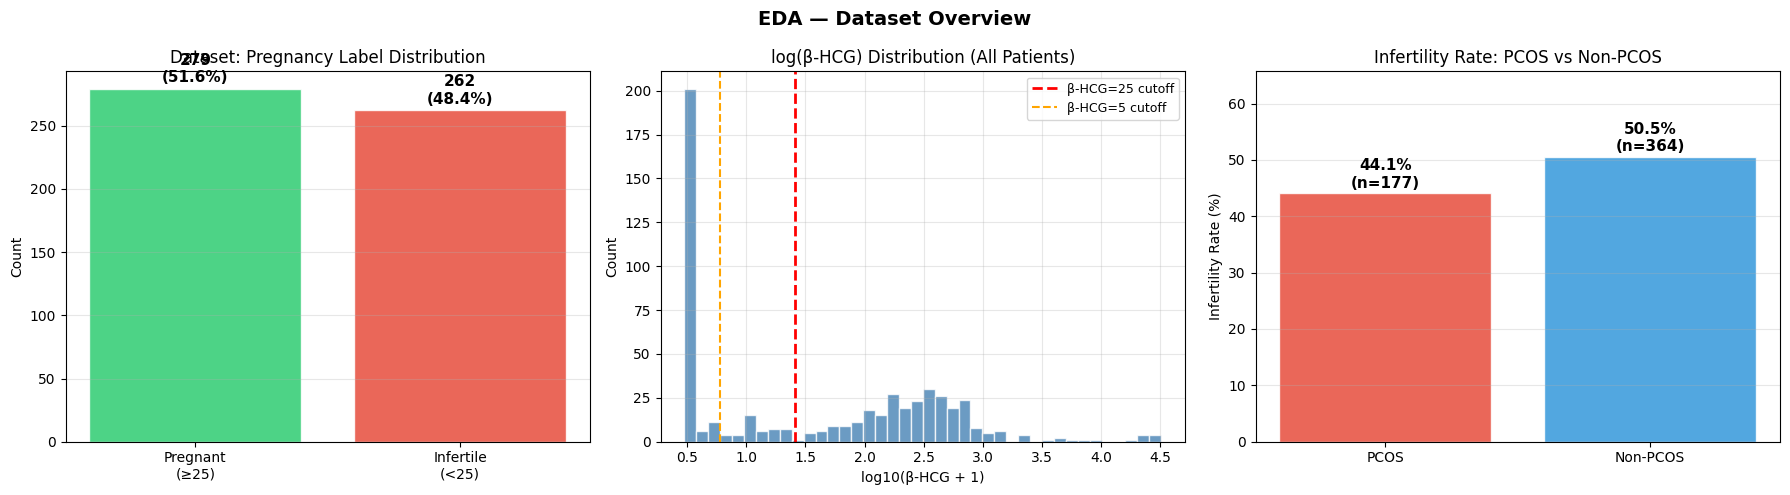

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/02_domain_severity_violin.png


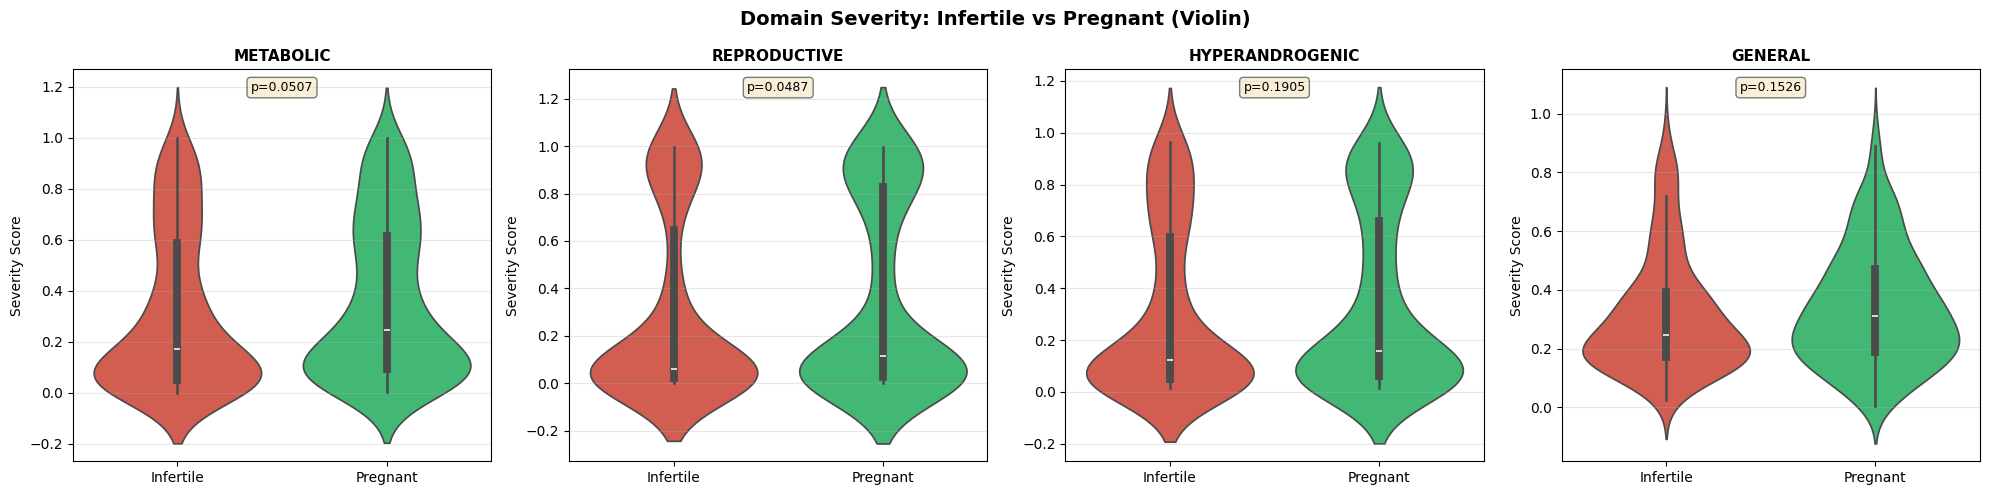

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/03_score_roc_pr.png


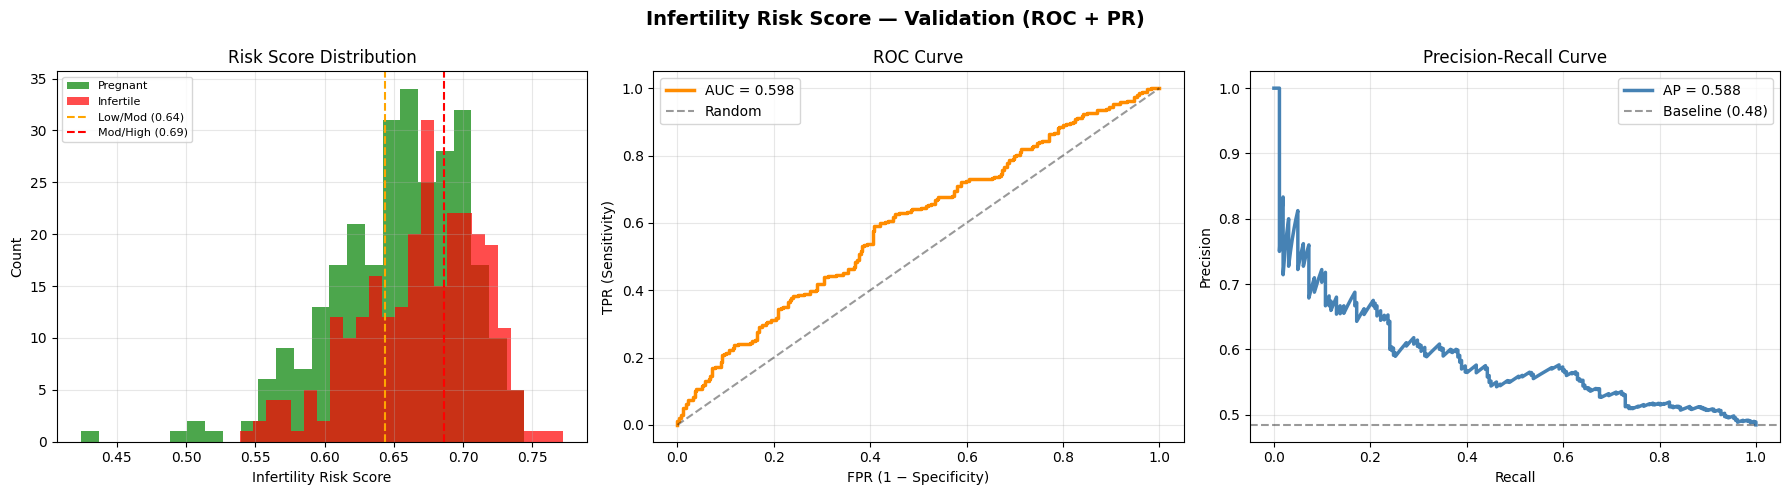

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/04_calibration_kde.png


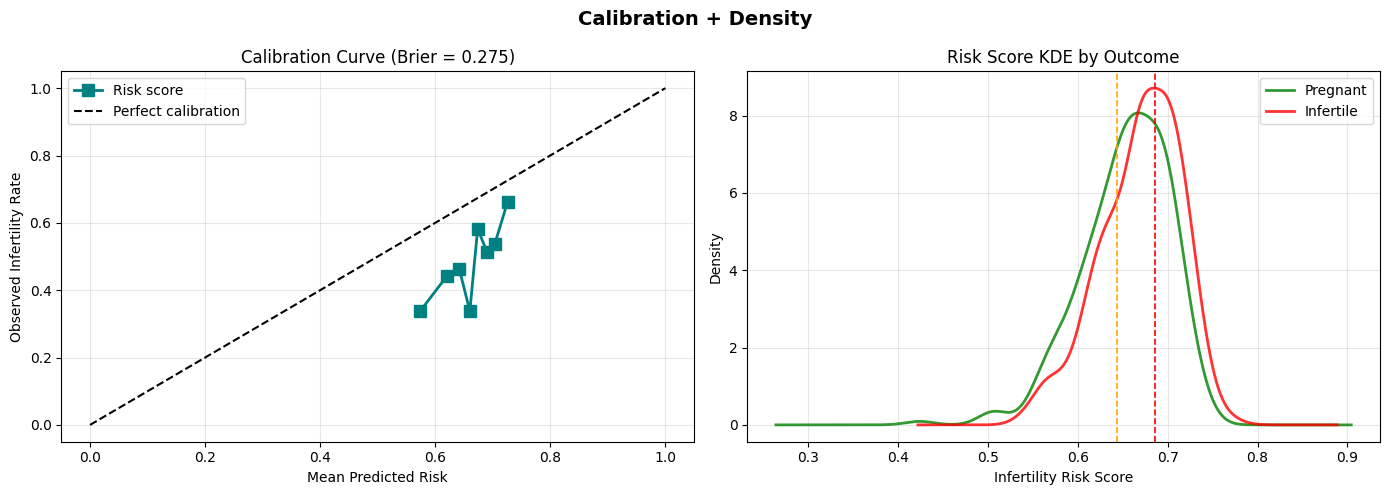

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/05_tier_analysis.png


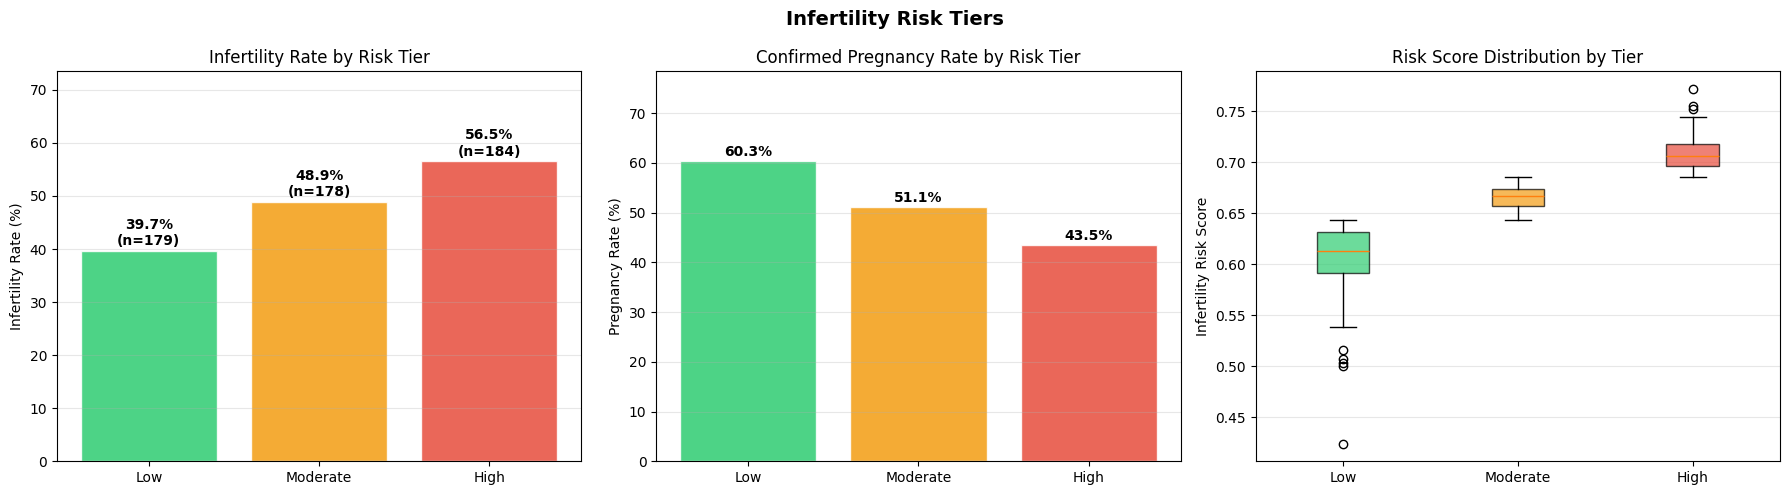

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/06_domain_contributions.png


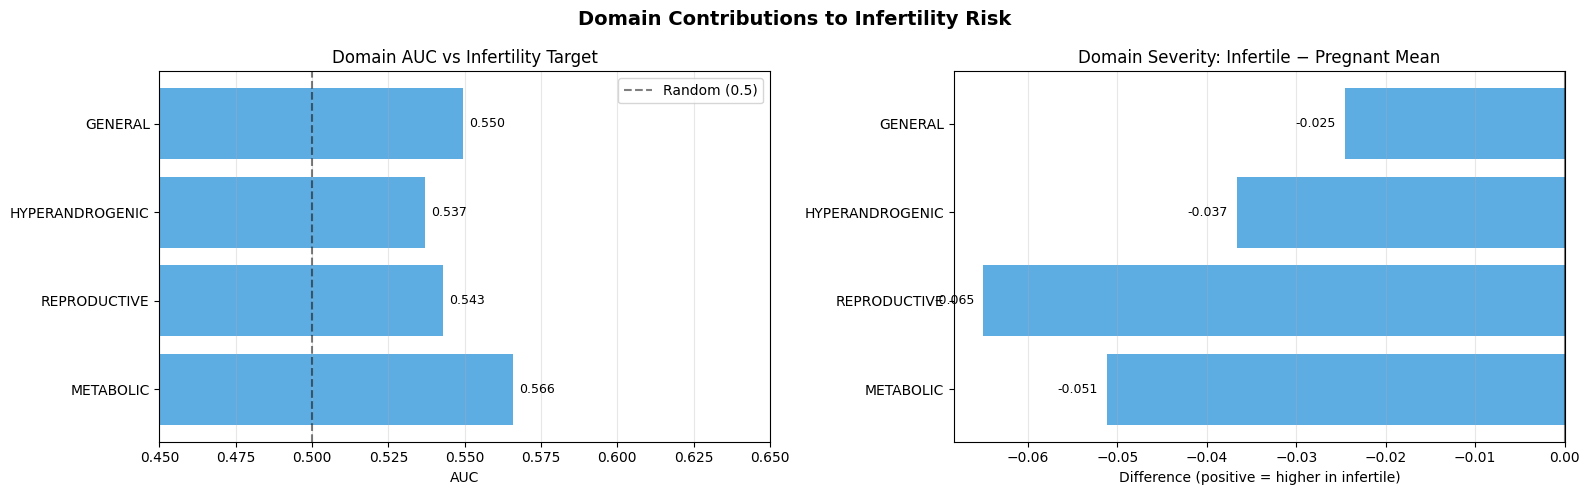

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/07_biomarkers_by_tier.png


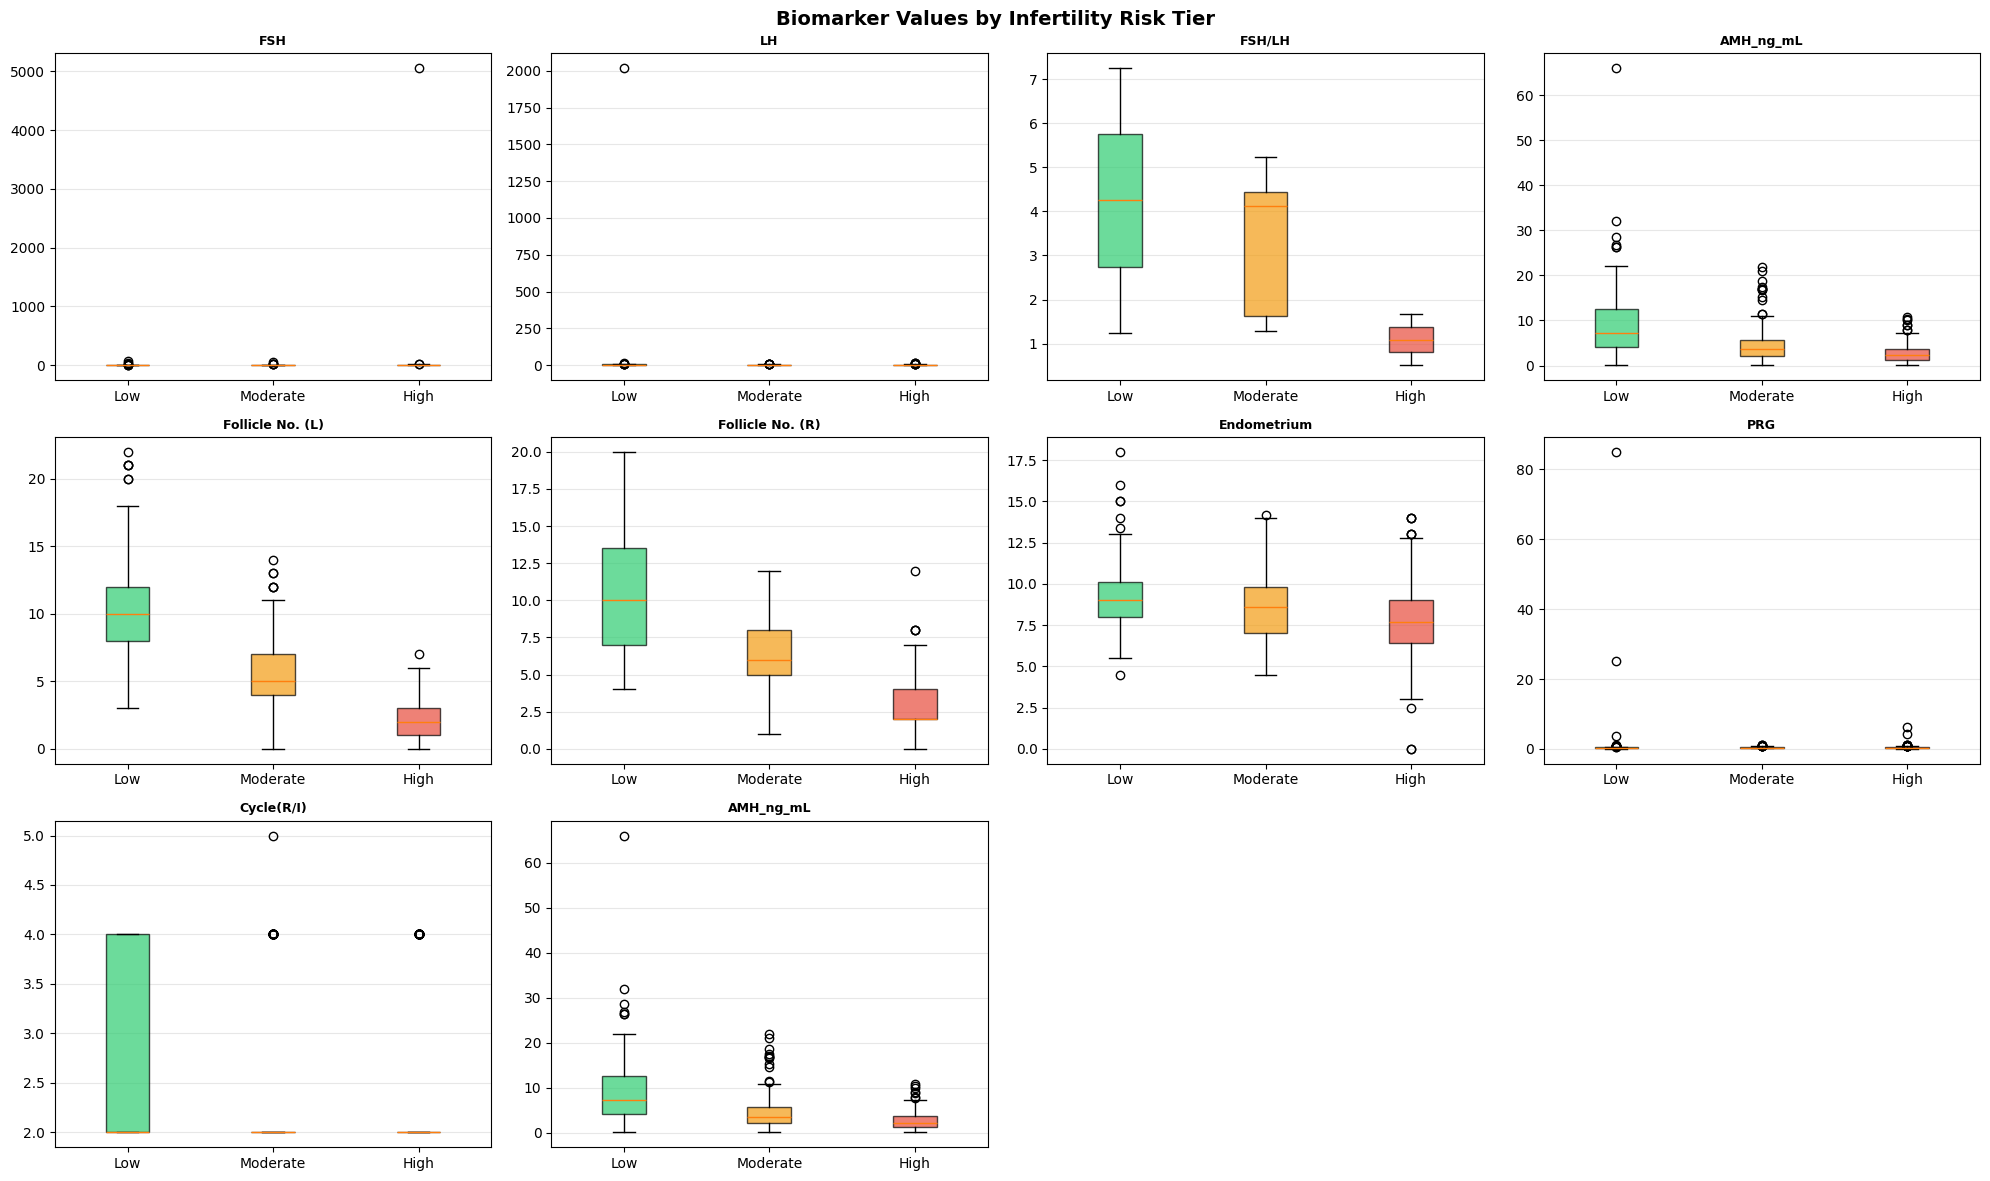

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/08_correlation_heatmap.png


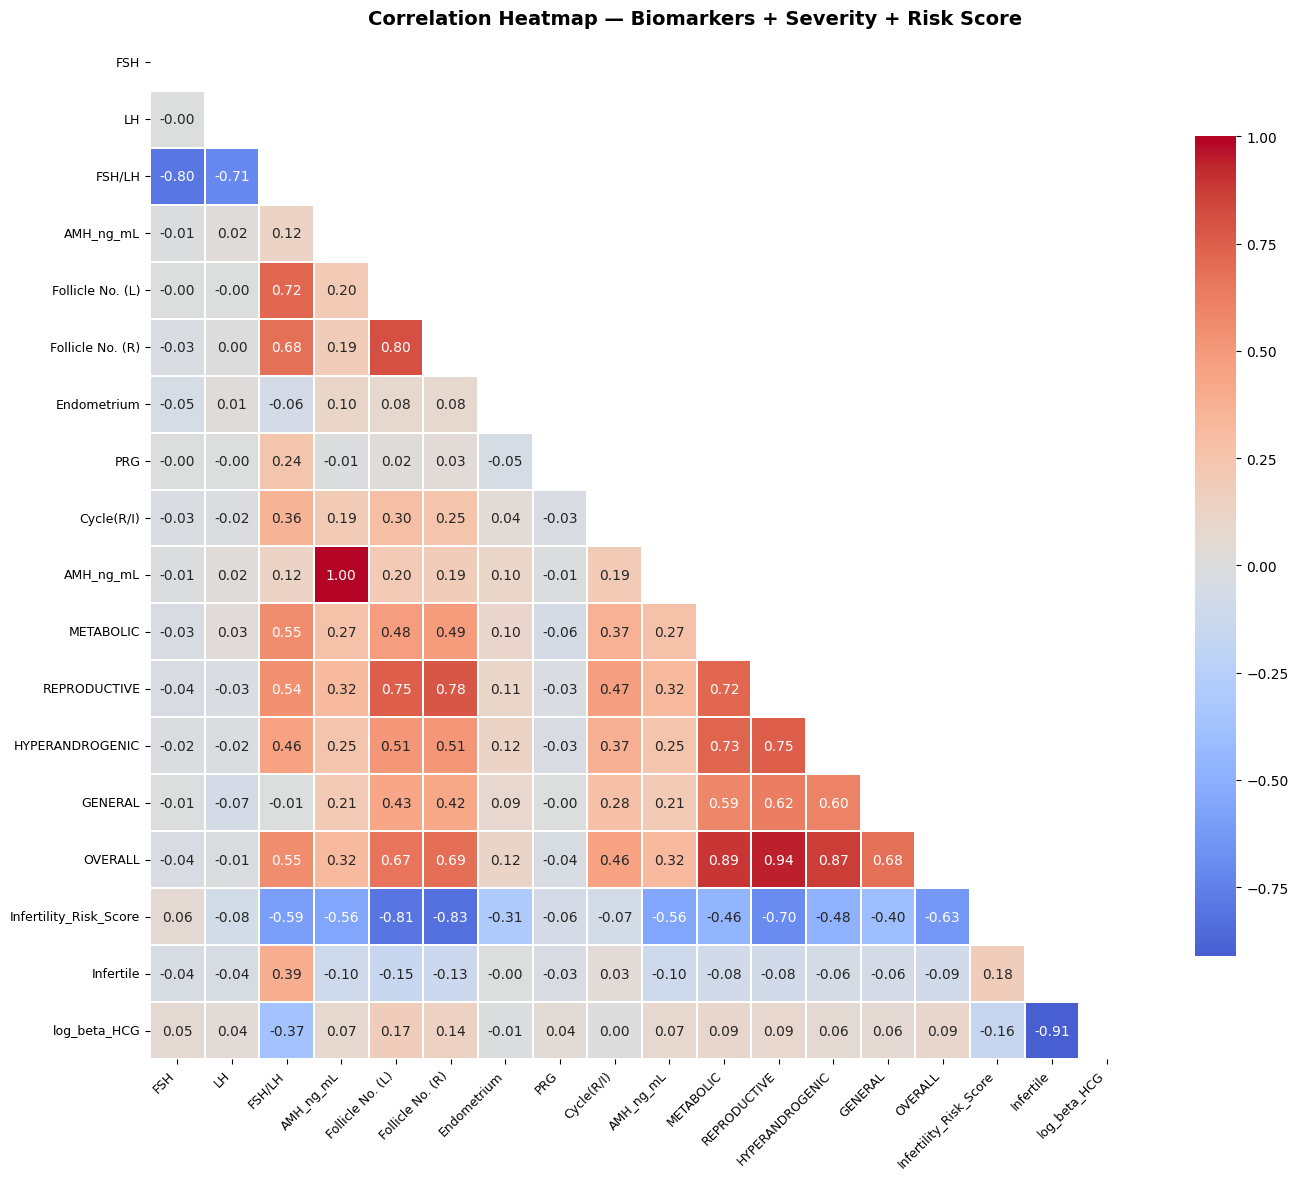

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/09_severity_risk_mapping.png


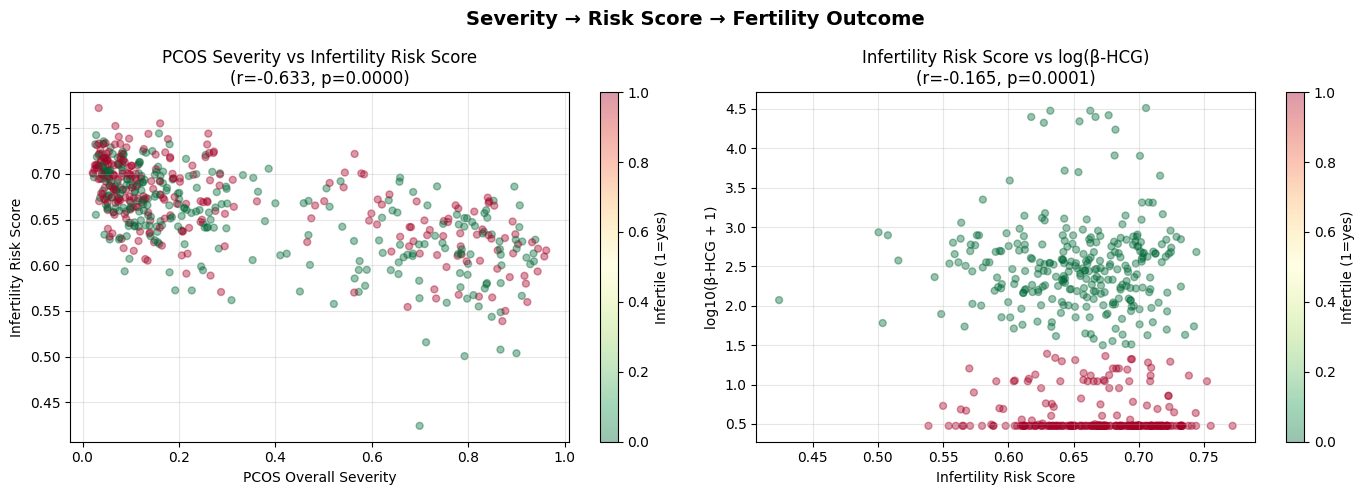

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/10_pcos_subgroup.png


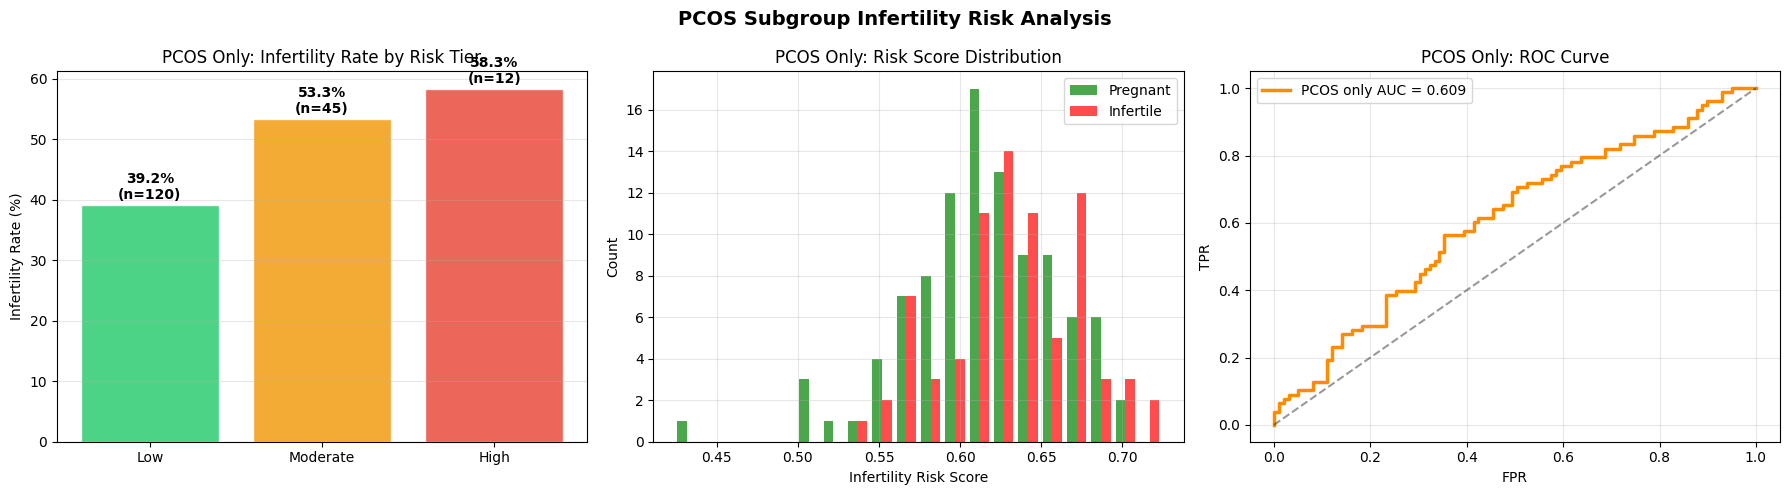

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/11_patient_strip_chart.png


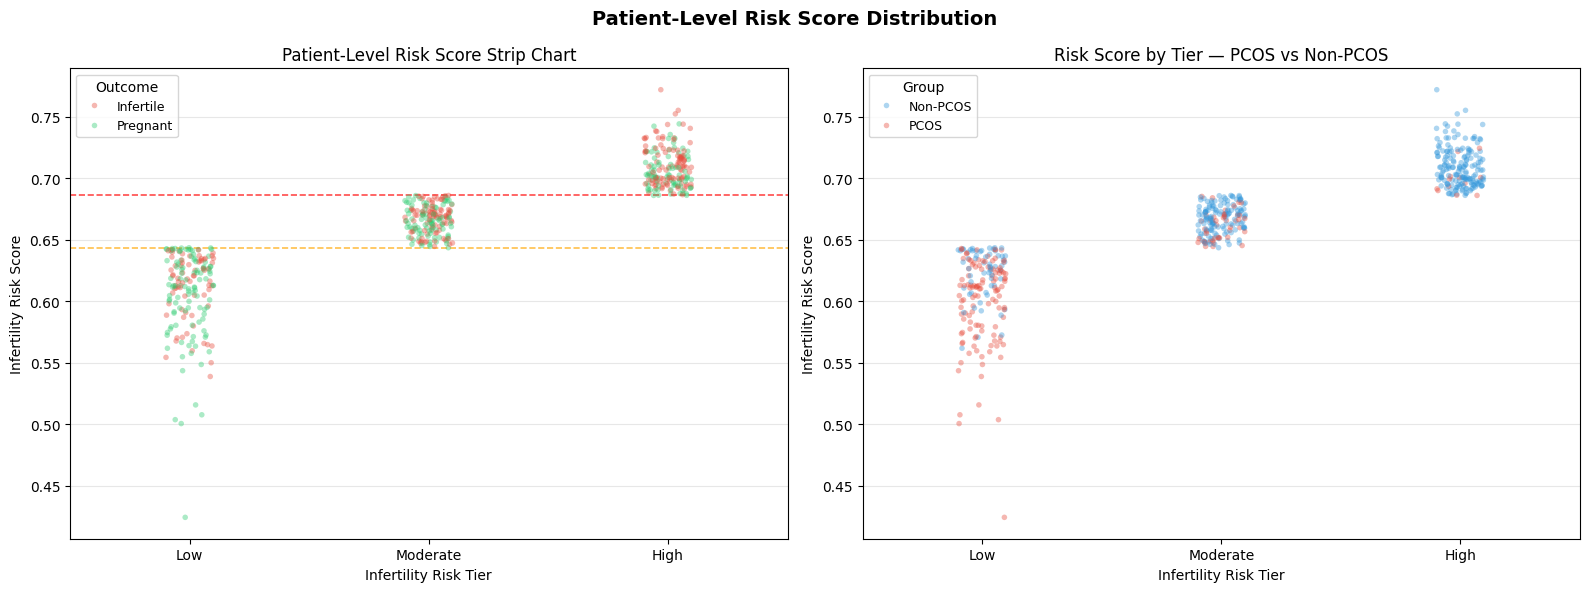

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/12_domain_heatmap_pcos_comparison.png


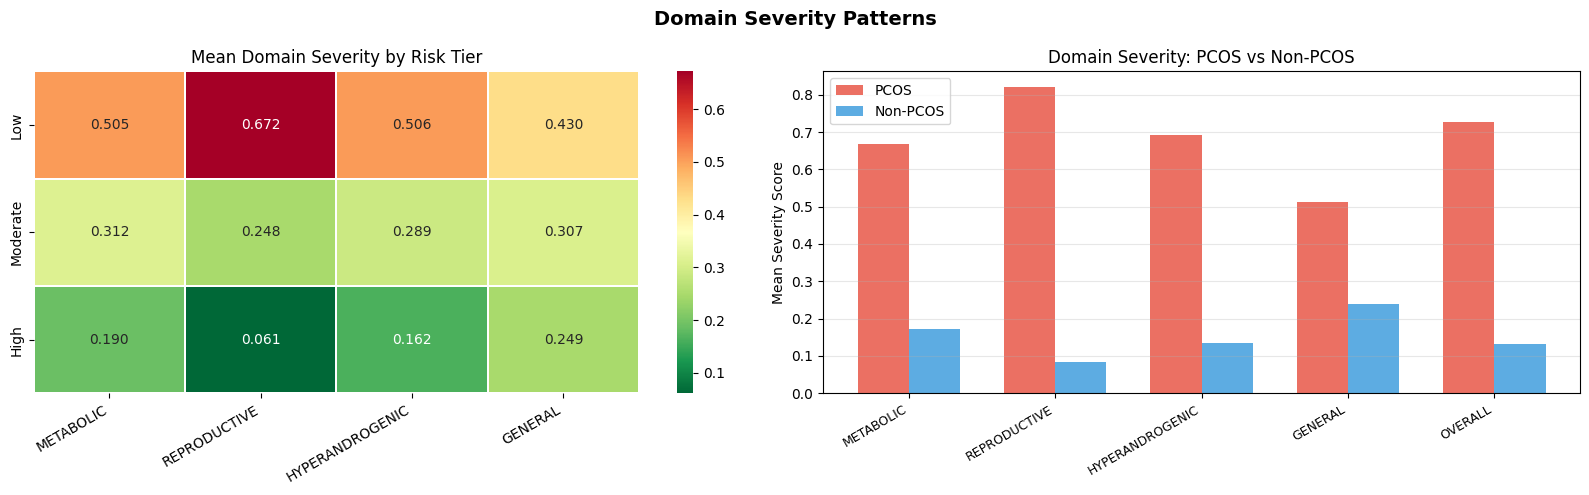

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/13_domain_risk_vs_infertility.png


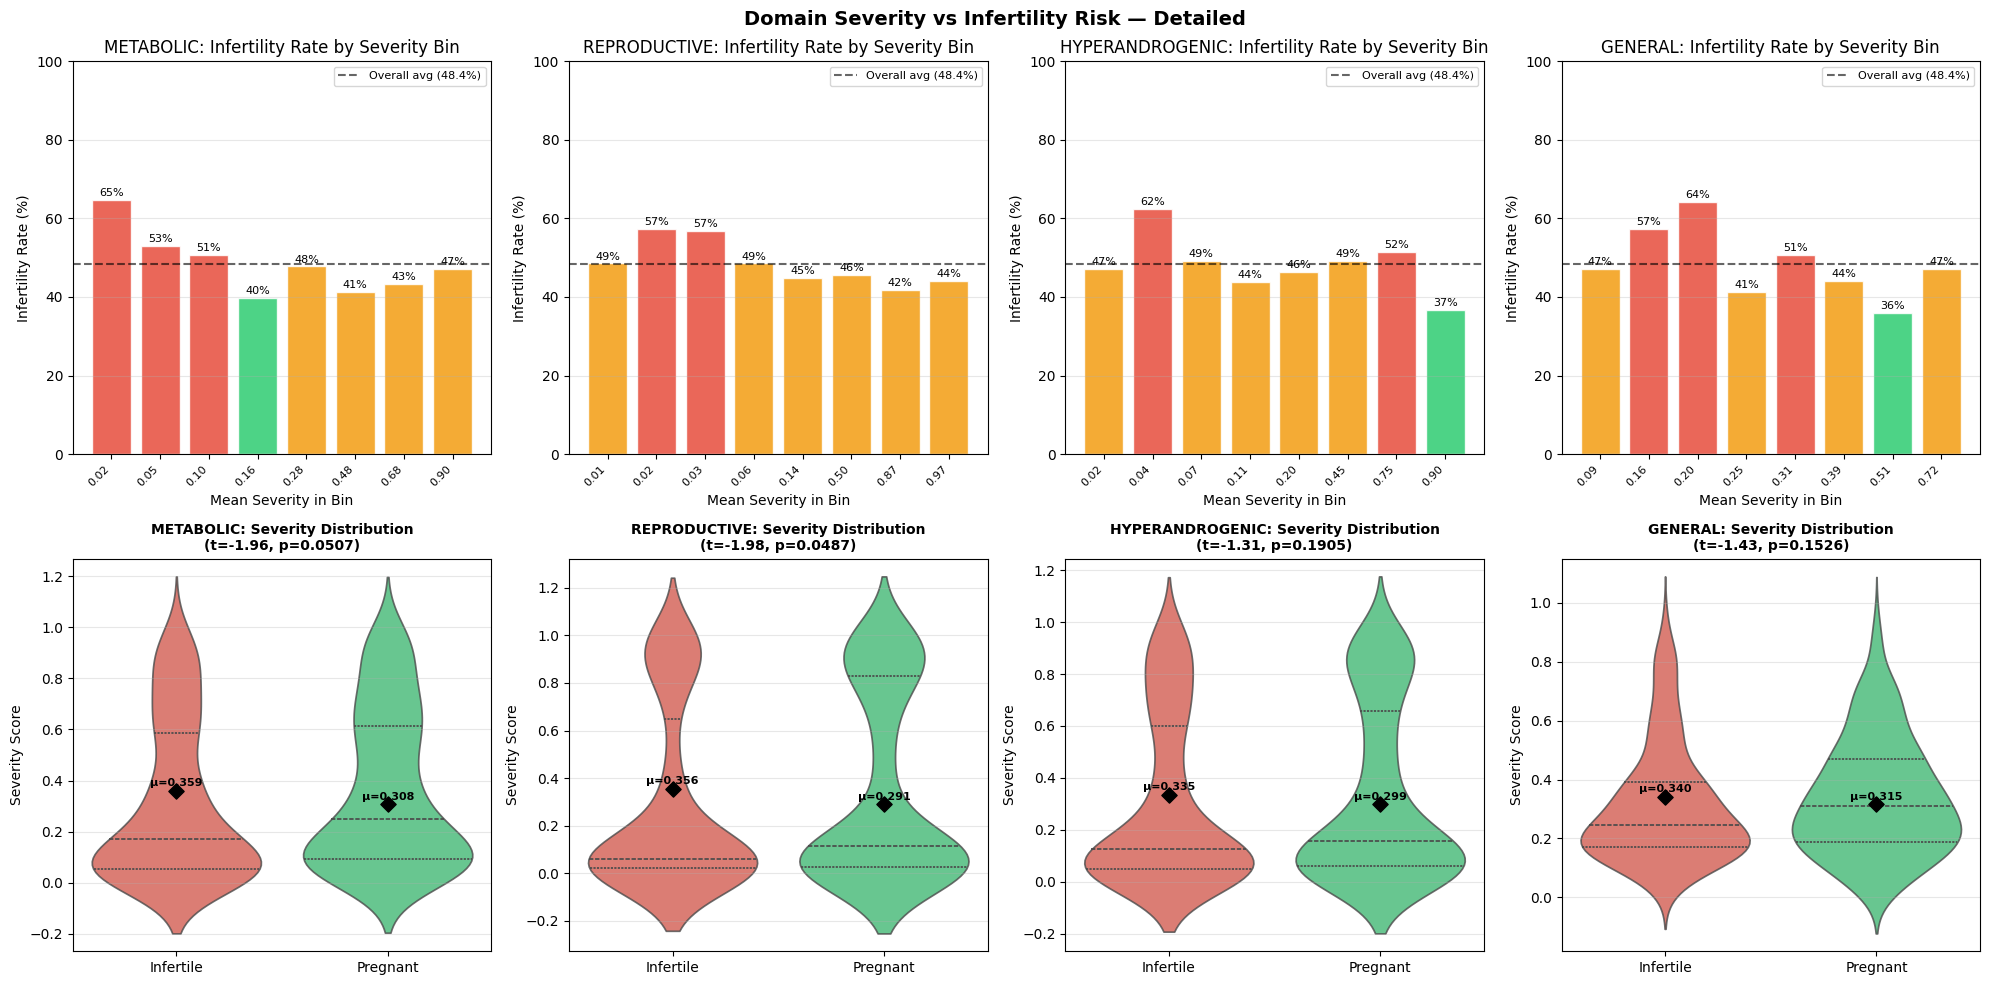

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/14_risk_score_dose_response.png


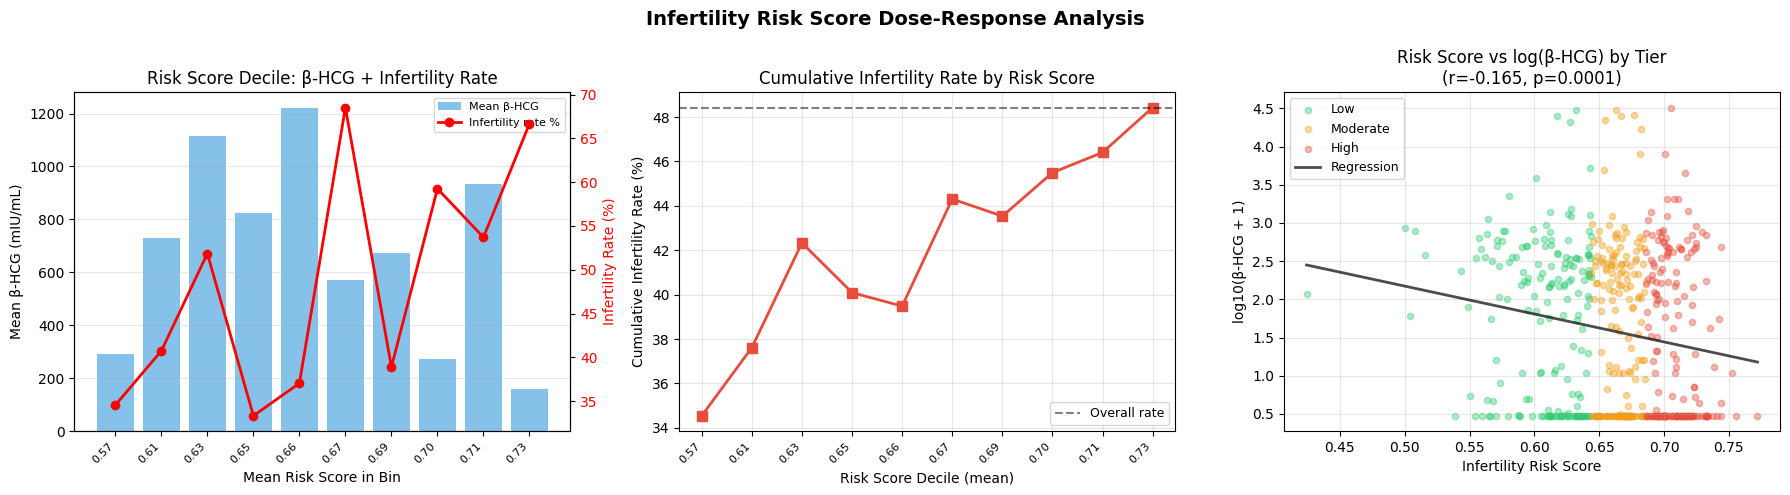

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/15_amh_stratification.png


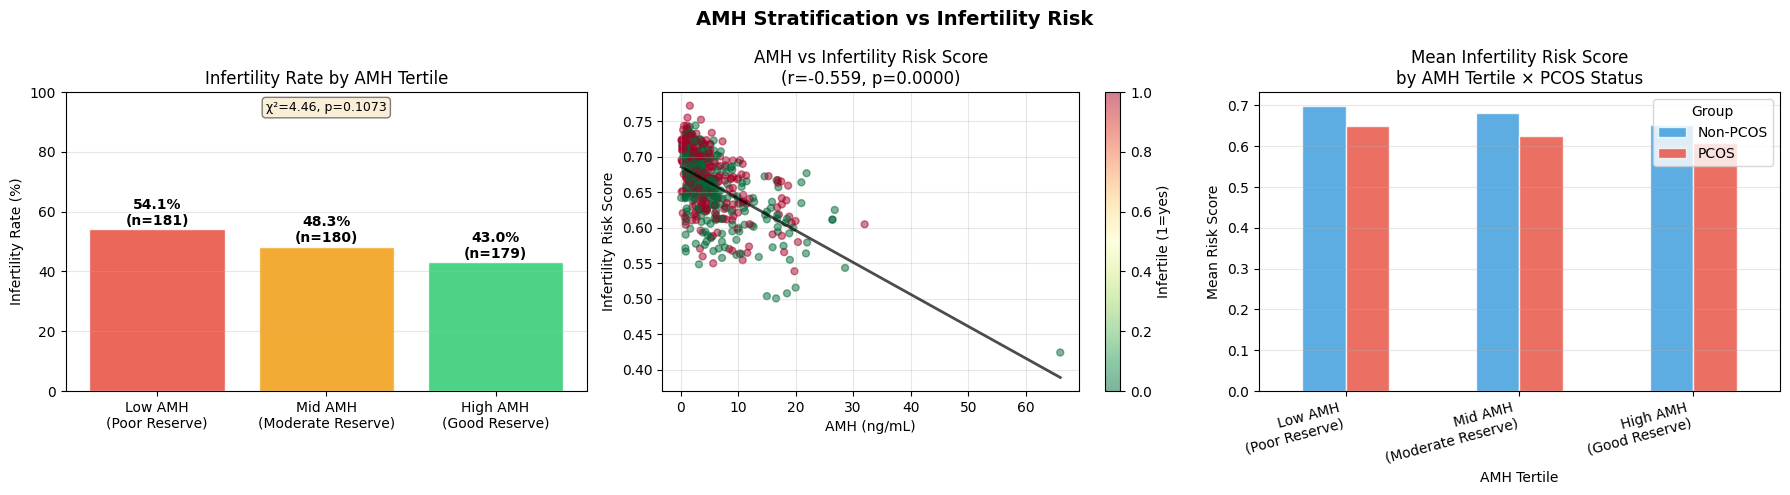

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/16_patient_risk_profile.png


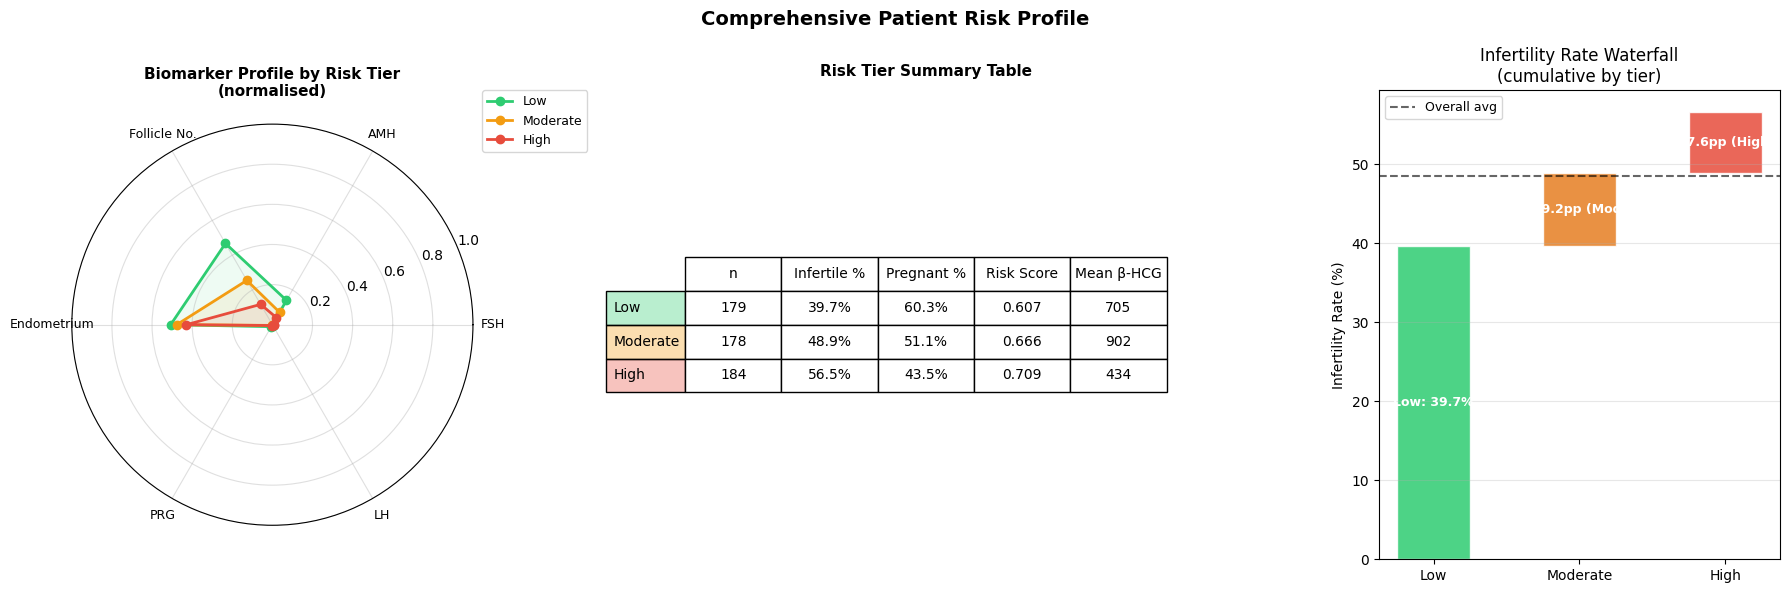


BLOCK 6 — SAVE OUTPUTS

  infertility_risk_scores.csv       → per-patient scores
  infertility_risk_tier_summary.csv → tier-level stats
  domain_contribution_summary.csv   → domain AUC + diff

  Tier Summary:
                         n  infertility_rate_pct  pregnancy_rate_pct  mean_risk_score  mean_pcos_severity  mean_beta_hcg
Infertility_Risk_Tier                                                                                                   
Low                    179                  39.7                60.3            0.607               0.568        705.319
Moderate               178                  48.9                51.1            0.666               0.281        902.444
High                   184                  56.5                43.5            0.709               0.136        434.220

  Validation: AUC=0.5980  Brier=0.2749

COMPLETE

  Infertility Risk Score built from 9 biomarkers.
  Tiers assigned by 33rd/66th percentile — guaranteed spread across Low/Moderate/Hig

In [ ]:
# =============================================================================
# MAIN
# =============================================================================

def main():
    section("PCOS SEVERITY → INFERTILITY RISK MAPPING  (v2)")

    df                        = load_and_merge()
    corr_df                   = correlation_audit(df)
    df, auc, brier, p33, p66  = build_infertility_risk_score(df)
    domain_results            = domain_contribution_analysis(df)
    plot_all(df, domain_results, auc, brier, p33, p66)
    save_outputs(df, domain_results, auc, brier)

    section("COMPLETE")
    print(f"""
  Infertility Risk Score built from {len([f for f in BIOMARKER_DIRECTIONS if f in df.columns])} biomarkers.
  Tiers assigned by 33rd/66th percentile — guaranteed spread across Low/Moderate/High.
  AUC = {auc:.4f}  (target: Infertile = beta-HCG < 25)
  Outputs saved to: {OUTPUT_DIR}
    """)
    return df


if __name__ == "__main__":
    df_result = main()

  Saved: /content/PCOS_INFERTILITY_RISK_V3/plots/09b_severity_mapping.png


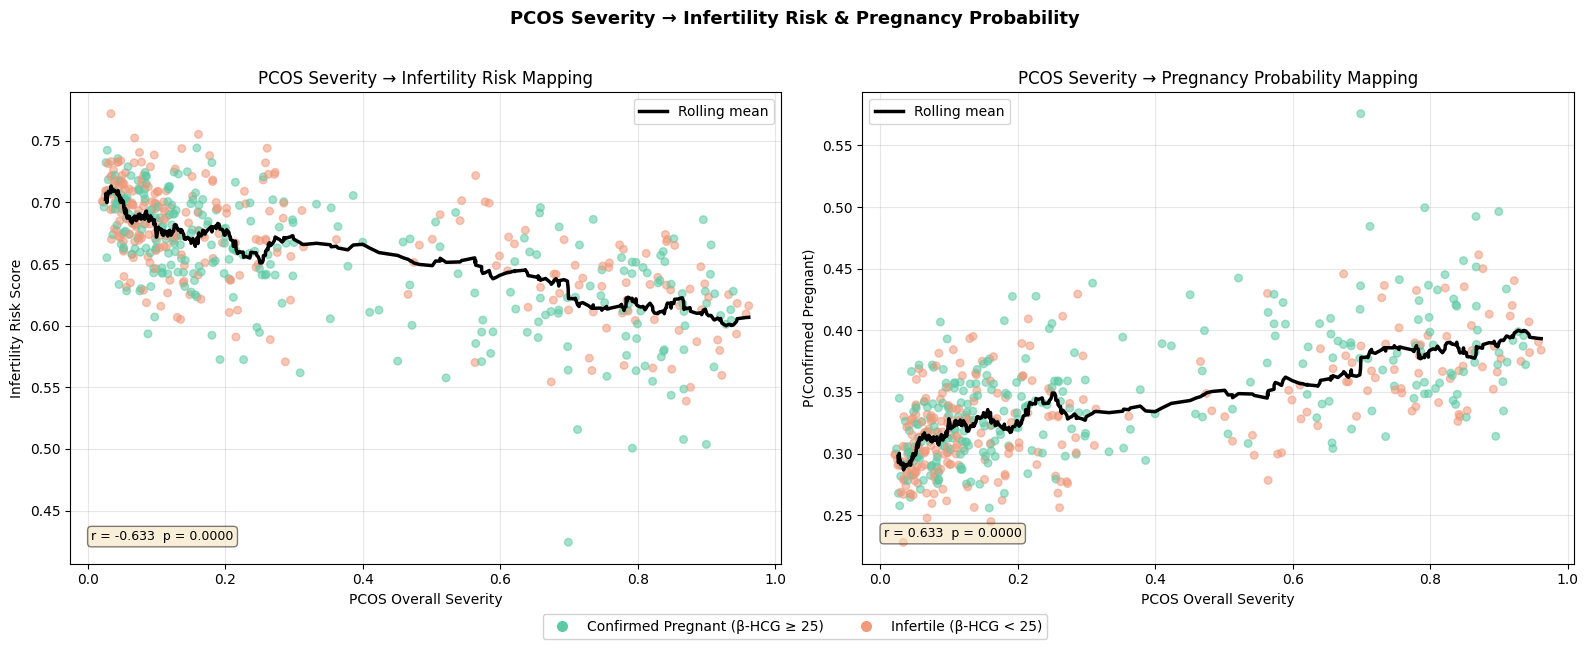

In [ ]:
def plot_severity_mapping(df, save_path=None):
    """
    Two-panel chart:
      Left  — PCOS Overall Severity → Infertility Risk Score
      Right — PCOS Overall Severity → Pregnancy Probability

    Points coloured by outcome:
      Green (teal) = Confirmed Pregnant (β-HCG ≥ 25)
      Red (pink)   = Infertile          (β-HCG < 25)

    Black line = rolling mean (window=30) to show trend.
    """

    # ── Column detection ───────────────────────────────────────────────────
    sev_col   = next((c for c in df.columns
                      if "OVERALL" in c.upper() and "SEV" in c.upper()), None)
    risk_col  = "Infertility_Risk_Score"
    preg_prob = "Pregnancy_Probability"
    outcome   = "Confirmed_Pregnant"

    # Pregnancy_Probability = 1 - Infertility_Risk_Score if not already present
    if preg_prob not in df.columns:
        df = df.copy()
        df[preg_prob] = 1 - df[risk_col]

    assert sev_col  is not None, "Could not find OVERALL_SEVERITY column"
    assert risk_col in df.columns, "Infertility_Risk_Score column missing"
    assert outcome  in df.columns, "Confirmed_Pregnant column missing"

    # ── Sort by severity for clean rolling mean ────────────────────────────
    plot_df = df[[sev_col, risk_col, preg_prob, outcome]].dropna().sort_values(sev_col)

    # Outcome colours — match the image exactly
    # Green (pregnant) = #4CAF50-ish teal-green
    # Red  (infertile) = #E91E63-ish pink-red
    colors = plot_df[outcome].map({1: "#5DCAA5", 0: "#F0997B"})

    # Rolling mean (window=30, min_periods=5)
    roll_risk = (plot_df.set_index(sev_col)[risk_col]
                 .rolling(30, min_periods=5).mean())
    roll_preg = (plot_df.set_index(sev_col)[preg_prob]
                 .rolling(30, min_periods=5).mean())

    # ── Pearson r for annotation ───────────────────────────────────────────
    r_risk, p_risk = stats.pearsonr(plot_df[sev_col], plot_df[risk_col])
    r_preg, p_preg = stats.pearsonr(plot_df[sev_col], plot_df[preg_prob])

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Left panel: Severity → Infertility Risk Score ─────────────────────
    axes[0].scatter(plot_df[sev_col], plot_df[risk_col],
                    c=colors, alpha=0.55, s=30, zorder=2)
    axes[0].plot(roll_risk.index, roll_risk.values,
                 color="black", lw=2.5, zorder=3, label="Rolling mean")
    axes[0].set(
        title="PCOS Severity → Infertility Risk Mapping",
        xlabel="PCOS Overall Severity",
        ylabel="Infertility Risk Score",
    )
    axes[0].legend(loc="upper right", fontsize=10)
    axes[0].grid(alpha=0.3)
    axes[0].text(0.03, 0.05,
                 f"r = {r_risk:.3f}  p = {p_risk:.4f}",
                 transform=axes[0].transAxes, fontsize=9,
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    # ── Right panel: Severity → Pregnancy Probability ────────────────────
    axes[1].scatter(plot_df[sev_col], plot_df[preg_prob],
                    c=colors, alpha=0.55, s=30, zorder=2)
    axes[1].plot(roll_preg.index, roll_preg.values,
                 color="black", lw=2.5, zorder=3, label="Rolling mean")
    axes[1].set(
        title="PCOS Severity → Pregnancy Probability Mapping",
        xlabel="PCOS Overall Severity",
        ylabel="P(Confirmed Pregnant)",
    )
    axes[1].legend(loc="upper left", fontsize=10)
    axes[1].grid(alpha=0.3)
    axes[1].text(0.03, 0.05,
                 f"r = {r_preg:.3f}  p = {p_preg:.4f}",
                 transform=axes[1].transAxes, fontsize=9, va="bottom",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    # ── Shared legend for outcome colours ─────────────────────────────────
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="#5DCAA5", markersize=9,
               label="Confirmed Pregnant (β-HCG ≥ 25)"),
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="#F0997B", markersize=9,
               label="Infertile (β-HCG < 25)"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=2, fontsize=10, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.04))

    plt.suptitle("PCOS Severity → Infertility Risk & Pregnancy Probability",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")

    plt.show()
    return fig


# ── Run ────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Option A: use df_result from the main pipeline (already in memory)
    # plot_severity_mapping(df_result,
    #     save_path="/content/PCOS_INFERTILITY_RISK_V2/plots/09b_severity_mapping.png")

    # Option B: load from saved CSV
    df = pd.read_csv(
        "/content/PCOS_INFERTILITY_RISK_V3/infertility_risk_scores.csv",
        index_col=0)
    plot_severity_mapping(
        df,
        save_path="/content/PCOS_INFERTILITY_RISK_V3/plots/09b_severity_mapping.png")